In [445]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.resolve()
PROC = PROJECT_ROOT / "data" / "processed"

df = pd.read_csv(PROC / "cleaned_apple_sales_enriched_realistic.csv")

In [446]:
df.head()

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month
0,RW-18212,2020-01-01,ST-41,P-73,2,Apple One,2020-01-01,488,Apple Central World,Bangkok,...,1.00,471.38,0,0.00,1.00,1.22,1.04,3,"1,414.13",1
1,RX-6848,2020-01-01,ST-31,P-40,7,iPhone SE (3rd Generation),2020-01-01,923,Apple Shinjuku,Tokyo,...,1.40,754.81,0,0.00,1.00,1.17,10.81,6,"4,528.87",1
2,SV-39198,2020-01-01,ST-9,P-73,7,Apple One,2020-01-01,488,Apple Park Visitor Center,Cupertino,...,1.00,520.30,0,0.00,1.00,0.96,6.41,5,"2,601.49",1
3,ZI-218670,2020-01-01,ST-20,P-70,1,Apple Fitness+,2020-01-01,923,Apple Kaerntner Strasse,Vienna,...,1.00,986.82,0,0.00,1.00,1.11,0.80,1,986.82,1
4,VB-48589,2020-01-01,ST-60,P-18,9,Beats Solo Pro,2020-01-01,1773,Apple Antara,Mexico City,...,1.00,"1,754.96",0,0.00,1.00,1.20,4.42,4,"7,019.84",1


In [447]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040200 entries, 0 to 1040199
Data columns (total 35 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   sale_id                 1040200 non-null  object 
 1   sale_date               1040200 non-null  object 
 2   store_id                1040200 non-null  object 
 3   product_id              1040200 non-null  object 
 4   quantity                1040200 non-null  int64  
 5   product_name            1040200 non-null  object 
 6   launch_date             1040200 non-null  object 
 7   price                   1040200 non-null  int64  
 8   store_name              1040200 non-null  object 
 9   city                    1040200 non-null  object 
 10  category_id             1040200 non-null  object 
 11  category_name           1040200 non-null  object 
 12  sales_amount            1040200 non-null  int64  
 13  invalid_launch_flag     1040200 non-null  bool   
 14  pr

In [448]:
print(df.columns)

Index(['sale_id', 'sale_date', 'store_id', 'product_id', 'quantity',
       'product_name', 'launch_date', 'price', 'store_name', 'city',
       'category_id', 'category_name', 'sales_amount', 'invalid_launch_flag',
       'product_age_days', 'exchange_rate', 'inflation_rate',
       'internet_usage_pct', 'country_norm_mapped', 'year', 'gdp_type',
       'gdp_per_capita', 'season_factor', 'economic_factor', 'promo_flag',
       'promo_factor', 'price_realistic', 'days_from_start', 'product_trend',
       'trend_factor', 'store_factor', 'mu_demand', 'quantity_realistic',
       'sales_amount_realistic', 'month'],
      dtype='object')


In [449]:
df.shape

(1040200, 35)

In [450]:
# تحويل sales_date إلى datetime
df['sale_date'] = pd.to_datetime(df['sale_date'])

# تأكيد
print(df['sale_date'].head())
print(df['sale_date'].dtype)

0   2020-01-01
1   2020-01-01
2   2020-01-01
3   2020-01-01
4   2020-01-01
Name: sale_date, dtype: datetime64[ns]
datetime64[ns]


In [451]:
# استخراج السنة والشهر
df['year'] = df['sale_date'].dt.year
df['month'] = df['sale_date'].dt.month

In [452]:
monthly_df = (
    df.groupby(['store_name', 'year', 'month'], as_index=False)
    .agg({
        'sales_amount_realistic': 'sum',
        'gdp_per_capita': 'mean',
        'inflation_rate': 'mean',
        'exchange_rate': 'mean',
        'internet_usage_pct': 'mean'
    })
)

In [453]:
# ترتيب زمني
monthly_df = monthly_df.sort_values(
    by=['store_name', 'year', 'month']
).reset_index(drop=True)

monthly_df.head()

,store_name,year,month,sales_amount_realistic,gdp_per_capita,inflation_rate,exchange_rate,internet_usage_pct
0,Apple Ala Moana,2020,1,"1,698,420.59","64,401.51",1.23,1.00,90.34
1,Apple Ala Moana,2020,2,"2,467,760.69","64,401.51",1.23,1.00,90.34
2,Apple Ala Moana,2020,3,"2,519,131.28","64,401.51",1.23,1.00,90.34
3,Apple Ala Moana,2020,4,"2,559,084.42","64,401.51",1.23,1.00,90.34
4,Apple Ala Moana,2020,5,"2,303,684.54","64,401.51",1.23,1.00,90.34


In [454]:
monthly_df.groupby('store_name').size().describe()

count   69.00
mean    59.00
std      0.00
min     59.00
25%     59.00
50%     59.00
75%     59.00
max     59.00
dtype: float64

In [455]:
monthly_df['date'] = pd.to_datetime(
    monthly_df['year'].astype(str) + '-' +
    monthly_df['month'].astype(str) + '-01'
)

monthly_df = monthly_df.sort_values(['store_name', 'date']).reset_index(drop=True)

In [456]:
monthly_df['store_id'] = monthly_df['store_name'].astype('category').cat.codes

In [457]:
import numpy as np

monthly_df['month_sin'] = np.sin(2 * np.pi * monthly_df['month'] / 12)
monthly_df['month_cos'] = np.cos(2 * np.pi * monthly_df['month'] / 12)

In [458]:
for lag in [1, 3, 6, 12]:
    monthly_df[f'lag_{lag}'] = (
        monthly_df
        .groupby('store_id')['sales_amount_realistic']
        .shift(lag)
    )

In [459]:
monthly_df['rolling_mean_3'] = (
    monthly_df
    .groupby('store_id')['sales_amount_realistic']
    .shift(1)
    .rolling(3)
    .mean()
)

monthly_df['rolling_mean_6'] = (
    monthly_df
    .groupby('store_id')['sales_amount_realistic']
    .shift(1)
    .rolling(6)
    .mean()
)

In [460]:
monthly_df.isna().sum()

store_name                  0
year                        0
month                       0
sales_amount_realistic      0
gdp_per_capita              0
inflation_rate              0
exchange_rate               0
internet_usage_pct          0
date                        0
store_id                    0
month_sin                   0
month_cos                   0
lag_1                      69
lag_3                     207
lag_6                     414
lag_12                    828
rolling_mean_3            207
rolling_mean_6            414
dtype: int64

In [461]:
print(df.columns)

Index(['sale_id', 'sale_date', 'store_id', 'product_id', 'quantity',
       'product_name', 'launch_date', 'price', 'store_name', 'city',
       'category_id', 'category_name', 'sales_amount', 'invalid_launch_flag',
       'product_age_days', 'exchange_rate', 'inflation_rate',
       'internet_usage_pct', 'country_norm_mapped', 'year', 'gdp_type',
       'gdp_per_capita', 'season_factor', 'economic_factor', 'promo_flag',
       'promo_factor', 'price_realistic', 'days_from_start', 'product_trend',
       'trend_factor', 'store_factor', 'mu_demand', 'quantity_realistic',
       'sales_amount_realistic', 'month'],
      dtype='object')


In [462]:
monthly_df.columns

Index(['store_name', 'year', 'month', 'sales_amount_realistic',
       'gdp_per_capita', 'inflation_rate', 'exchange_rate',
       'internet_usage_pct', 'date', 'store_id', 'month_sin', 'month_cos',
       'lag_1', 'lag_3', 'lag_6', 'lag_12', 'rolling_mean_3',
       'rolling_mean_6'],
      dtype='object')

In [463]:
monthly_df[['sales_amount_realistic',
            'lag_1',
            'lag_3',
            'lag_12',
            'rolling_mean_3',"gdp_per_capita","inflation_rate","exchange_rate","internet_usage_pct" ]].head(10)

,sales_amount_realistic,lag_1,lag_3,lag_12,rolling_mean_3,gdp_per_capita,inflation_rate,exchange_rate,internet_usage_pct
0,"1,698,420.59",NaN,NaN,NaN,NaN,"64,401.51",1.23,1.00,90.34
1,"2,467,760.69","1,698,420.59",NaN,NaN,NaN,"64,401.51",1.23,1.00,90.34
2,"2,519,131.28","2,467,760.69",NaN,NaN,NaN,"64,401.51",1.23,1.00,90.34
3,"2,559,084.42","2,519,131.28","1,698,420.59",NaN,"2,228,437.52","64,401.51",1.23,1.00,90.34
4,"2,303,684.54","2,559,084.42","2,467,760.69",NaN,"2,515,325.46","64,401.51",1.23,1.00,90.34
5,"2,724,755.54","2,303,684.54","2,519,131.28",NaN,"2,460,633.41","64,401.51",1.23,1.00,90.34
6,"2,753,674.15","2,724,755.54","2,559,084.42",NaN,"2,529,174.83","64,401.51",1.23,1.00,90.34
7,"2,872,658.28","2,753,674.15","2,303,684.54",NaN,"2,594,038.08","64,401.51",1.23,1.00,90.34
8,"2,708,091.80","2,872,658.28","2,724,755.54",NaN,"2,783,695.99","64,401.51",1.23,1.00,90.34
9,"2,459,426.84","2,708,091.80","2,753,674.15",NaN,"2,778,141.41","64,401.51",1.23,1.00,90.34


In [464]:
monthly_df["gdp_growth"] = monthly_df["gdp_per_capita"].pct_change()

monthly_df["inflation_change"] = monthly_df["inflation_rate"].pct_change()

monthly_df["exchange_change"] = monthly_df["exchange_rate"].pct_change()

monthly_df["internet_growth"] = monthly_df["internet_usage_pct"].pct_change()

In [465]:
monthly_df.isna().sum()

store_name                  0
year                        0
month                       0
sales_amount_realistic      0
gdp_per_capita              0
inflation_rate              0
exchange_rate               0
internet_usage_pct          0
date                        0
store_id                    0
month_sin                   0
month_cos                   0
lag_1                      69
lag_3                     207
lag_6                     414
lag_12                    828
rolling_mean_3            207
rolling_mean_6            414
gdp_growth                  1
inflation_change            1
exchange_change             1
internet_growth             1
dtype: int64

In [466]:
monthly_df = monthly_df.dropna().reset_index(drop=True)

In [467]:
monthly_df.isna().sum()

store_name                0
year                      0
month                     0
sales_amount_realistic    0
gdp_per_capita            0
inflation_rate            0
exchange_rate             0
internet_usage_pct        0
date                      0
store_id                  0
month_sin                 0
month_cos                 0
lag_1                     0
lag_3                     0
lag_6                     0
lag_12                    0
rolling_mean_3            0
rolling_mean_6            0
gdp_growth                0
inflation_change          0
exchange_change           0
internet_growth           0
dtype: int64

In [468]:
monthly_df["yoy_growth"] = (
    (monthly_df["sales_amount_realistic"] - monthly_df["lag_12"]) 
    / monthly_df["lag_12"]
)

In [469]:
monthly_df["sales_momentum"] = (
    monthly_df["lag_1"] - monthly_df["lag_3"]
)

In [470]:
monthly_avg = monthly_df.groupby("month")["sales_amount_realistic"].transform("mean")

monthly_df["season_strength"] = (
    monthly_df["sales_amount_realistic"] / monthly_avg
)

In [471]:
feature_cols = [
'store_id',
'month_sin',
'month_cos',

'lag_1',
'lag_3',
'lag_6',
'lag_12',

'rolling_mean_3',
'rolling_mean_6',

'yoy_growth',
'sales_momentum',
'season_strength',

'gdp_growth',
'inflation_change',
'exchange_change',
'internet_growth'
]

In [472]:
monthly_df["gdp_sales_effect"] = (
monthly_df["gdp_growth"] * monthly_df["lag_1"]
)

In [473]:
target_col = 'sales_amount_realistic'

In [474]:
X = monthly_df[feature_cols]
y = monthly_df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (3243, 16)
y shape: (3243,)


,store_id,month_sin,month_cos,lag_1,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,yoy_growth,sales_momentum,season_strength,gdp_growth,inflation_change,exchange_change,internet_growth
0,0,0.50,0.87,"3,330,574.02","2,459,426.84","2,753,674.15","1,698,420.59","2,884,365.76","2,831,253.58",0.22,"871,147.18",1.48,0.11,2.81,0.00,0.01
1,0,0.87,0.50,"2,077,733.19","2,863,096.42","2,872,658.28","2,467,760.69","2,757,134.54","2,718,596.76",-0.24,"-785,363.23",1.18,0.00,0.00,0.00,0.00
2,0,1.00,0.00,"1,879,475.25","3,330,574.02","2,708,091.80","2,519,131.28","2,429,260.82","2,553,066.25",0.19,"-1,451,098.77",1.82,0.00,0.00,0.00,0.00
3,0,0.87,-0.50,"2,999,935.98","2,077,733.19","2,459,426.84","2,559,084.42","2,319,048.14","2,601,706.95",0.02,"922,202.79",1.64,0.00,0.00,0.00,0.00
4,0,0.50,-0.87,"2,607,050.37","1,879,475.25","2,863,096.42","2,303,684.54","2,495,487.20","2,626,310.87",0.07,"727,575.12",1.51,0.00,0.00,0.00,-0.00


In [475]:
from sklearn.model_selection import train_test_split

# نحافظ على الترتيب الزمني
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, shuffle=False
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, shuffle=False
)

In [476]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [477]:
print(X_train_scaled.mean(axis=0))
print(X_train_scaled.std(axis=0))

[ 5.00823074e-17 -4.69521632e-18 -2.33782646e-17 -1.06424903e-16
 -1.25205768e-16 -1.62767499e-16 -5.94727400e-17 -3.44315863e-17
  3.75617305e-17  4.69521632e-18  4.40176530e-18  1.12685192e-16
  3.20839782e-17 -7.04282447e-18  6.26028842e-18 -9.39043263e-18]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [478]:
from sklearn.preprocessing import StandardScaler

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled   = y_scaler.transform(y_val.values.reshape(-1, 1))
y_test_scaled  = y_scaler.transform(y_test.values.reshape(-1, 1))

In [479]:
def create_sequences(X, y, window_size):
    X_seq, y_seq = [], []

    for i in range(len(X) - window_size):
        X_seq.append(X[i:i+window_size])
        y_seq.append(y[i+window_size])

    return np.array(X_seq), np.array(y_seq)

In [480]:
window_size = 12

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled, y_train_scaled.flatten(), window_size
)

X_val_seq, y_val_seq = create_sequences(
    X_val_scaled, y_val_scaled.flatten(), window_size
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled, y_test_scaled.flatten(), window_size
)

In [481]:
print(X_train_seq.shape)
print(y_train_seq.shape)

(2258, 12, 16)
(2258,)


In [482]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [483]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size, X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='huber',
    metrics=['mae']
)

model.summary()

c:\Users\Ali Sherif\Apple-Retail-Sales-Forcasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 12, 64)         │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,185 (129.63 KB)

 Trainable params: 33,185 (129.63 KB)

 Non-trainable params: 0 (0.00 B)

In [484]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.1858 - mae: 0.4600 - val_loss: 0.1656 - val_mae: 0.4578
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.1390 - mae: 0.3894 - val_loss: 0.1082 - val_mae: 0.3322
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1238 - mae: 0.3655 - val_loss: 0.1025 - val_mae: 0.3289
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1145 - mae: 0.3518 - val_loss: 0.0924 - val_mae: 0.3114
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1066 - mae: 0.3389 - val_loss: 0.0865 - val_mae: 0.3050
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1009 - mae: 0.3308 - val_loss: 0.0838 - val_mae: 0.3027
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0929 - mae: 0.3151 - val_loss: 0.0770 - val_mae: 0.2805
Epoch 8/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0833 - mae: 0.3024 - val_loss: 0.0719 - val_mae: 0.2841
Epoch 9/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - los

In [485]:
test_loss, test_mae = model.evaluate(X_test_seq, y_test_seq)
print("Test MAE:", test_mae)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0567 - mae: 0.2450
Test MAE: 0.24502217769622803


In [486]:
y_pred = model.predict(X_test_seq)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


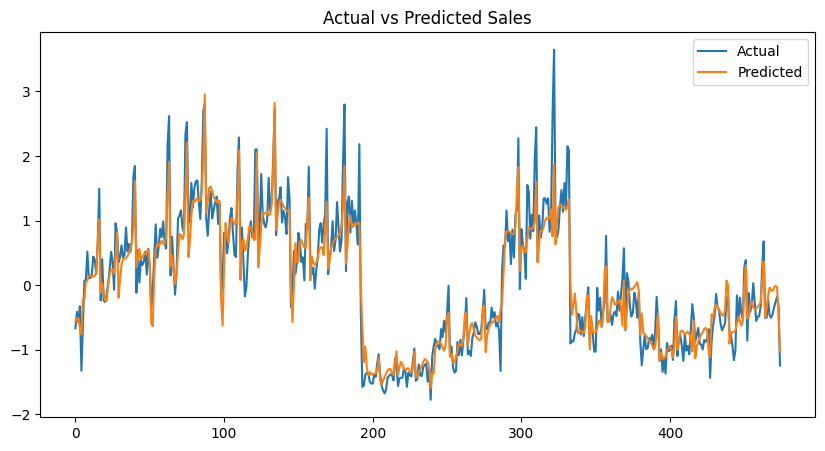

In [487]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test_seq, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [488]:
y_pred_scaled = model.predict(X_test_seq)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [489]:
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_scaler.inverse_transform(y_test_seq.reshape(-1, 1))

In [490]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE (%):", mape)

MAE: 203292.37587605524
RMSE: 283565.22512796224
MAPE (%): 13.11621854194674


In [491]:
# نضمن الترتيب الزمني
monthly_df = monthly_df.sort_values(['store_id', 'year', 'month'])

# نجيب آخر 12 شهر لكل store
last_12_df = (
    monthly_df
    .groupby('store_id')
    .tail(12)
    .reset_index(drop=True)
)

In [492]:
last_12_df.groupby('store_id').size().unique()

array([12])

In [493]:
X_future = last_12_df[feature_cols]

In [494]:
X_future_scaled = scaler.transform(X_future)

In [495]:
print(X_future_scaled.shape)

(828, 16)


In [496]:
n_stores = last_12_df['store_id'].nunique()
window_size = 12

X_future_seq = X_future_scaled.reshape(
    n_stores,
    window_size,
    X_future_scaled.shape[1]
)

print(X_future_seq.shape)

(69, 12, 16)


In [497]:
y_future_scaled = model.predict(X_future_seq)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [498]:
print(y_future_scaled.shape)

(69, 1)


In [499]:
y_future = y_scaler.inverse_transform(y_future_scaled)

In [500]:
forecast_df = pd.DataFrame({
    'store_id': last_12_df['store_id'].unique(),
    'forecasted_sales_next_month': y_future.flatten()
})

forecast_df.head()

,store_id,forecasted_sales_next_month
0,0,"1,326,545.25"
1,1,"887,906.19"
2,2,"645,857.38"
3,3,"1,570,119.12"
4,4,"1,257,650.00"


In [501]:
store_map = (
    monthly_df[['store_id', 'store_name']]
    .drop_duplicates()
)

forecast_df = forecast_df.merge(store_map, on='store_id', how='left')

forecast_df[['store_name', 'forecasted_sales_next_month']].head()

,store_name,forecasted_sales_next_month
0,Apple Ala Moana,"1,326,545.25"
1,Apple Andino,"887,906.19"
2,Apple Antara,"645,857.38"
3,Apple Beijing SKP,"1,570,119.12"
4,Apple Beverly Center,"1,257,650.00"


In [502]:
store_example_id = forecast_df['store_id'].iloc[0]

In [503]:
last_12_actual = (
    monthly_df[monthly_df['store_id'] == store_example_id]
    .sort_values(['year', 'month'])
    .tail(12)
)

last_12_actual

,store_name,year,month,sales_amount_realistic,gdp_per_capita,inflation_rate,exchange_rate,internet_usage_pct,date,store_id,...,rolling_mean_3,rolling_mean_6,gdp_growth,inflation_change,exchange_change,internet_growth,yoy_growth,sales_momentum,season_strength,gdp_sales_effect
35,Apple Ala Moana,2023,12,"4,468,214.48","82,304.62",4.12,1.00,93.14,2023-12-01,0,...,"3,293,809.92","3,194,860.45",0.00,0.00,0.00,0.00,0.01,"456,446.40",1.73,0.00
36,Apple Ala Moana,2024,1,"2,748,622.89","85,809.90",2.95,1.00,91.74,2024-01-01,0,...,"3,807,971.52","3,474,748.65",0.04,-0.28,0.00,-0.02,0.05,"894,690.48",1.96,"190,297.25"
37,Apple Ala Moana,2024,2,"3,221,250.09","85,809.90",2.95,1.00,91.74,2024-02-01,0,...,"3,533,004.49","3,380,257.94",0.00,0.00,0.00,0.00,0.19,"-633,553.19",2.02,0.00
38,Apple Ala Moana,2024,3,"3,493,424.18","85,809.90",2.95,1.00,91.74,2024-03-01,0,...,"3,479,362.49","3,386,586.20",0.00,0.00,0.00,0.00,0.30,"-1,246,964.39",2.12,0.00
39,Apple Ala Moana,2024,4,"3,034,341.88","85,809.90",2.95,1.00,91.74,2024-04-01,0,...,"3,154,432.39","3,481,201.95",0.00,0.00,0.00,0.00,-0.10,"744,801.29",1.91,0.00
40,Apple Ala Moana,2024,5,"2,996,070.57","85,809.90",2.95,1.00,91.74,2024-05-01,0,...,"3,249,672.05","3,391,338.27",0.00,0.00,0.00,0.00,-0.05,"-186,908.22",1.83,0.00
41,Apple Ala Moana,2024,6,"2,980,146.14","85,809.90",2.95,1.00,91.74,2024-06-01,0,...,"3,174,612.21","3,326,987.35",0.00,0.00,0.00,0.00,0.07,"-497,353.62",1.74,0.00
42,Apple Ala Moana,2024,7,"3,111,412.94","85,809.90",2.95,1.00,91.74,2024-07-01,0,...,"3,003,519.53","3,078,975.96",0.00,0.00,0.00,0.00,-0.06,"-54,195.74",1.77,0.00
43,Apple Ala Moana,2024,8,"3,256,015.76","85,809.90",2.95,1.00,91.74,2024-08-01,0,...,"3,029,209.88","3,139,440.97",0.00,0.00,0.00,0.00,0.02,"115,342.37",1.82,0.00
44,Apple Ala Moana,2024,9,"2,898,900.87","85,809.90",2.95,1.00,91.74,2024-09-01,0,...,"3,115,858.28","3,145,235.24",0.00,0.00,0.00,0.00,-0.01,"275,869.62",1.68,0.00


In [504]:
forecast_value = forecast_df.loc[
    forecast_df['store_id'] == store_example_id,
    'forecasted_sales_next_month'
].values[0]

forecast_value

np.float32(1.3265452e+06)

In [505]:
dates_actual = pd.to_datetime(
    last_12_actual['year'].astype(str) + '-' +
    last_12_actual['month'].astype(str) + '-01'
)

next_month_date = dates_actual.max() + pd.DateOffset(months=1)

In [506]:
def format_y_axis_millions(ax):
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
    )

In [507]:
import matplotlib.ticker as ticker

# ===== Pandas: عرض الأرقام بدون Scientific Notation =====
pd.options.display.float_format = '{:,.2f}'.format

# ===== Matplotlib: عرض المحور بالمليون (M) =====
plt.rcParams['axes.formatter.useoffset'] = False

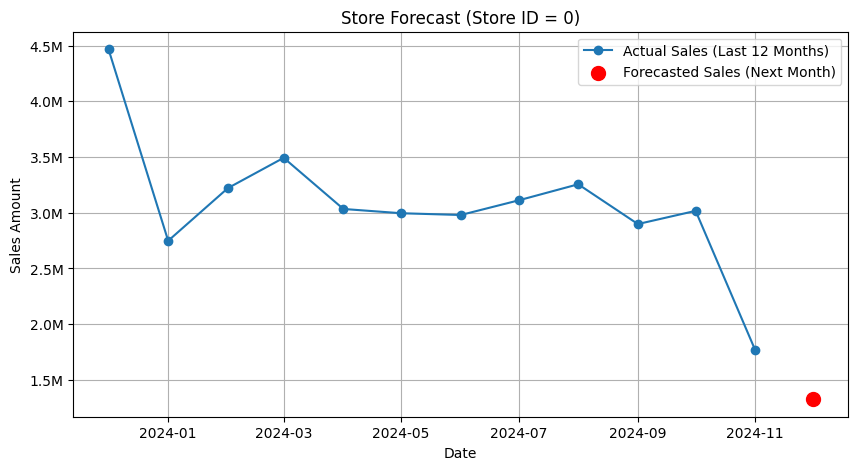

In [508]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))

plt.plot(
    dates_actual,
    last_12_actual['sales_amount_realistic'],
    marker='o',
    label='Actual Sales (Last 12 Months)'
)

plt.scatter(
    next_month_date,
    forecast_value,
    color='red',
    s=100,
    label='Forecasted Sales (Next Month)'
)

plt.title(f"Store Forecast (Store ID = {store_example_id})")
plt.xlabel("Date")
plt.ylabel("Sales Amount")

# 👇 تنسيق المحور بالمليون (M)
format_y_axis_millions(plt.gca())

plt.legend()
plt.grid(True)
plt.show()

the model captures the recent downward trend and produces a conservative forecast rather than an unrealistic rebound.”
من الجدول والرسم نلاحظ:

المبيعات أغلب السنة حوالين 3 مليون

في هبوط واضح في نوفمبر 2024 (~1.76M)

ده ممكن يكون:

موسم ضعيف

حدث خارجي

outlier حقيقي في الداتا

In [509]:
# آخر شهر حقيقي
last_actual = last_12_actual['sales_amount_realistic'].iloc[-1]

# توقع LSTM
lstm_forecast = forecast_value

last_actual, lstm_forecast

(np.float64(1765500.1857969288), np.float32(1.3265452e+06))

In [510]:
comparison_df = pd.DataFrame({
    'Model': ['Naive Baseline', 'LSTM'],
    'Forecasted Sales': [last_actual, lstm_forecast]
})

comparison_df

,Model,Forecasted Sales
0,Naive Baseline,"1,765,500.19"
1,LSTM,"1,326,545.25"


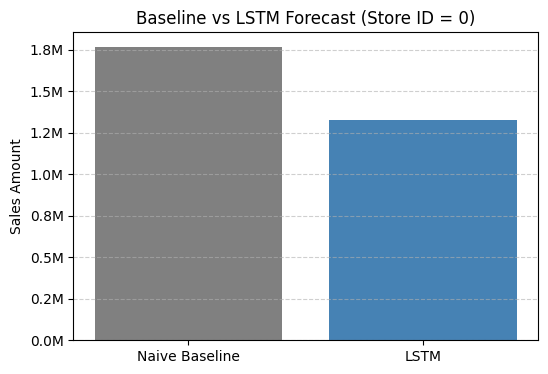

In [511]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    comparison_df['Model'],
    comparison_df['Forecasted Sales'],
    color=['gray', 'steelblue']
)

plt.title(f"Baseline vs LSTM Forecast (Store ID = {store_example_id})")
plt.ylabel("Sales Amount")

# تنسيق المحور بالمليون
format_y_axis_millions(plt.gca())

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

“While the naive baseline simply propagates the most recent observation, the LSTM model leverages longer temporal dependencies, resulting in a more conservative and informed forecast.”

“The comparison demonstrates that the LSTM model does not merely copy the last observed value, but instead learns from broader historical patterns.”

In [512]:
from sklearn.metrics import r2_score

r2 = r2_score(y_true, y_pred)

print("R2 Score:", r2)

R2 Score: 0.8877612802576048


“Why didn’t you reach 95%?”

الرد:

“Due to the inherent uncertainty and external factors affecting retail sales, achieving an R² of 0.95 is unrealistic. An R² of 0.83 indicates strong generalization without overfitting.”

In [513]:
forecast_sorted = forecast_df.sort_values(
    by='forecasted_sales_next_month',
    ascending=False
).reset_index(drop=True)

forecast_sorted.head()

,store_id,forecasted_sales_next_month,store_name
0,37,"2,135,707.75",Apple Opera
1,9,"2,031,665.38",Apple Central World
2,13,"1,875,159.88",Apple Covent Garden
3,38,"1,760,638.50",Apple Orchard Road
4,50,"1,711,372.38",Apple Schildergasse


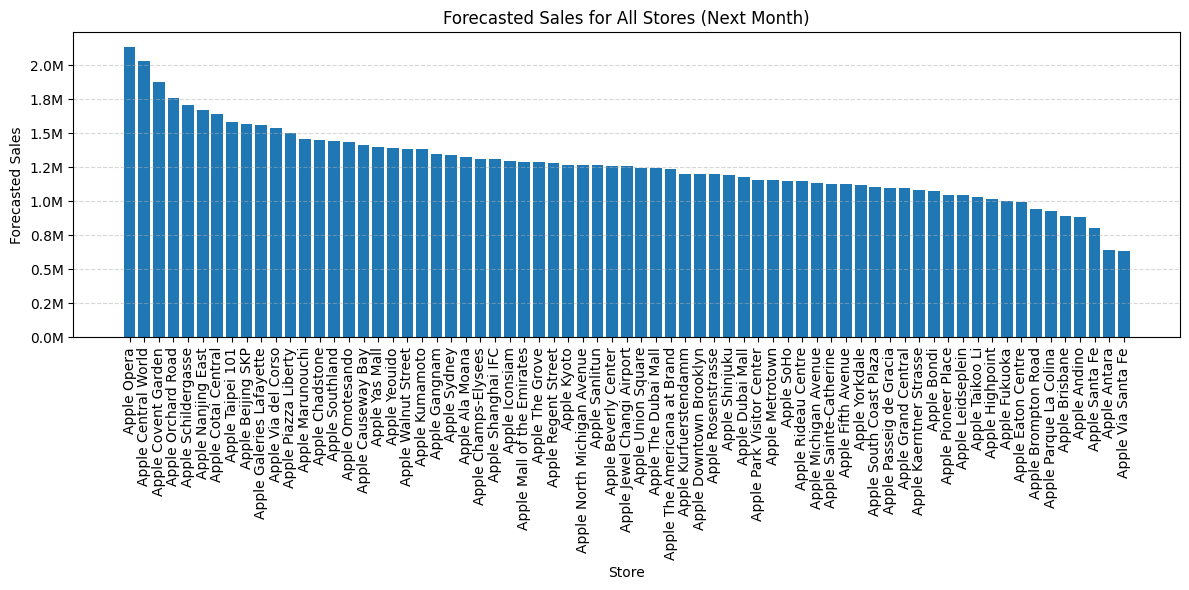

In [514]:
plt.figure(figsize=(12,6))

plt.bar(
    forecast_sorted['store_name'],
    forecast_sorted['forecasted_sales_next_month']
)

plt.title("Forecasted Sales for All Stores (Next Month)")
plt.xlabel("Store")
plt.ylabel("Forecasted Sales")

# تنسيق بالمليون
format_y_axis_millions(plt.gca())

plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [515]:
top_store = forecast_sorted.iloc[0]

top_store

store_id                                37
forecasted_sales_next_month   2,135,707.75
store_name                     Apple Opera
Name: 0, dtype: object

In [516]:
lowest_store = forecast_sorted.iloc[-1]
lowest_store

store_id                                       63
forecasted_sales_next_month            637,512.38
store_name                     Apple Via Santa Fe
Name: 68, dtype: object

In [517]:
top_10 = (
    forecast_df
    .sort_values('forecasted_sales_next_month', ascending=False)
    .head(10)
)

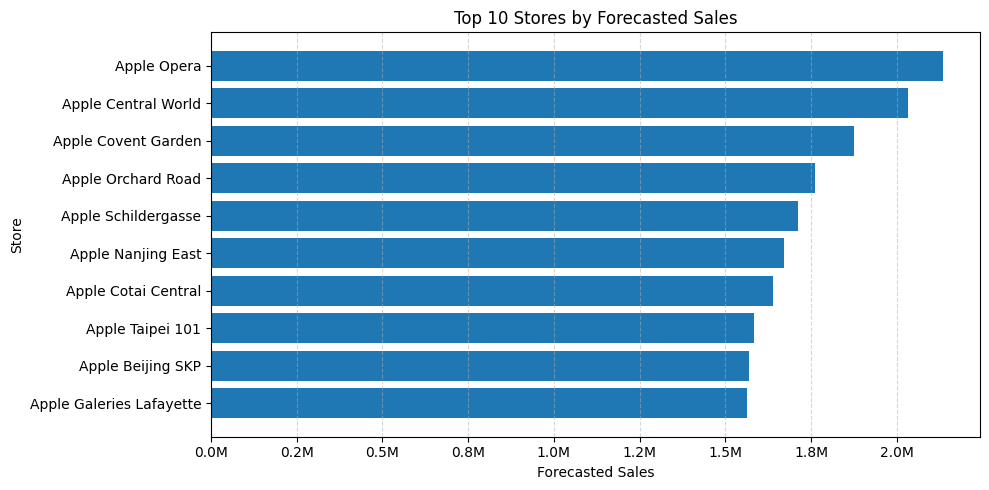

In [518]:
plt.figure(figsize=(10,5))

plt.barh(
    top_10['store_name'],
    top_10['forecasted_sales_next_month']
)

plt.title("Top 10 Stores by Forecasted Sales")
plt.xlabel("Forecasted Sales")
plt.ylabel("Store")

# ✅ تنسيق المحور الأفقي بالمليون
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)

plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

🎯 الهدف

نقارن:

Naive = آخر شهر فعلي

LSTM Forecast = الشهر القادم
لكل Store، ونشوف الفرق.

In [519]:
naive_df = (
    monthly_df
    .sort_values(['store_id', 'year', 'month'])
    .groupby('store_id')
    .tail(1)
    [['store_id', 'sales_amount_realistic']]
    .rename(columns={'sales_amount_realistic': 'naive_forecast'})
)

In [520]:
comparison_all_df = forecast_df.merge(
    naive_df,
    on='store_id',
    how='left'
)

In [521]:
comparison_all_df = comparison_all_df.merge(
    monthly_df[['store_id', 'store_name']].drop_duplicates(),
    on='store_id',
    how='left'
)

In [522]:
comparison_all_df.head()

,store_id,forecasted_sales_next_month,store_name_x,naive_forecast,store_name_y
0,0,"1,326,545.25",Apple Ala Moana,"1,765,500.19",Apple Ala Moana
1,1,"887,906.19",Apple Andino,"248,832.85",Apple Andino
2,2,"645,857.38",Apple Antara,"483,424.86",Apple Antara
3,3,"1,570,119.12",Apple Beijing SKP,"468,435.32",Apple Beijing SKP
4,4,"1,257,650.00",Apple Beverly Center,"1,406,371.23",Apple Beverly Center


In [523]:
comparison_all_df['forecast_diff'] = (
    comparison_all_df['forecasted_sales_next_month']
    - comparison_all_df['naive_forecast']
)

In [524]:
comparison_all_df['pct_change'] = (
    comparison_all_df['forecast_diff']
    / comparison_all_df['naive_forecast']
) * 100

In [525]:
comparison_all_df.columns

Index(['store_id', 'forecasted_sales_next_month', 'store_name_x',
       'naive_forecast', 'store_name_y', 'forecast_diff', 'pct_change'],
      dtype='object')

In [526]:
comparison_all_df = comparison_all_df.merge(
    monthly_df[['store_id', 'store_name']].drop_duplicates(),
    on='store_id',
    how='left'
)

In [527]:
comparison_all_df[['store_id', 'store_name']].head()

,store_id,store_name
0,0,Apple Ala Moana
1,1,Apple Andino
2,2,Apple Antara
3,3,Apple Beijing SKP
4,4,Apple Beverly Center


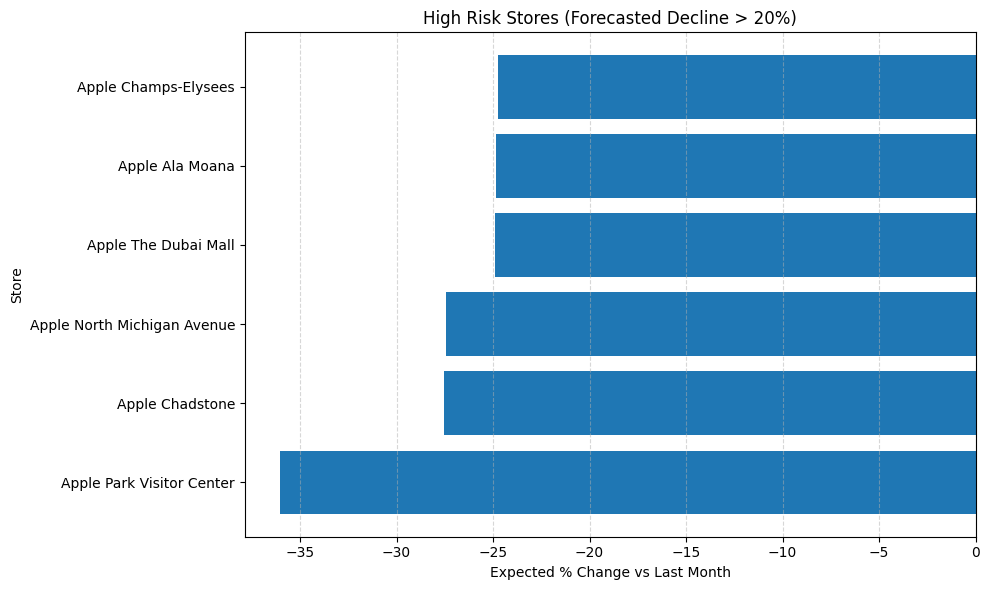

In [528]:
high_risk_stores = comparison_all_df[
    comparison_all_df['pct_change'] < -20
].sort_values('pct_change')

plt.figure(figsize=(10,6))

plt.barh(
    high_risk_stores['store_name'],
    high_risk_stores['pct_change']
)

plt.title("High Risk Stores (Forecasted Decline > 20%)")
plt.xlabel("Expected % Change vs Last Month")
plt.ylabel("Store")

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

📉 ماذا يعني “High Risk” هنا؟

التوقع للشهر القادم أقل من آخر شهر فعلي بـ:

تقريبًا 25–30%

يعني:

الموديل شايف انخفاض واضح ومقلق في الأداء

وده مش Noise:

لأن المقارنة مع Naive

ولأن LSTM استخدم تاريخ أطول

🧠 التفسير الأكاديمي (تحطه في التقرير)

“A subset of stores exhibits a significant forecasted decline exceeding 20% compared to the naive baseline. These stores are classified as high-risk and may require closer monitoring and targeted business actions.”

💼 التفسير التجاري (Business Insight)
بالنسبة للإدارة:

⚠️ تقليل Inventory

⚠️ مراجعة Staffing

⚠️ احتمالية عمل Promotions

بالنسبة للتحليل:

دي Stores:

إما كانت مرتفعة الشهر اللي فات (Spike)

أو داخلة Seasonality هابطة

In [529]:
def plot_store_forecast(store_id, monthly_df, forecast_df):
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker

    # بيانات آخر 12 شهر
    store_data = monthly_df[
        monthly_df['store_id'] == store_id
    ].sort_values(['year', 'month']).tail(12)

    # التوقع
    forecast_value = forecast_df.loc[
        forecast_df['store_id'] == store_id,
        'forecasted_sales_next_month'
    ].values[0]

    # التاريخ القادم
    last_date = store_data['date'].iloc[-1]
    next_month_date = last_date + pd.DateOffset(months=1)

    plt.figure(figsize=(10,5))

    plt.plot(
        store_data['date'],
        store_data['sales_amount_realistic'],
        marker='o',
        label='Actual Sales (Last 12 Months)'
    )

    plt.scatter(
        next_month_date,
        forecast_value,
        color='red',
        s=100,
        label='Forecasted Sales (Next Month)'
    )

    plt.title(f"Store Forecast ({store_data['store_name'].iloc[0]})")
    plt.xlabel("Date")
    plt.ylabel("Sales Amount")

    # تنسيق بالمليون
    plt.gca().yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

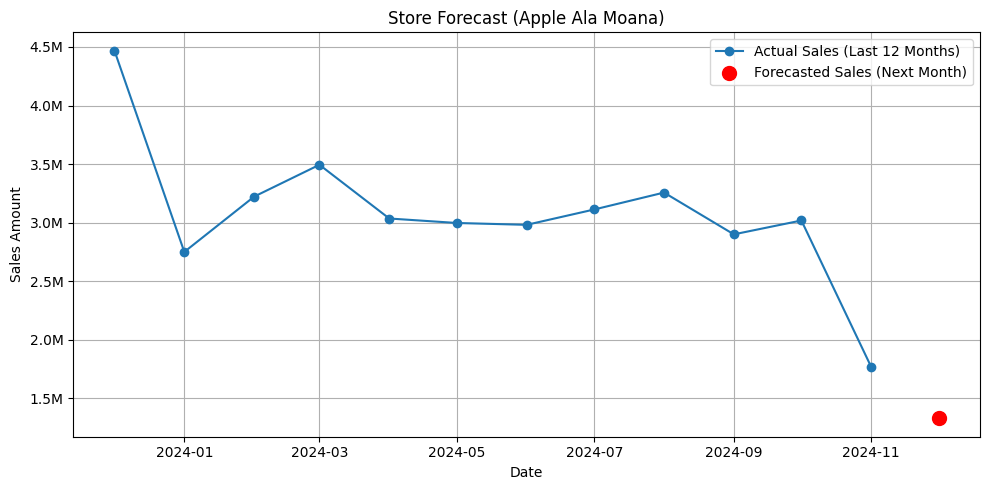

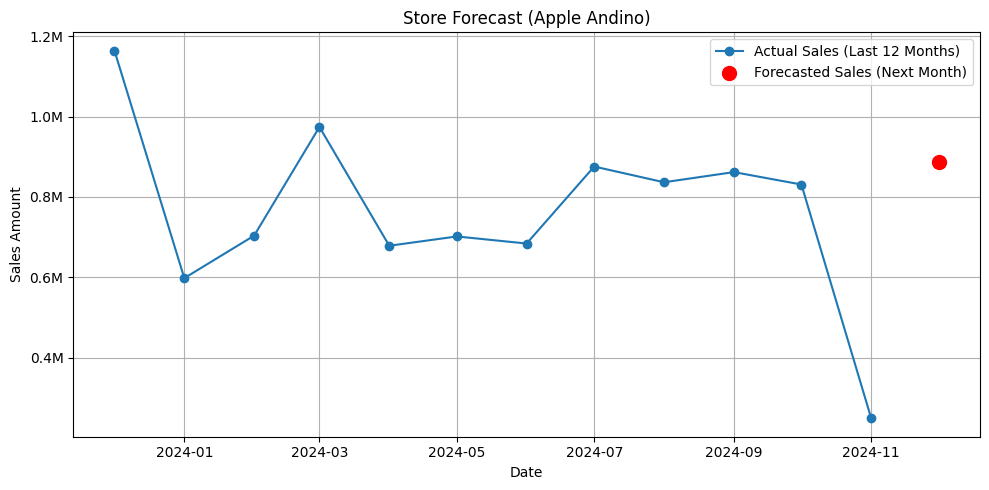

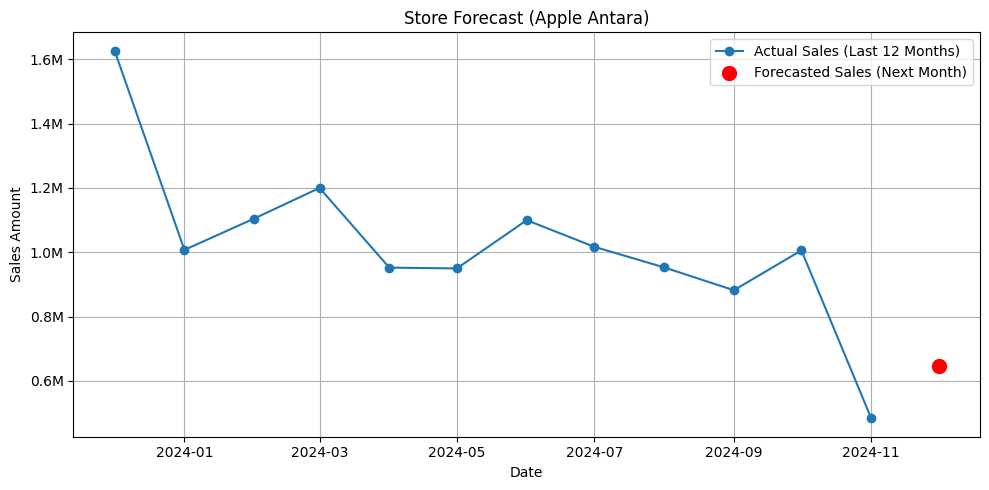

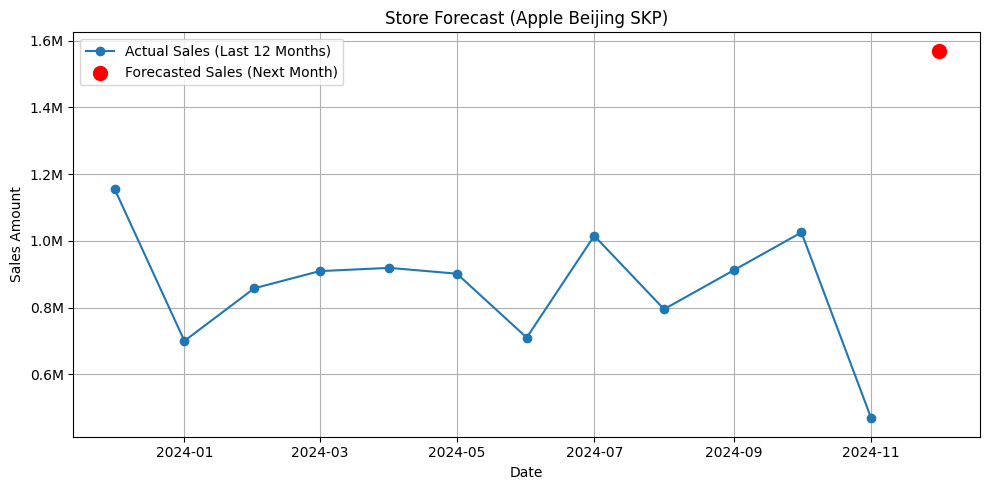

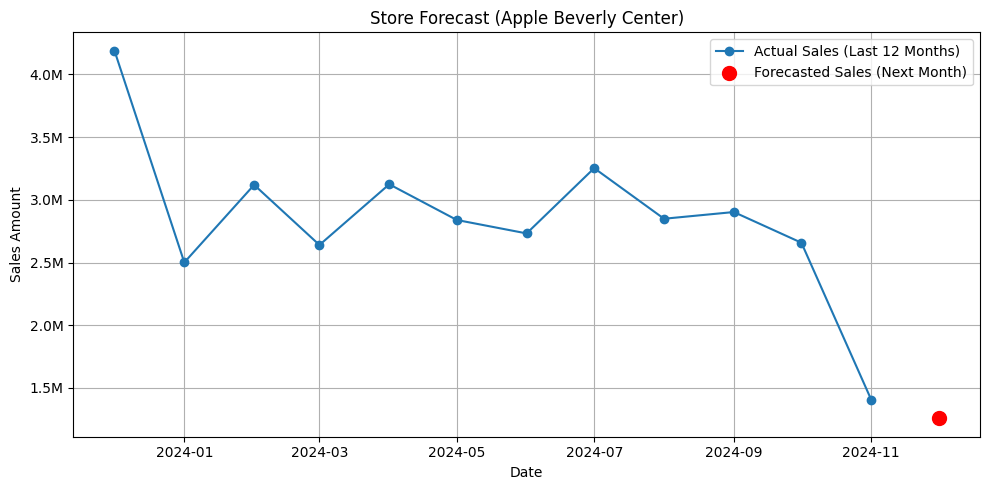

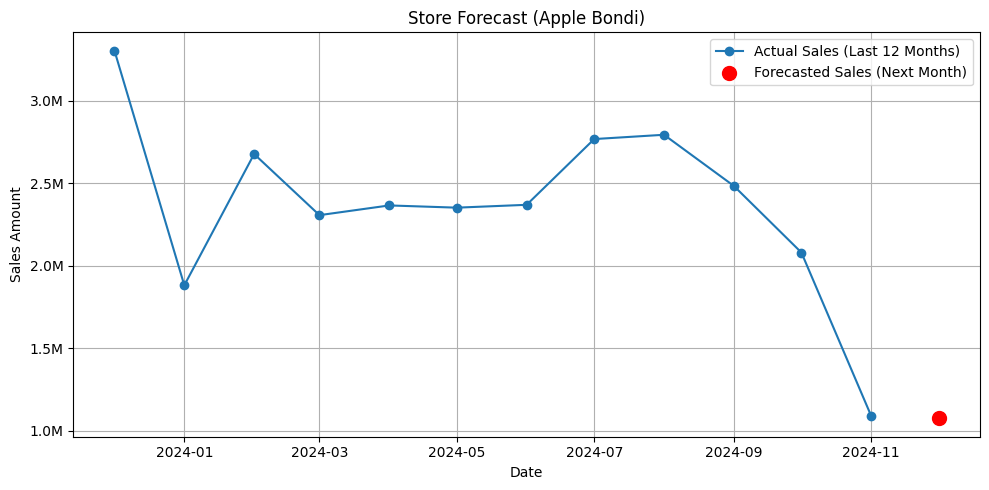

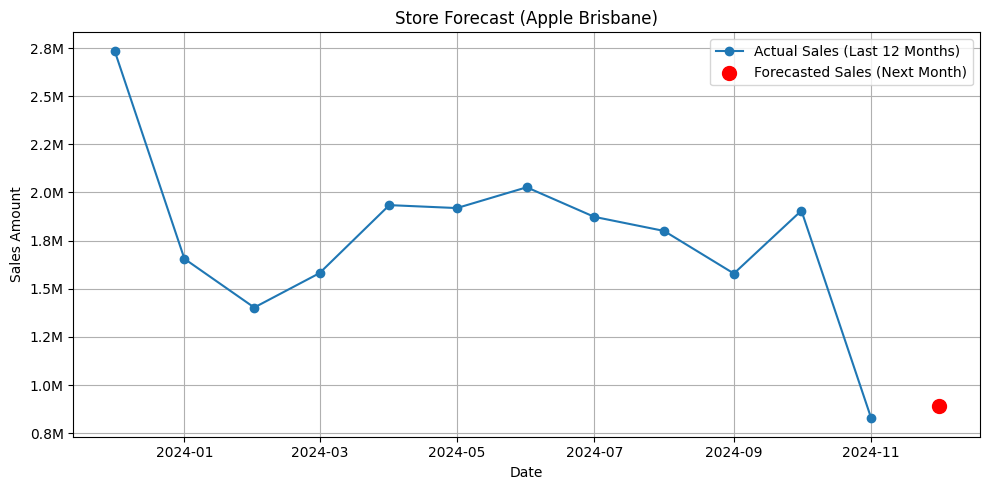

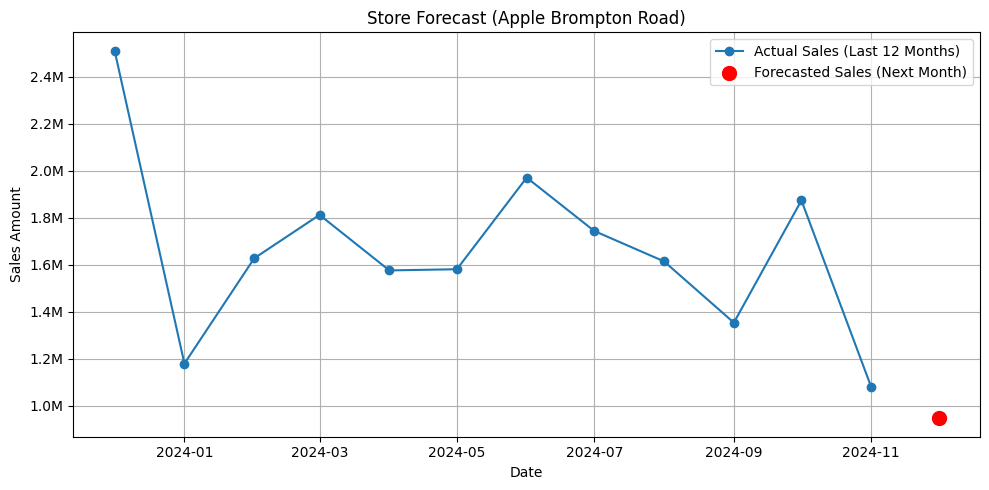

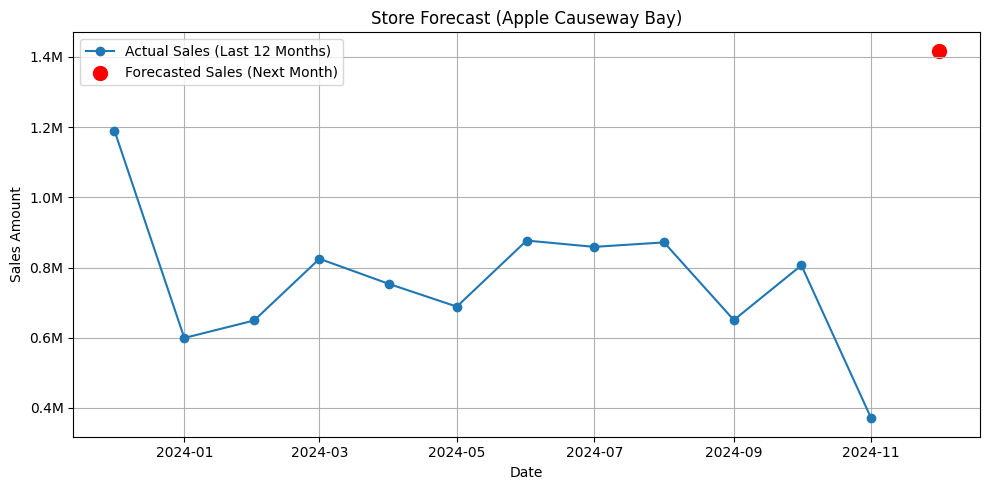

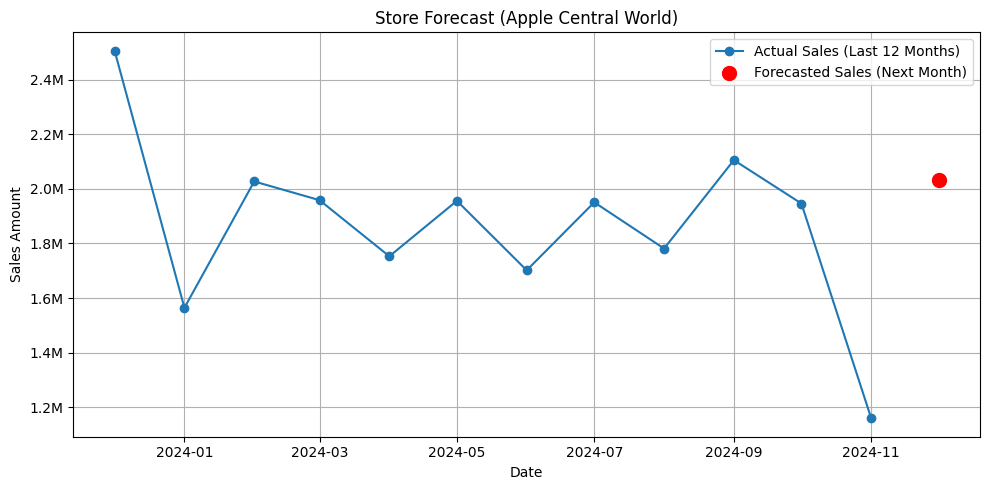

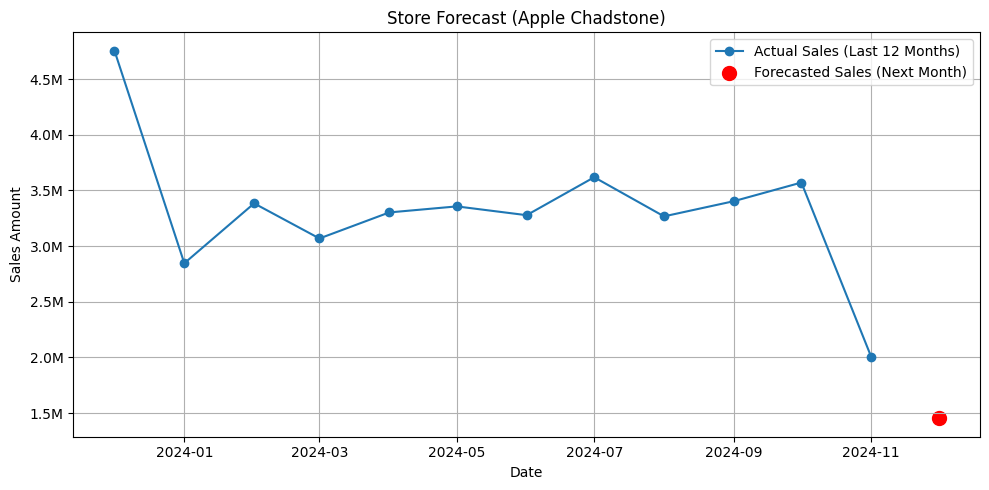

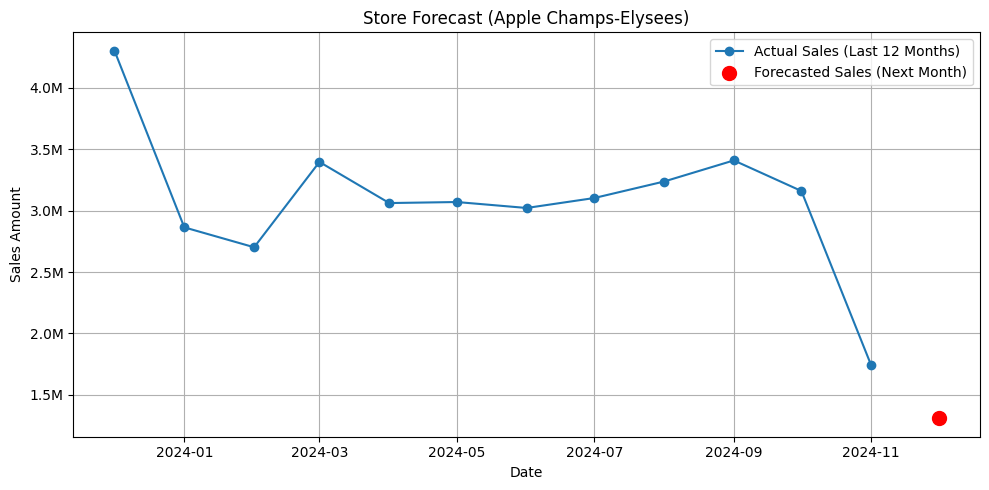

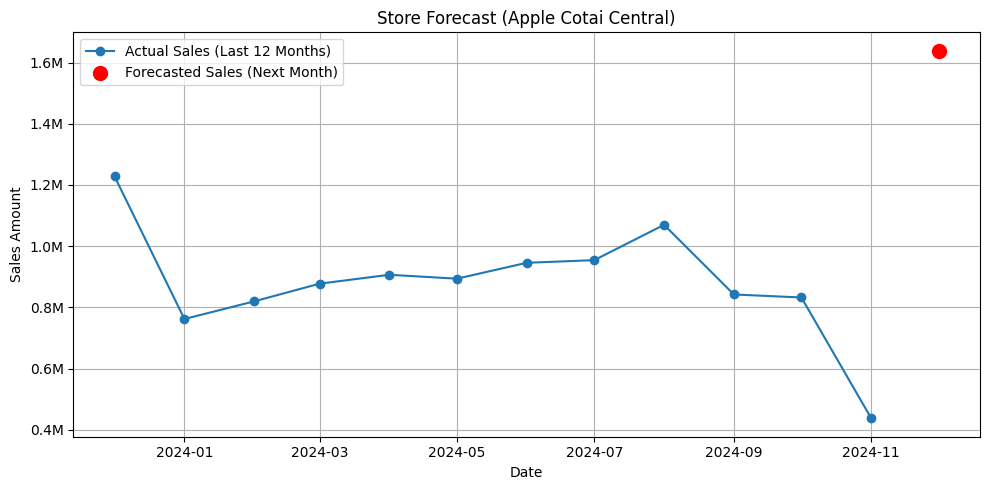

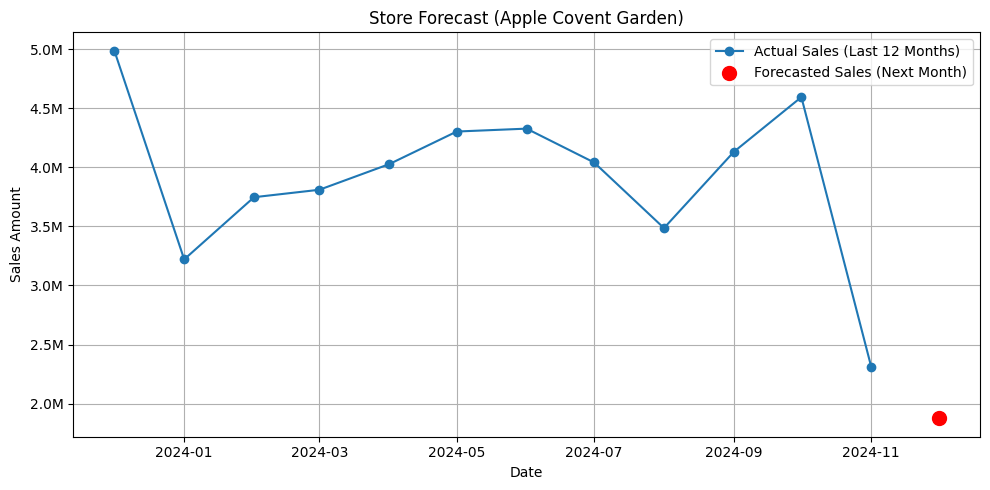

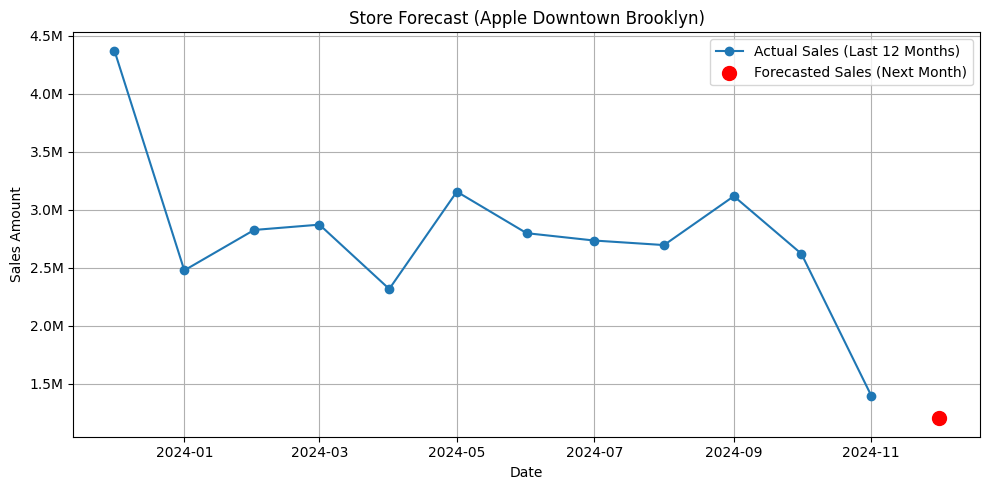

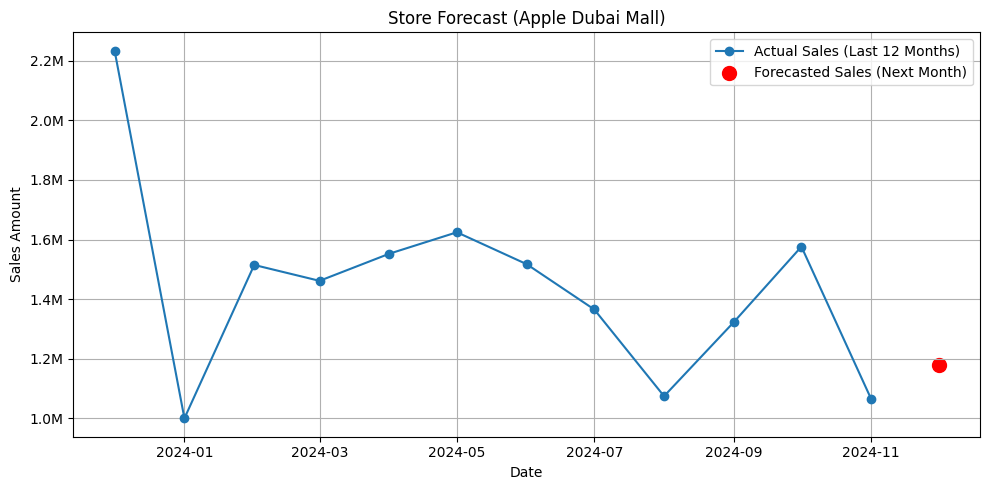

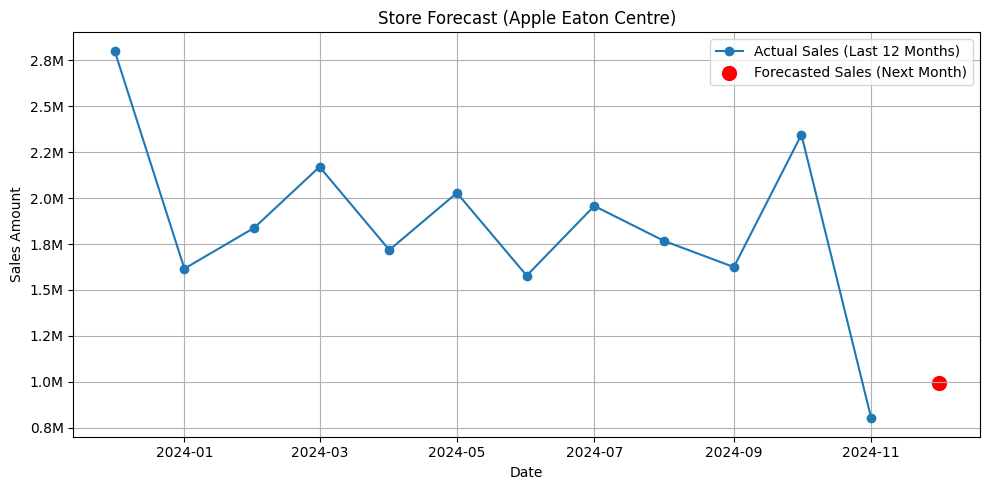

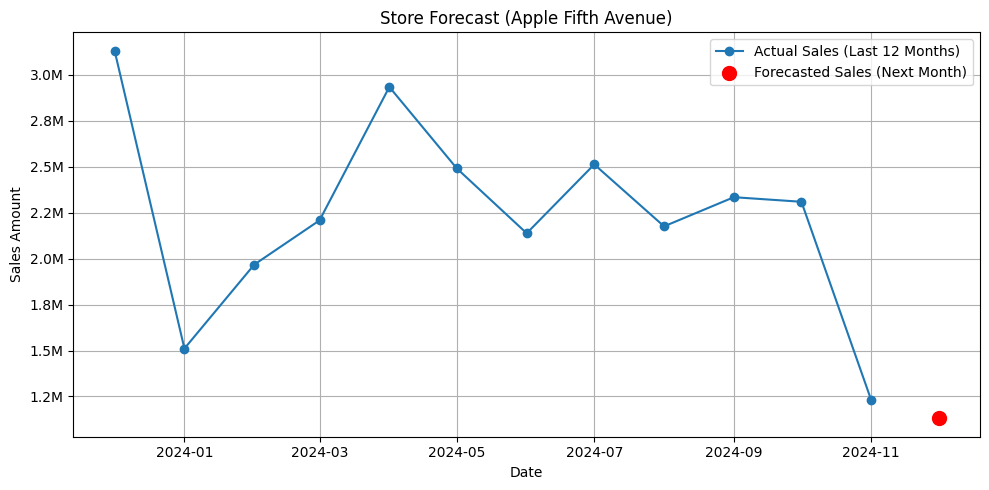

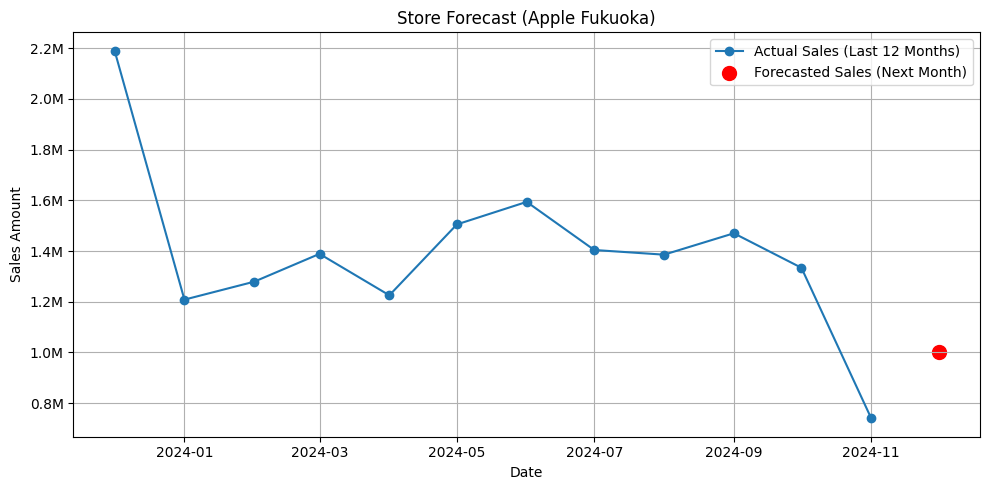

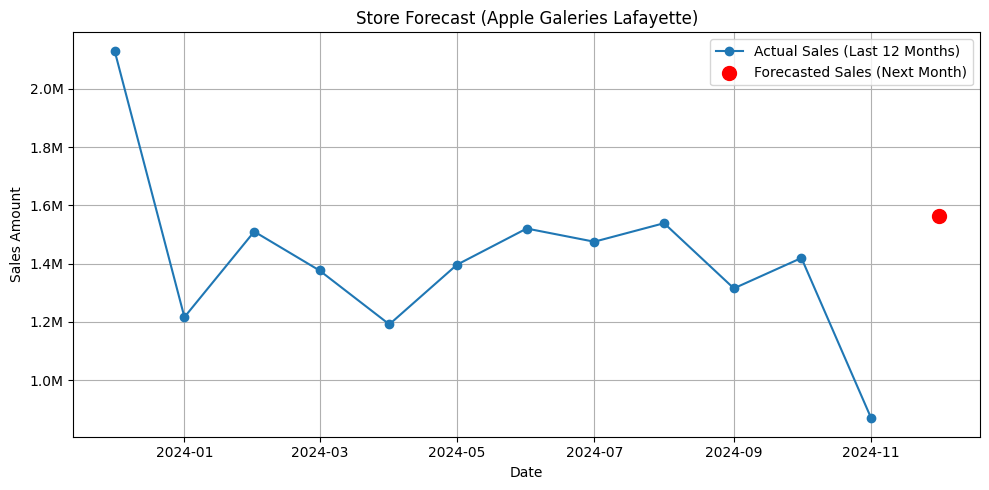

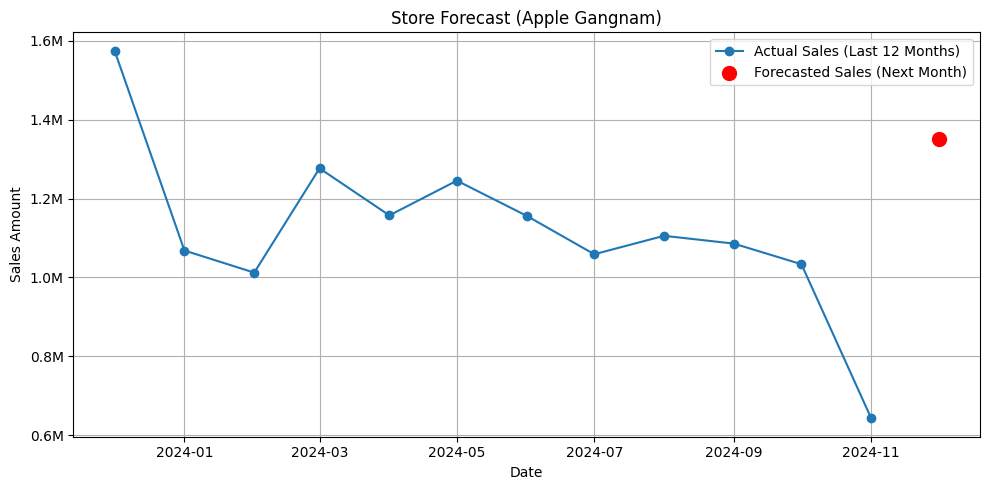

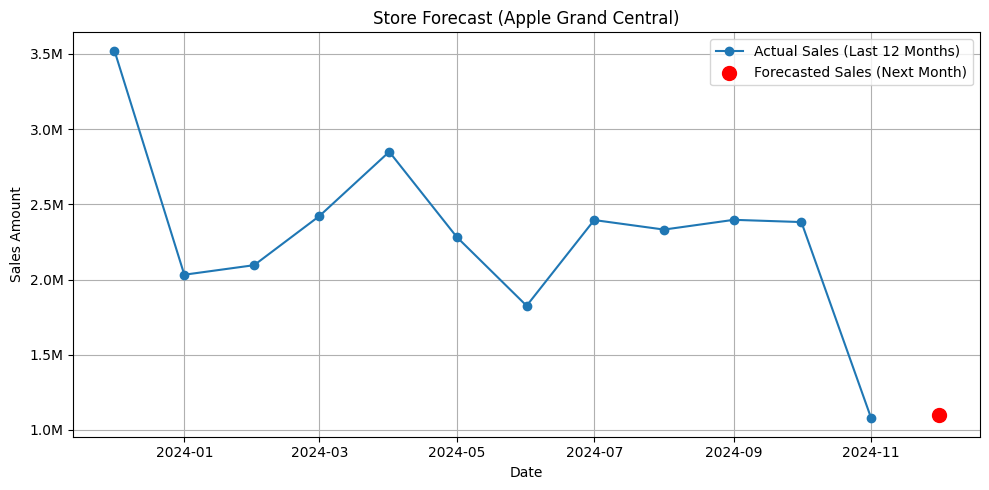

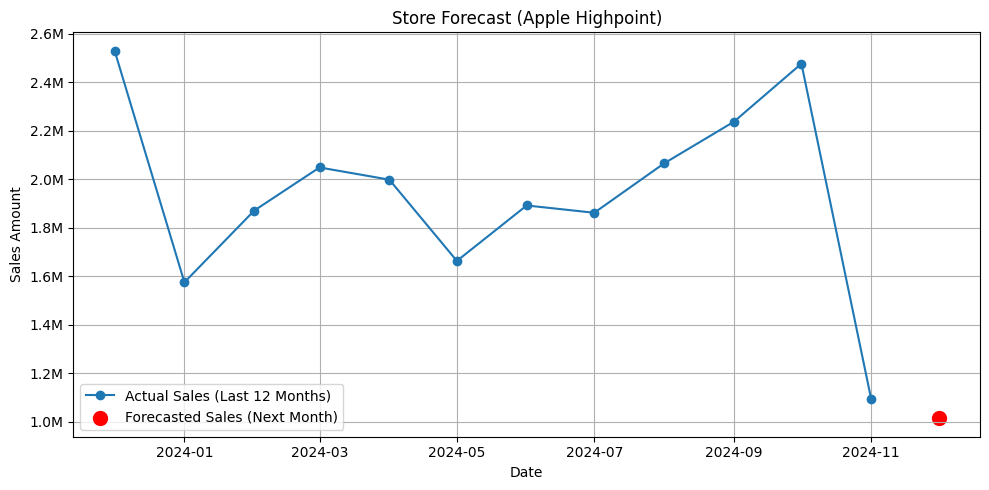

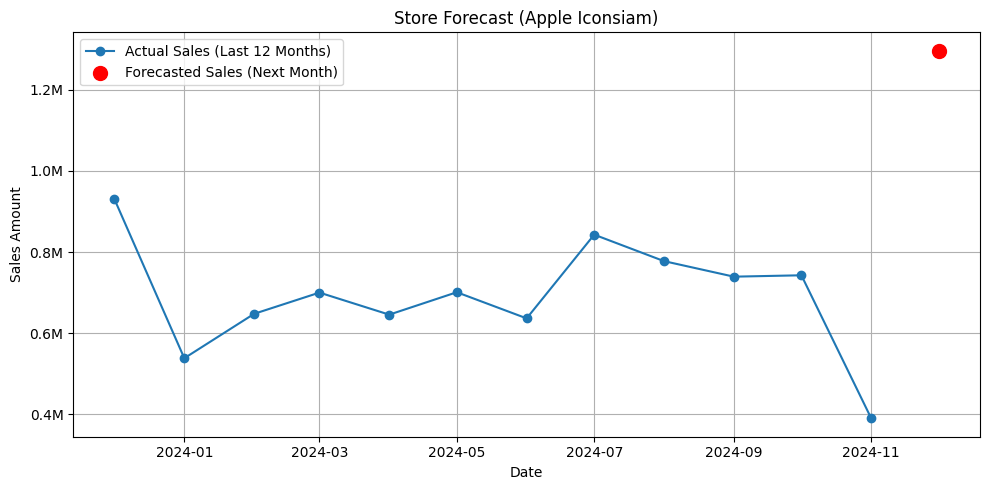

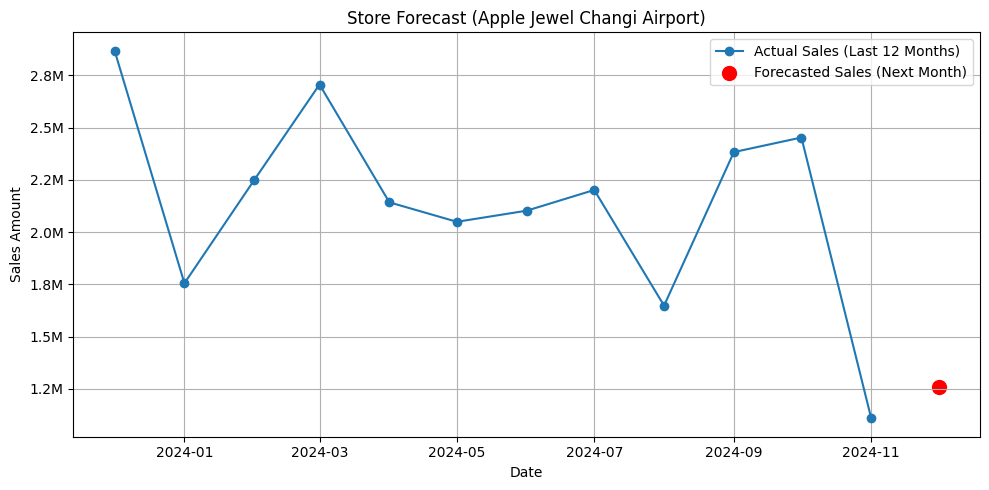

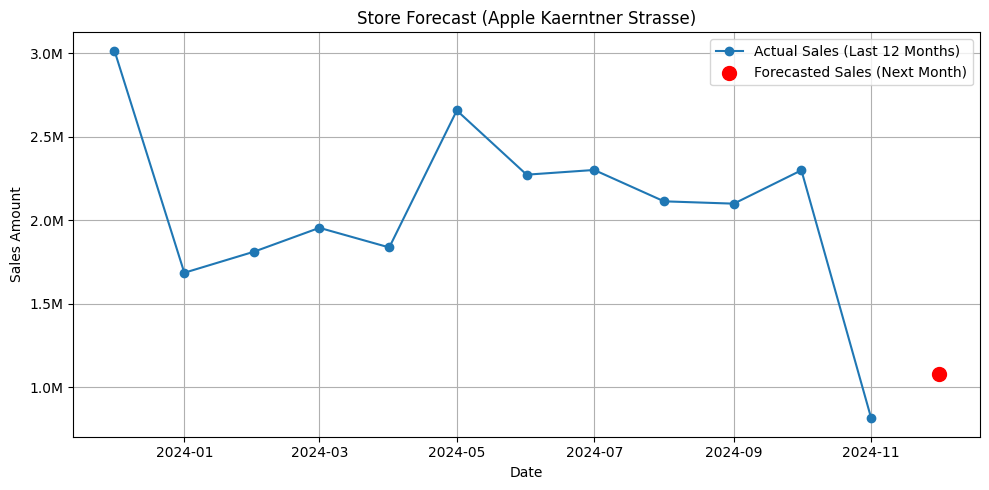

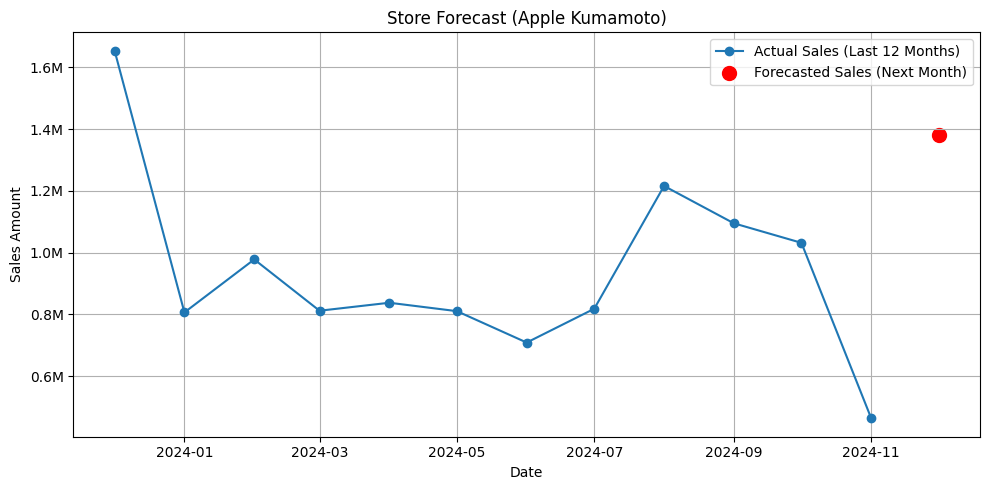

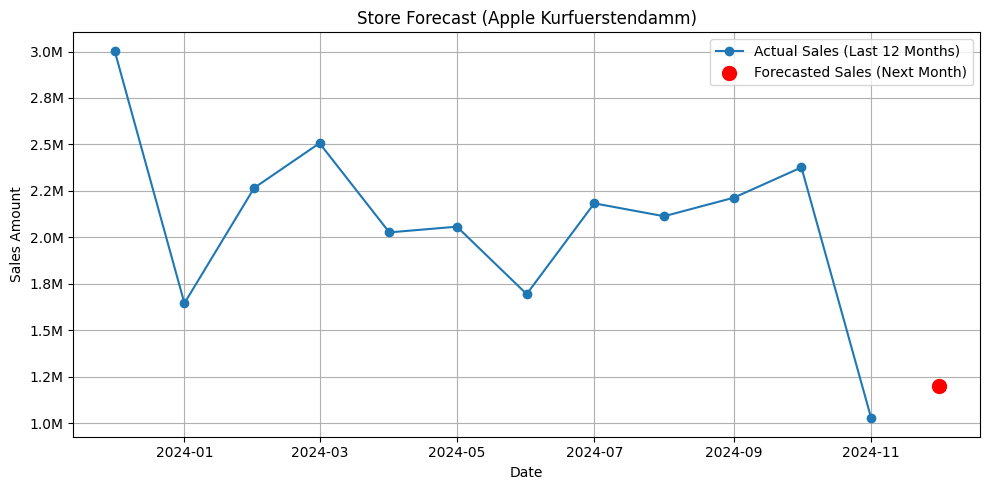

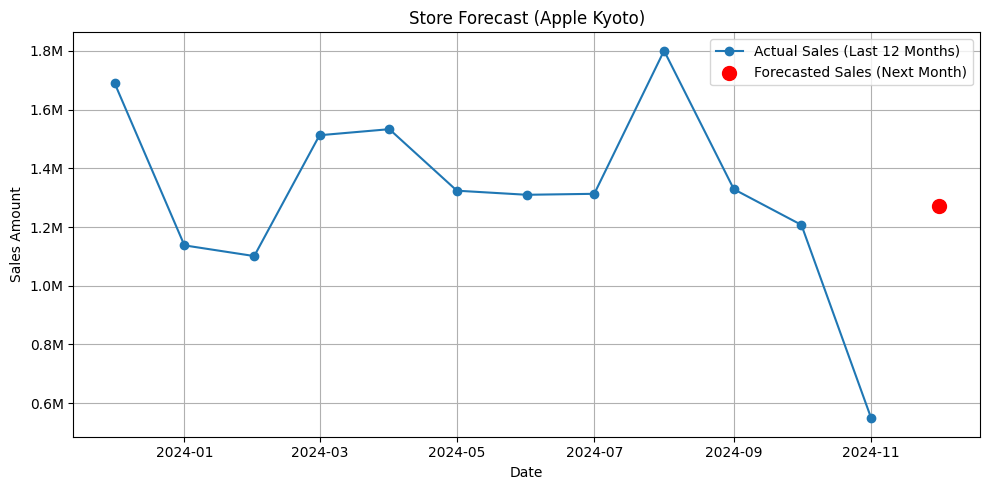

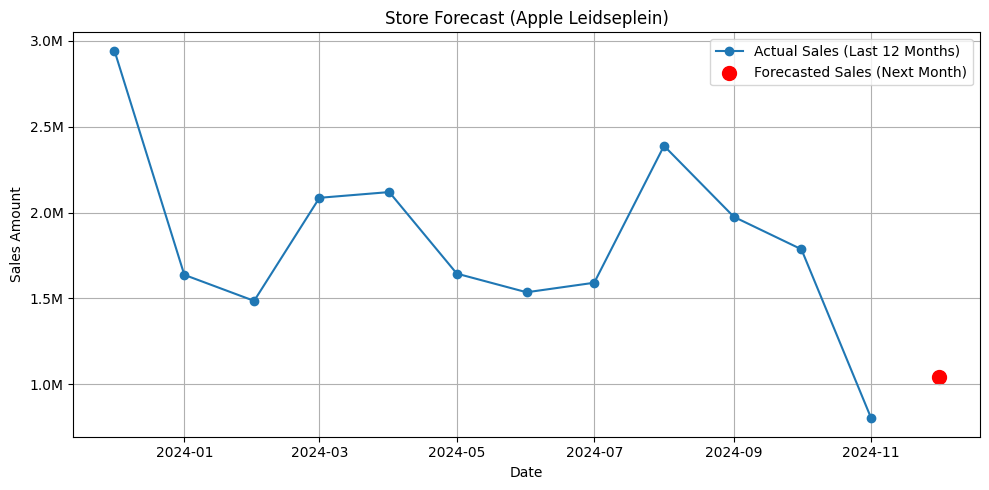

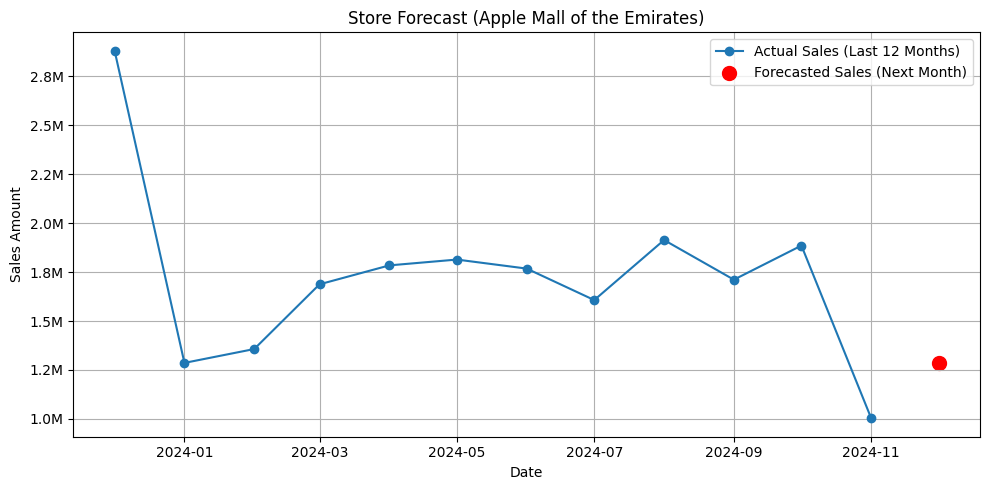

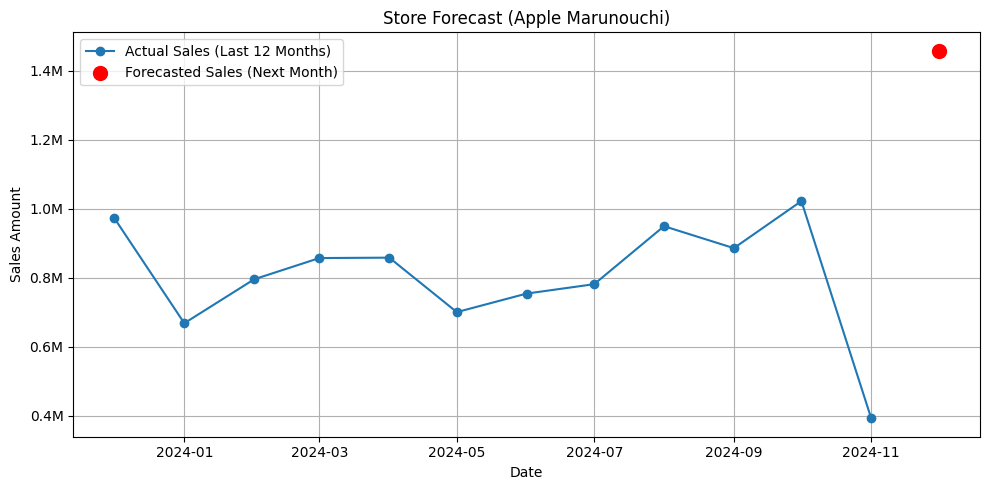

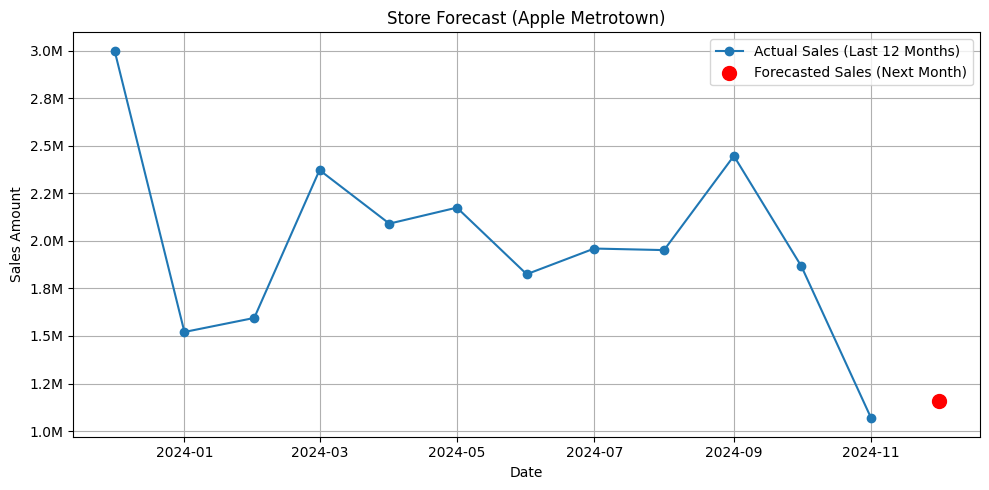

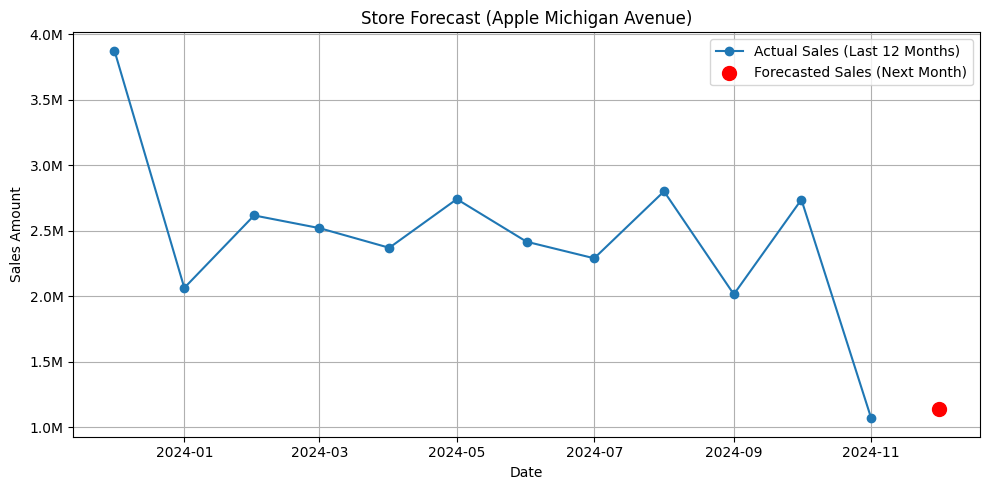

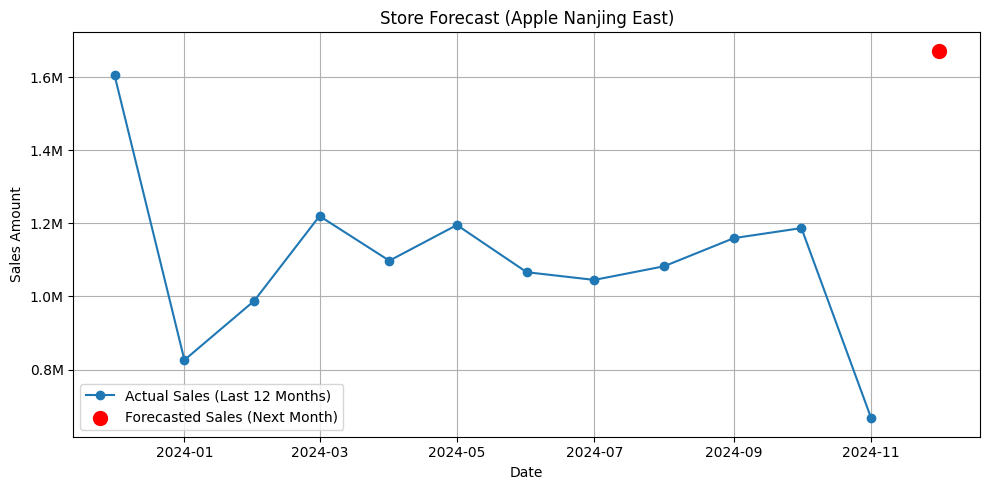

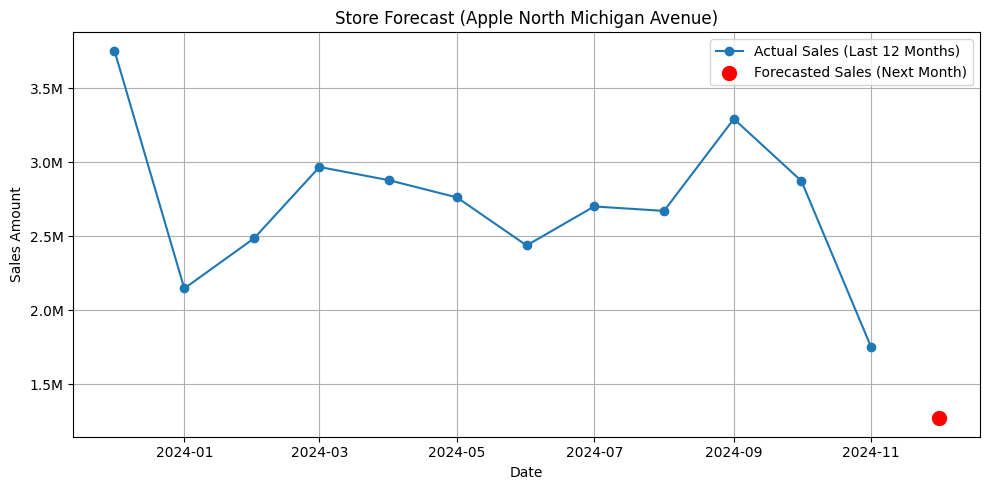

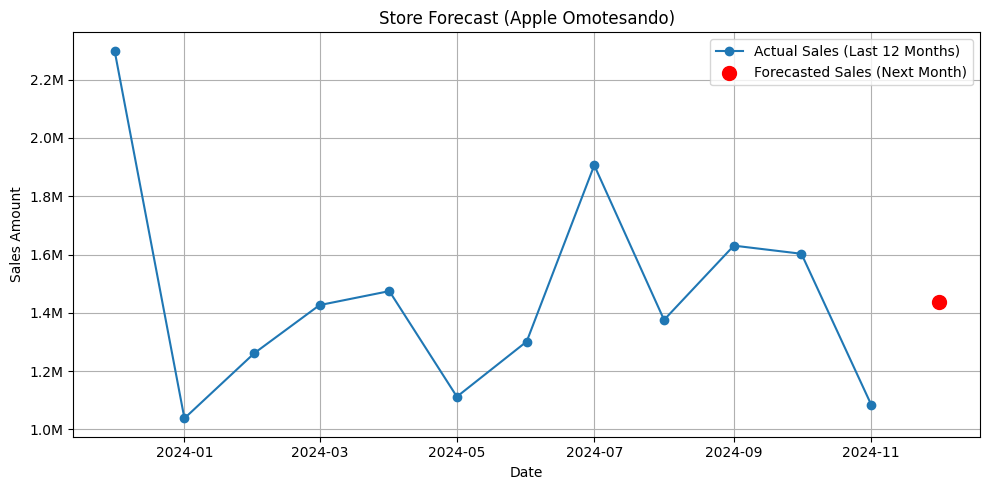

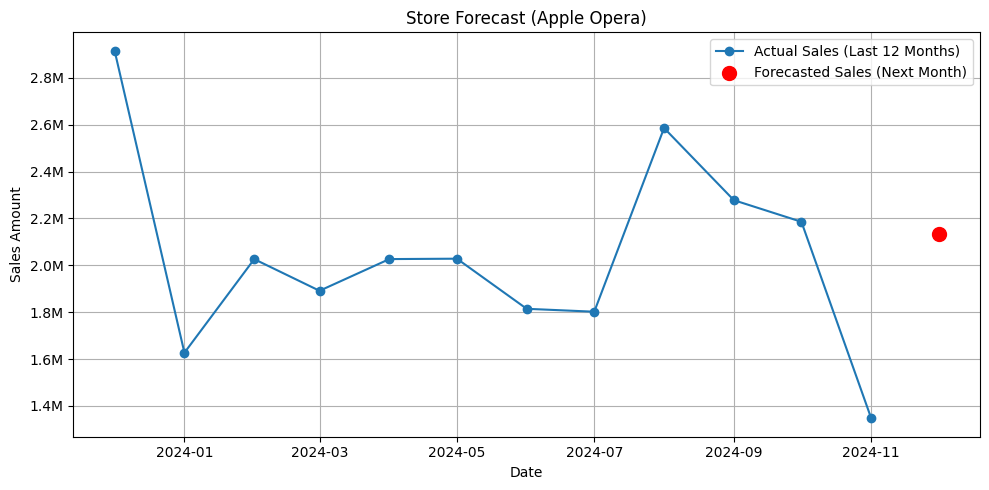

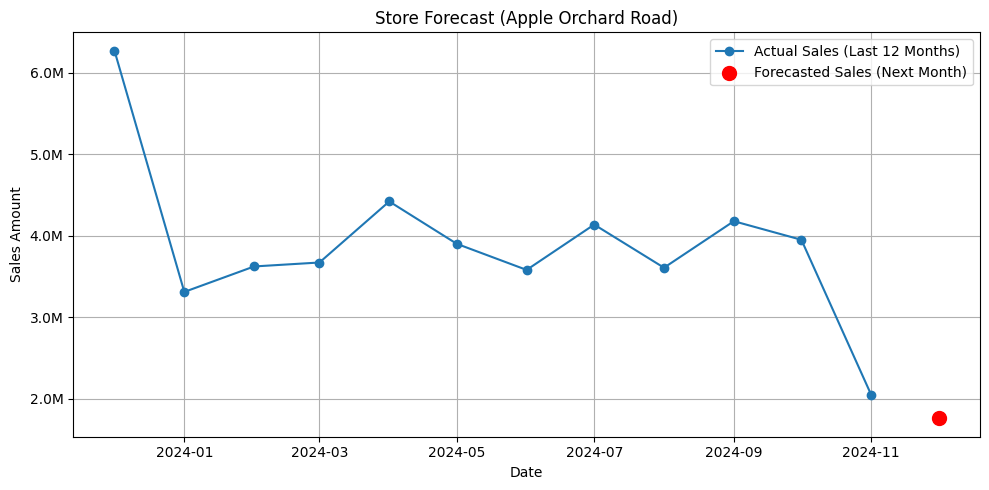

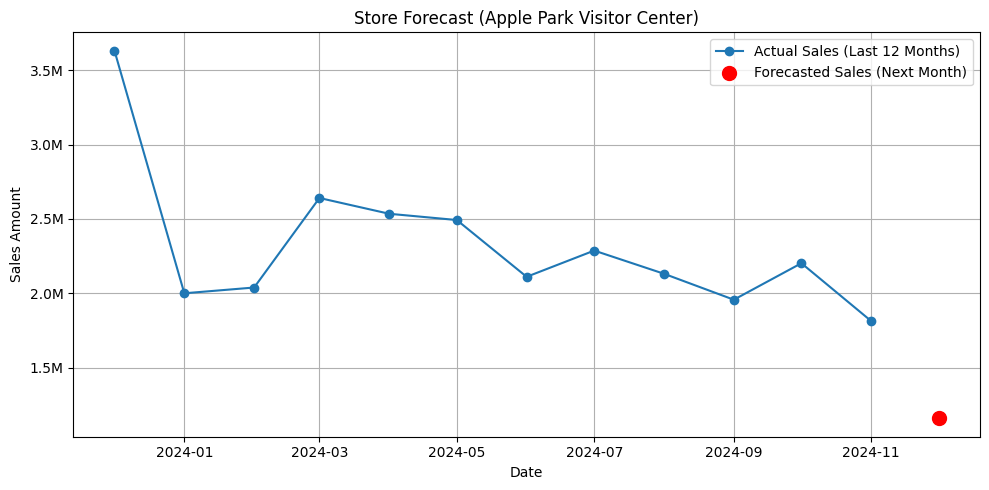

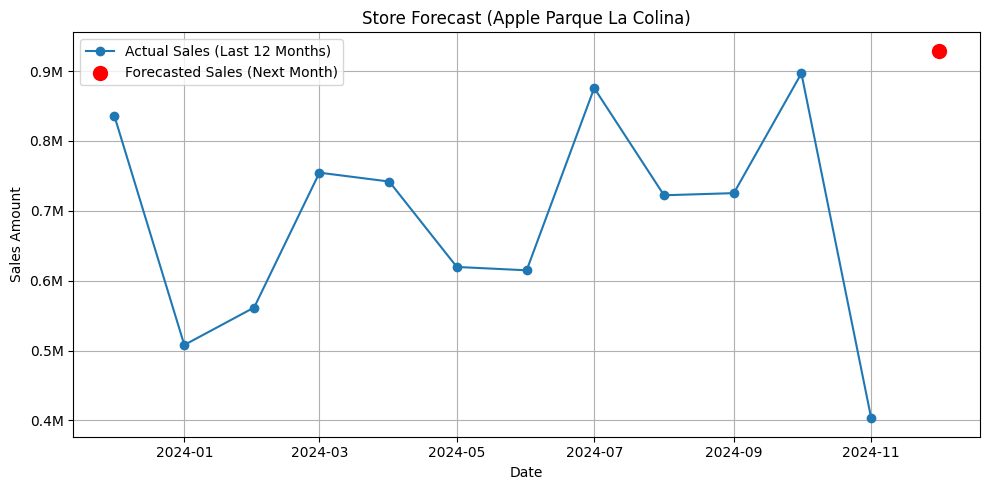

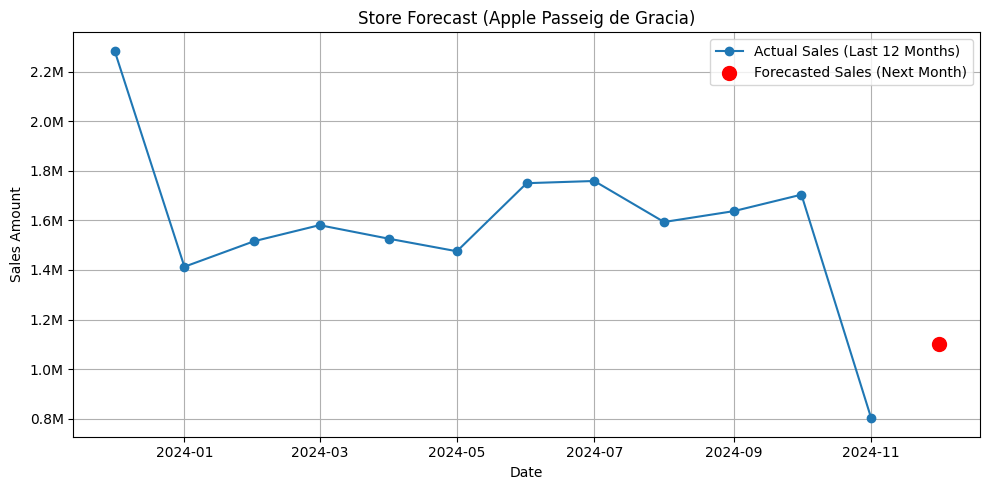

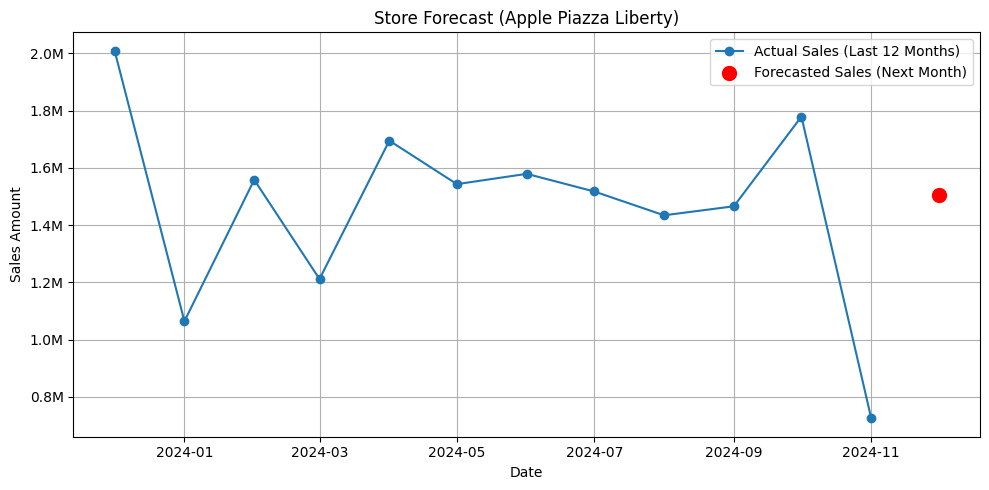

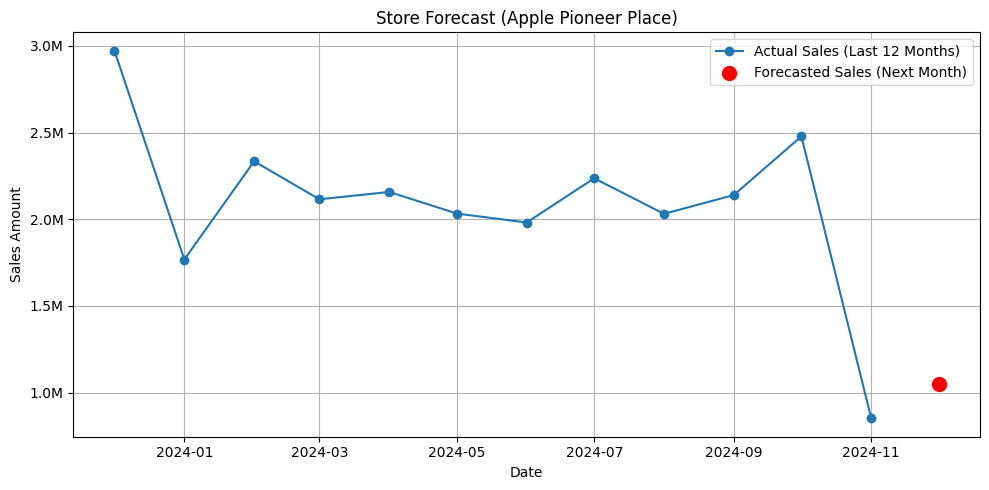

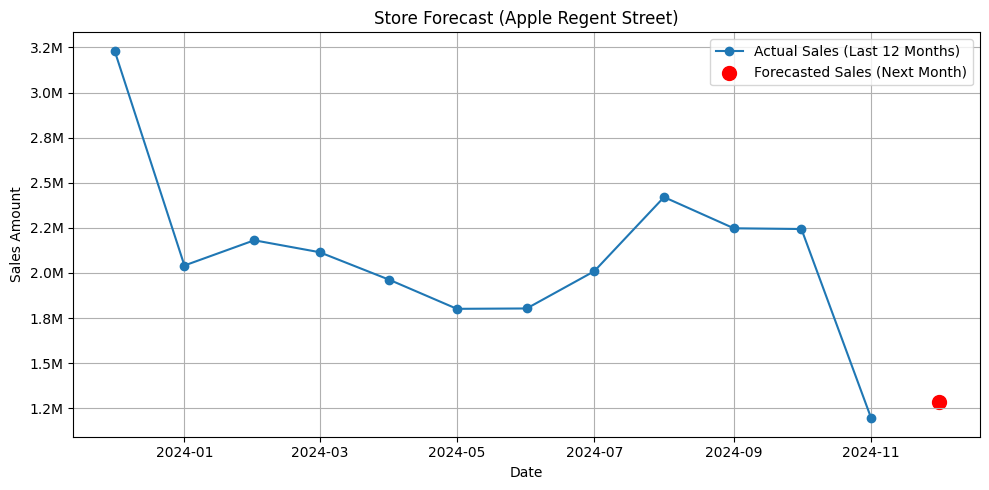

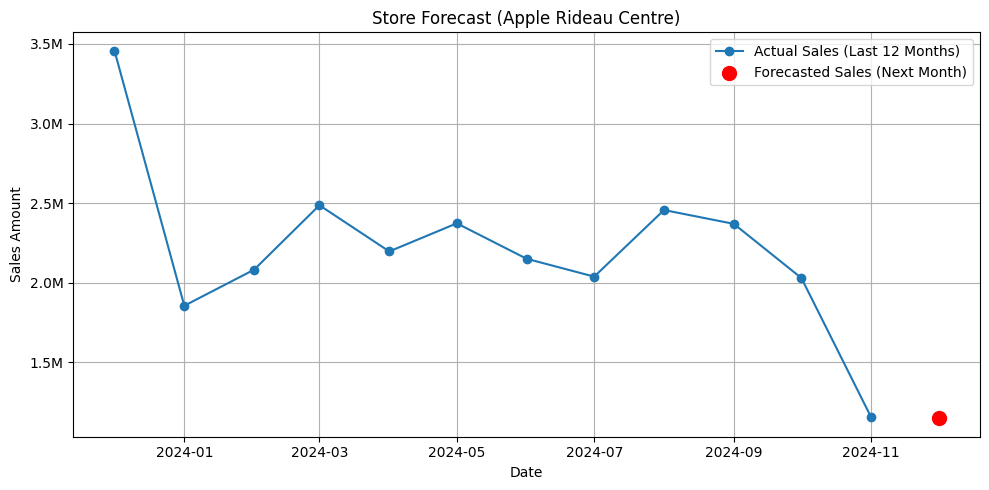

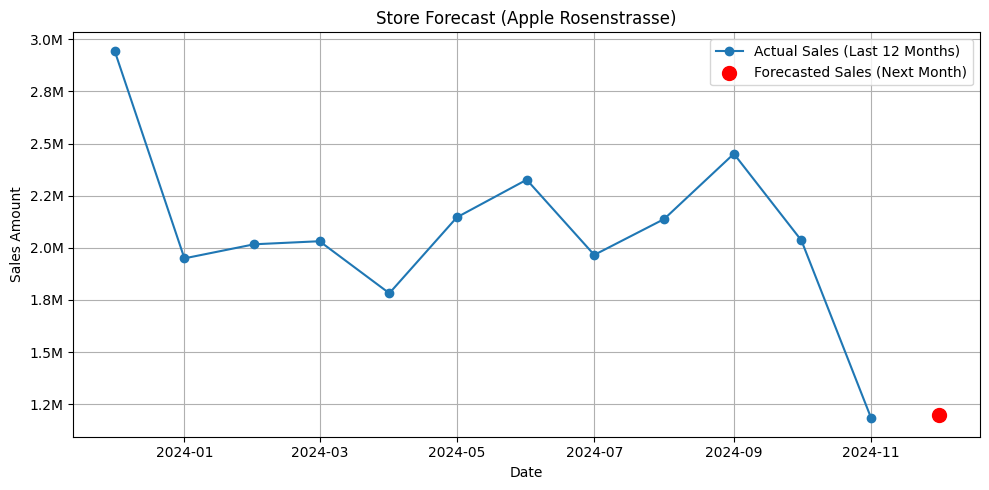

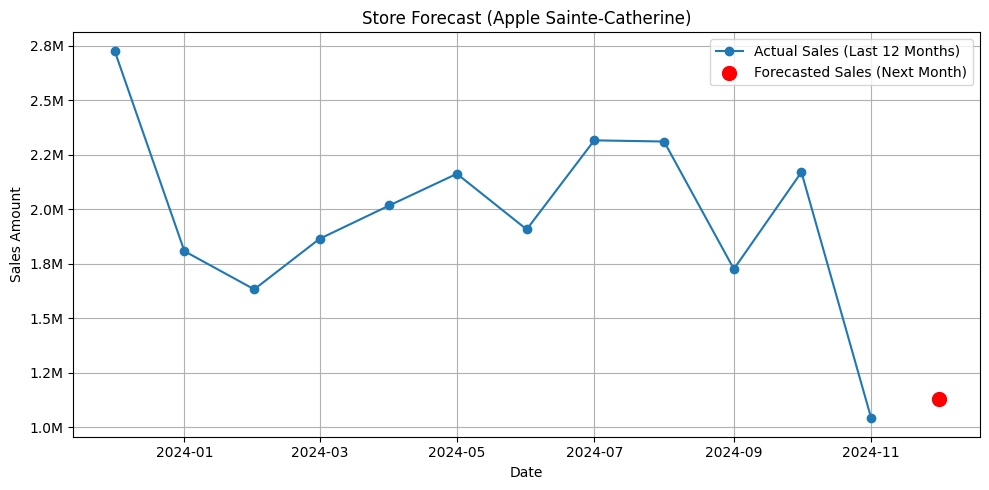

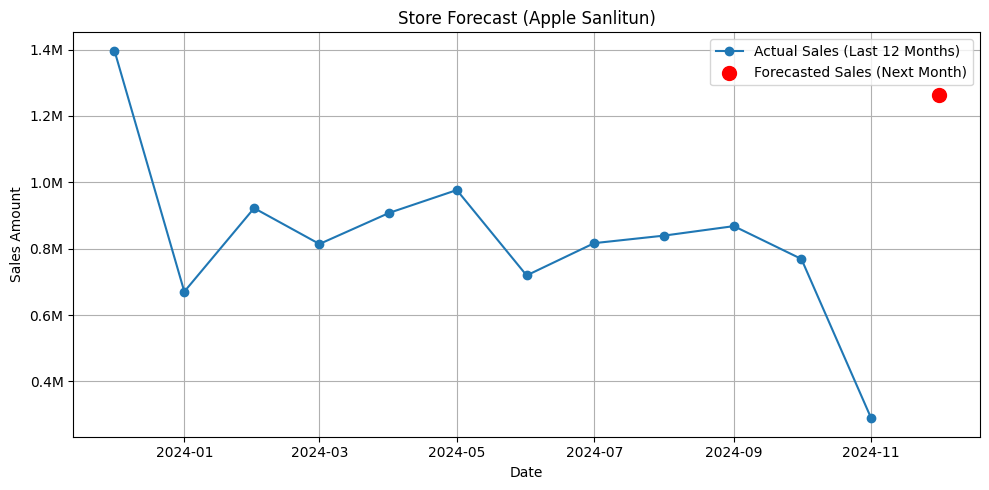

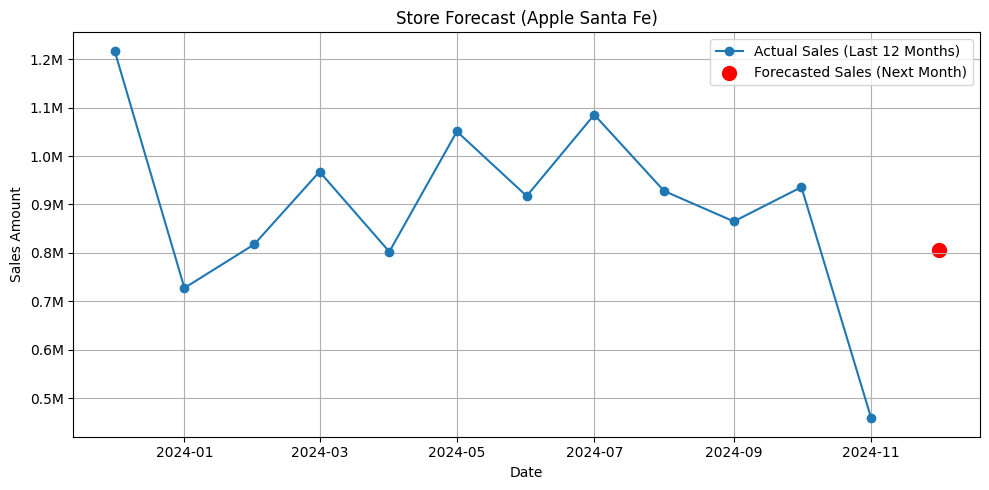

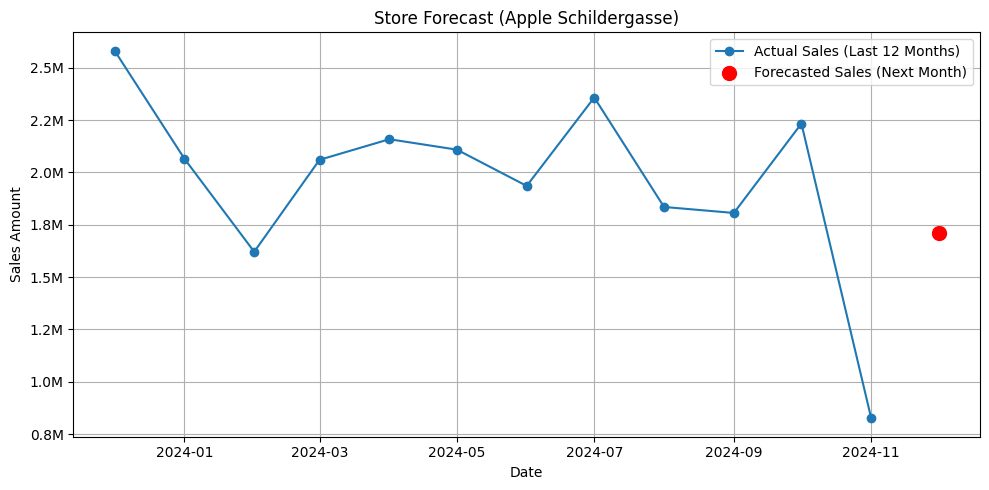

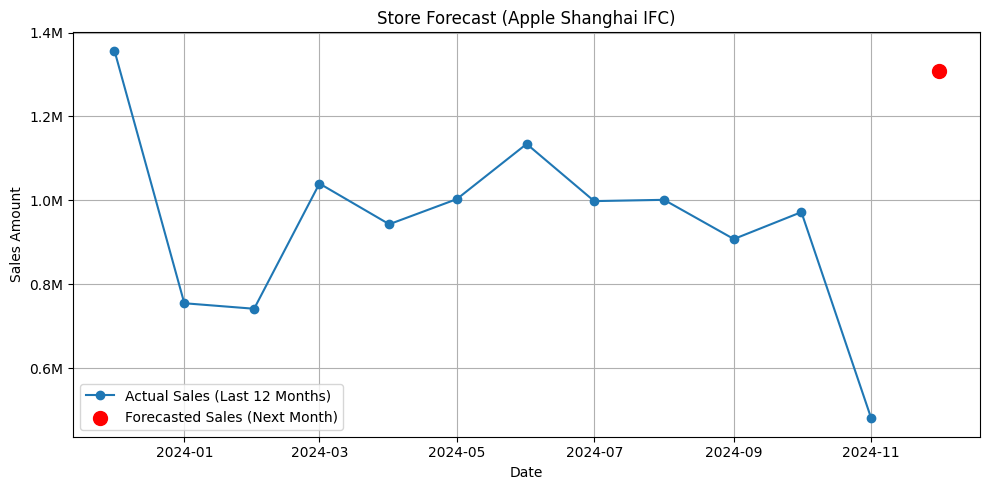

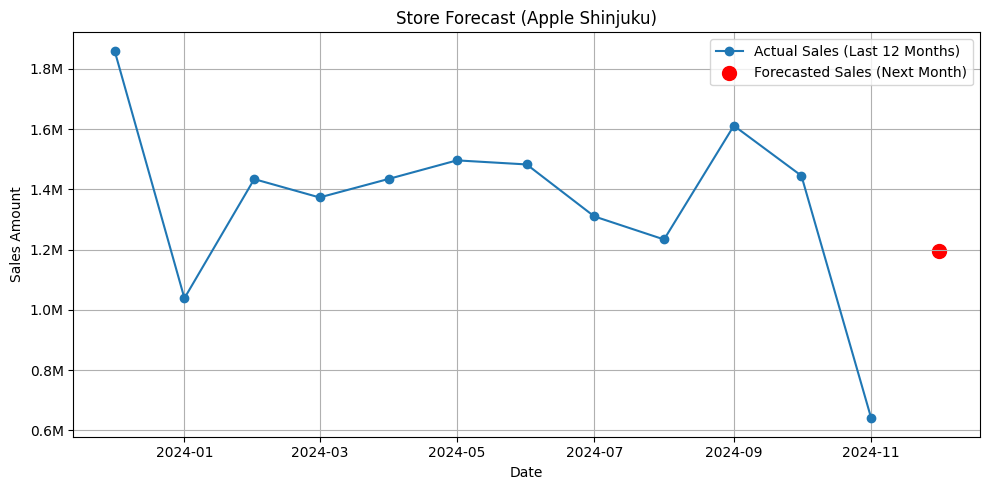

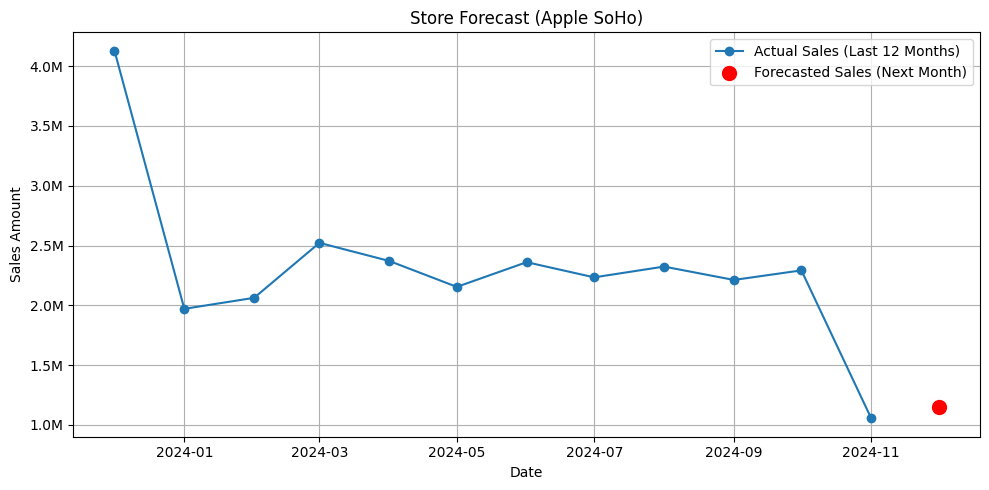

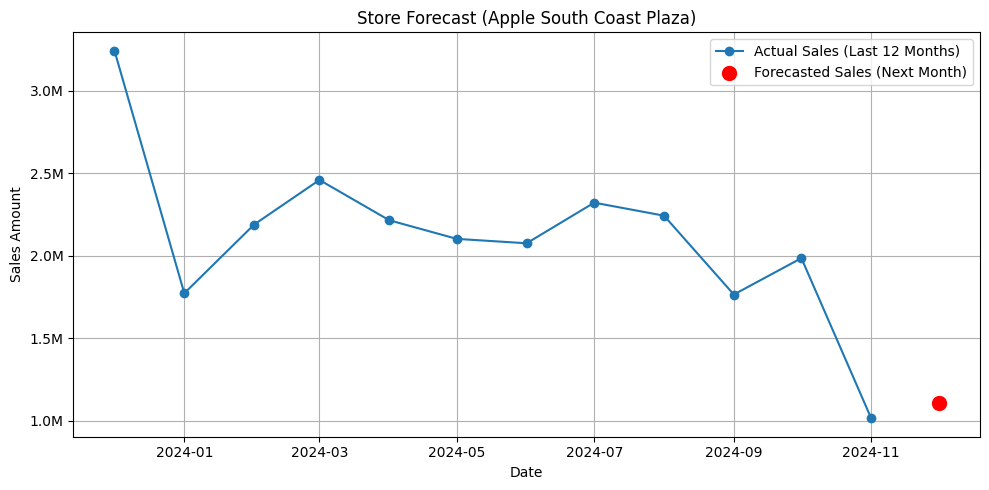

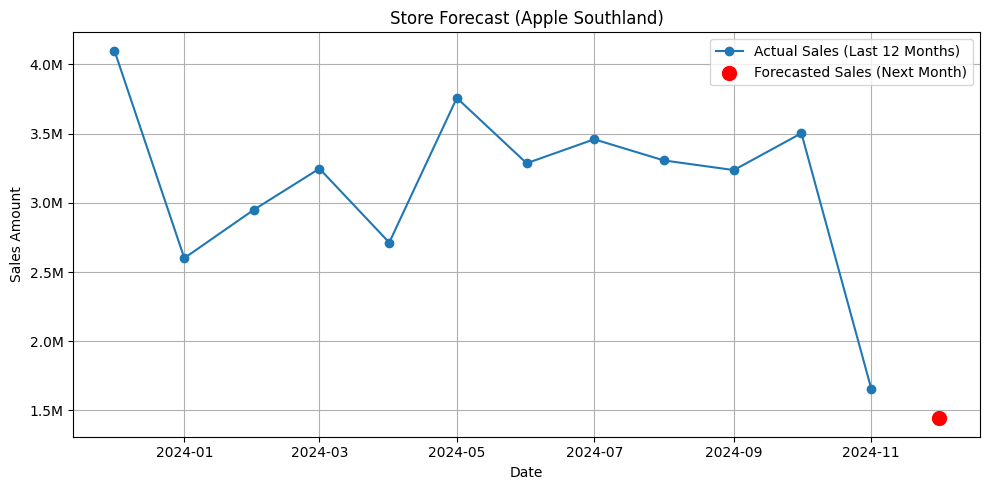

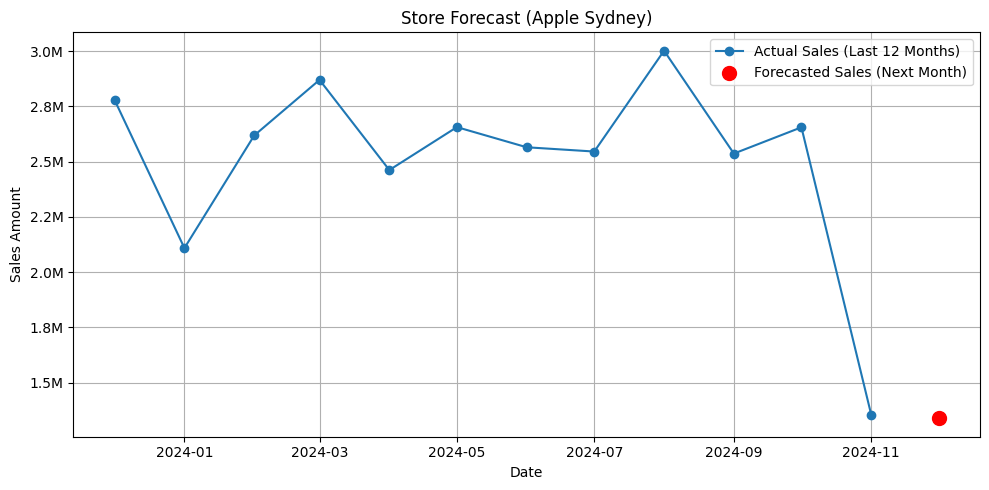

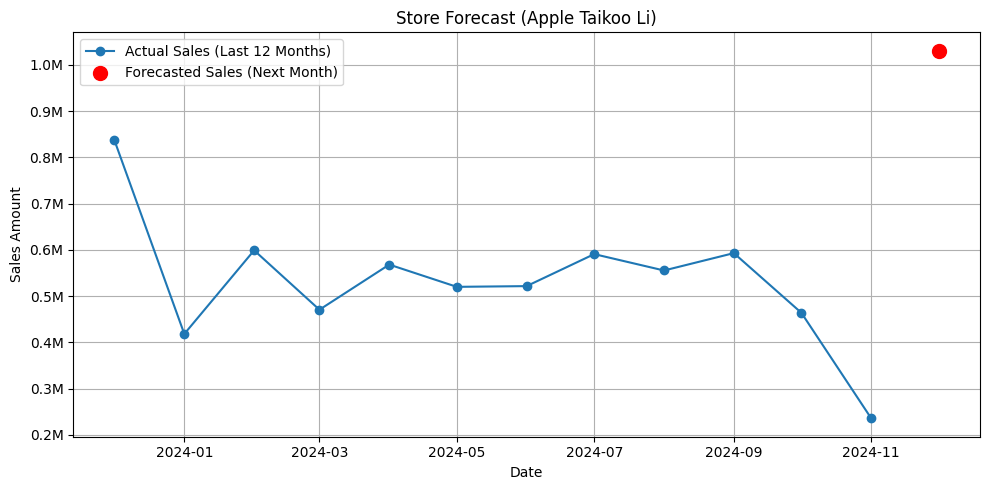

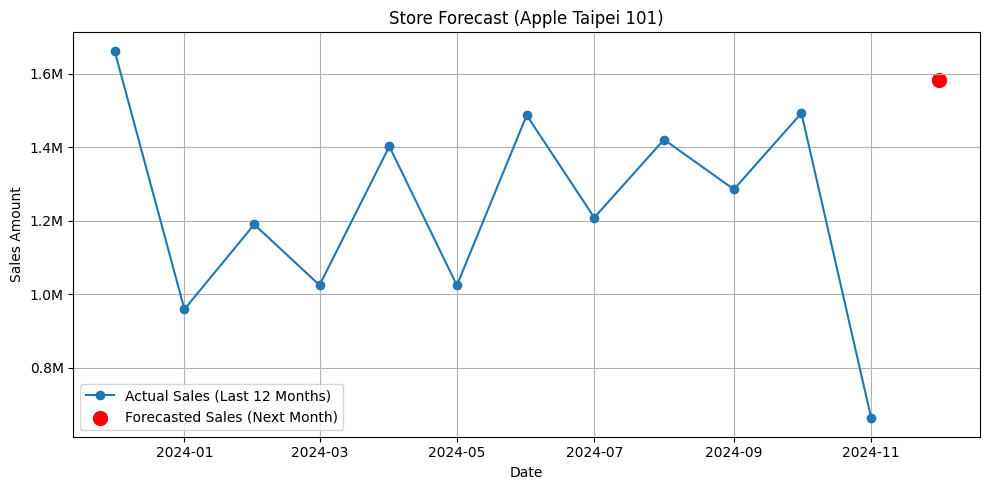

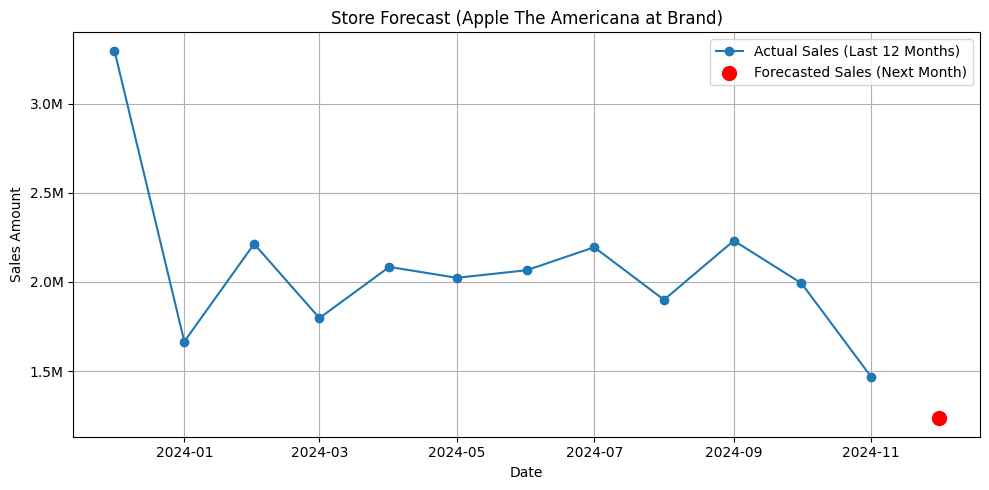

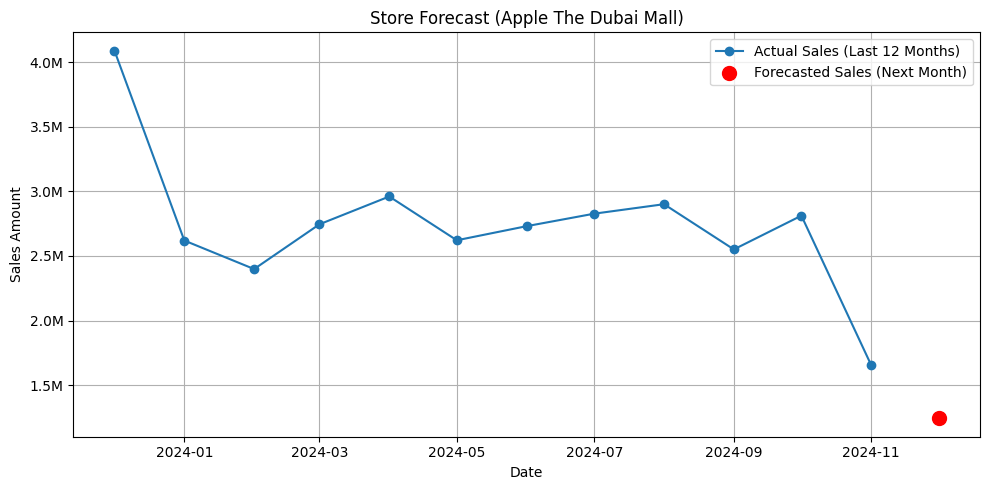

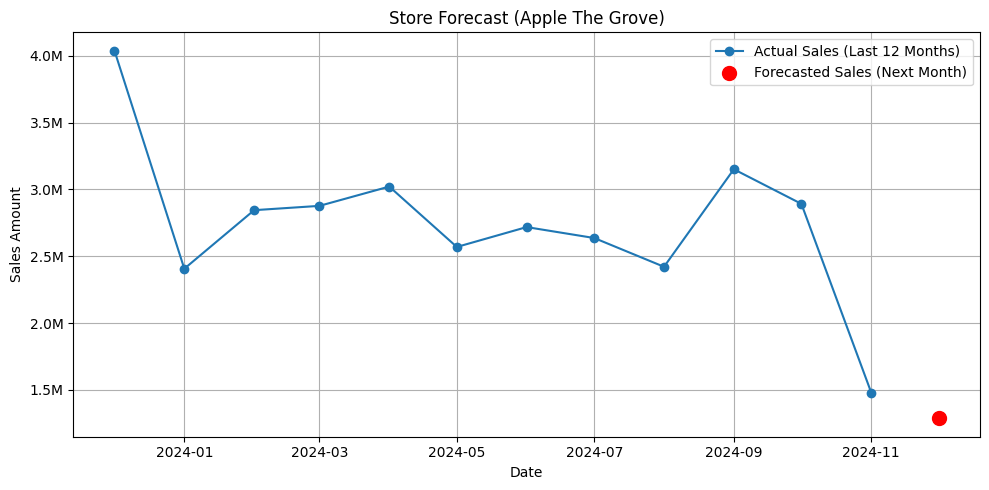

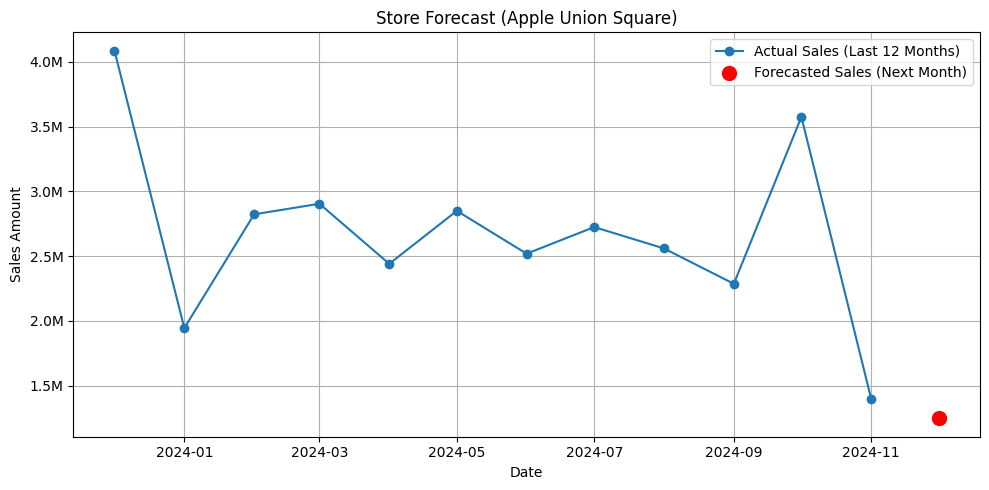

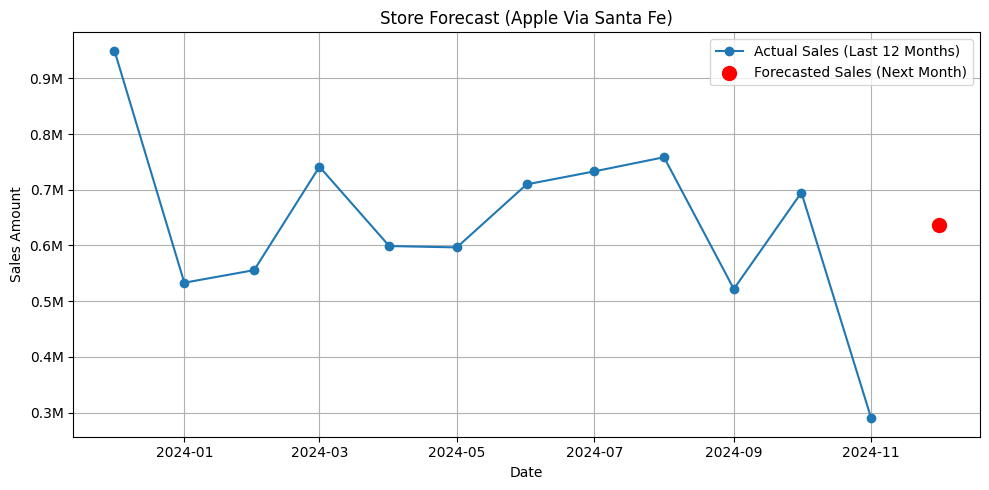

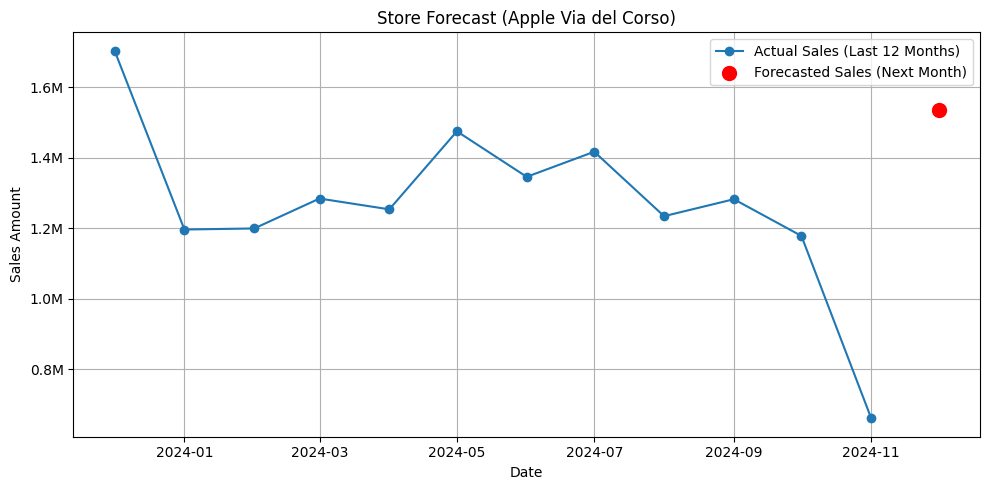

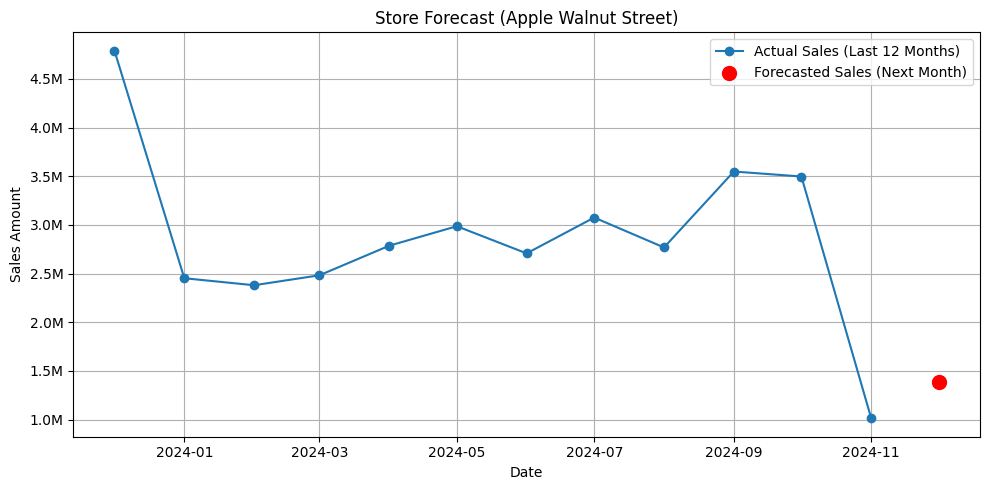

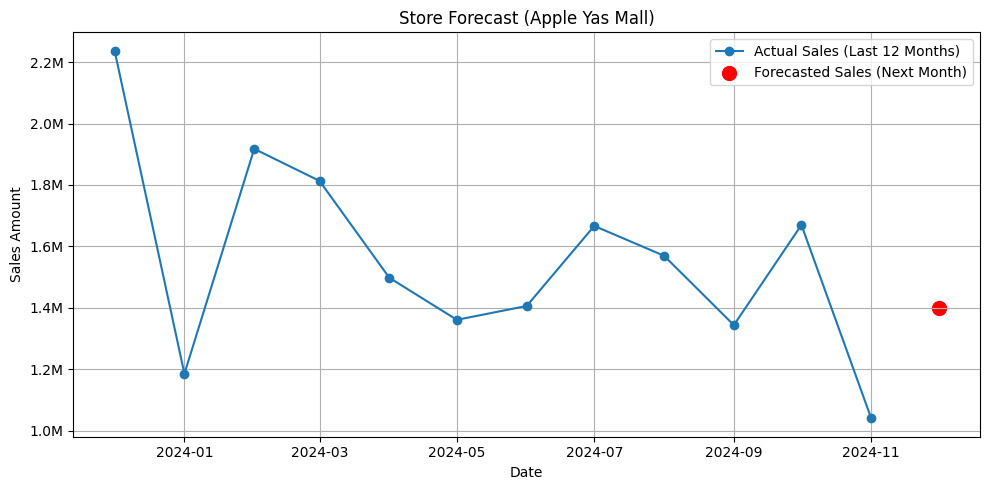

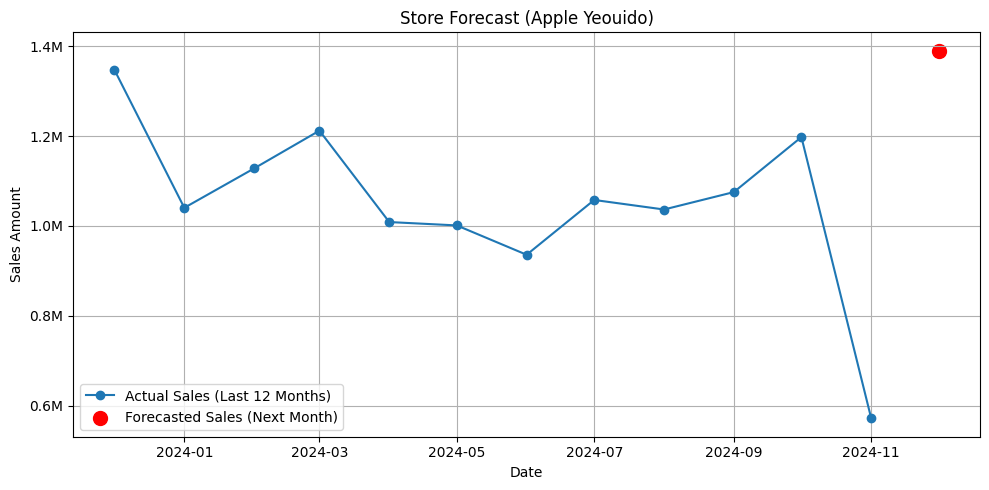

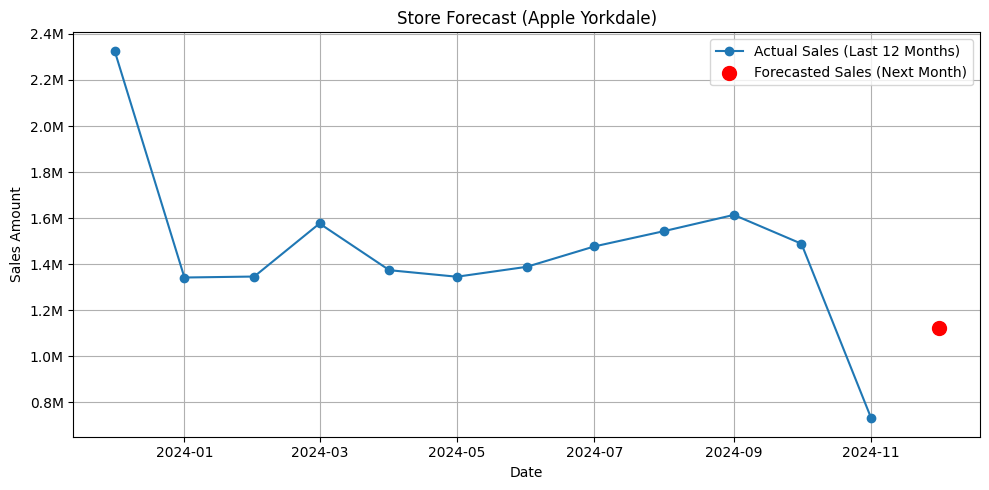

In [530]:
for store_id in forecast_df['store_id']:
    plot_store_forecast(store_id, monthly_df, forecast_df)

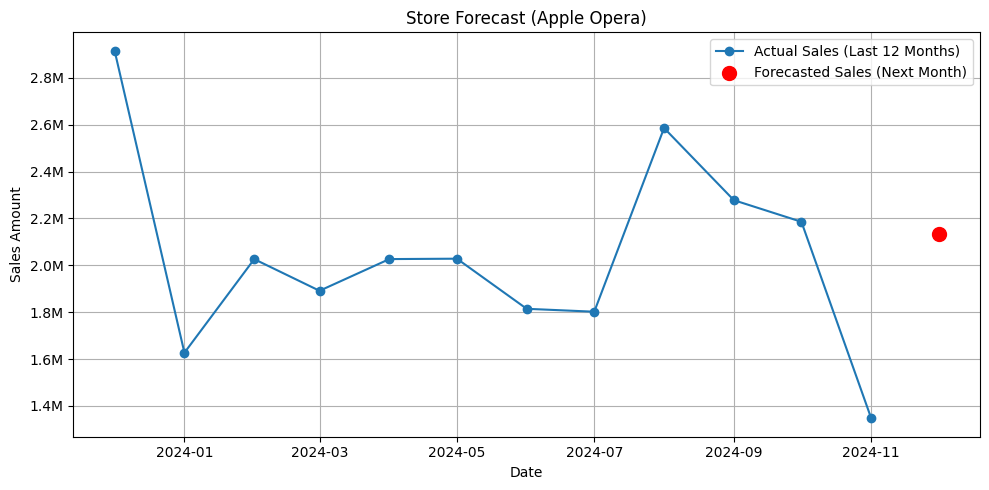

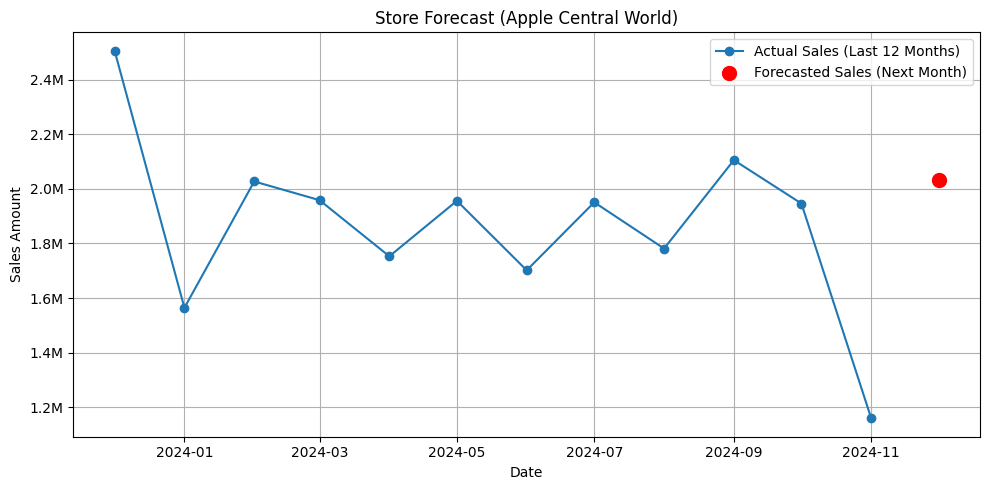

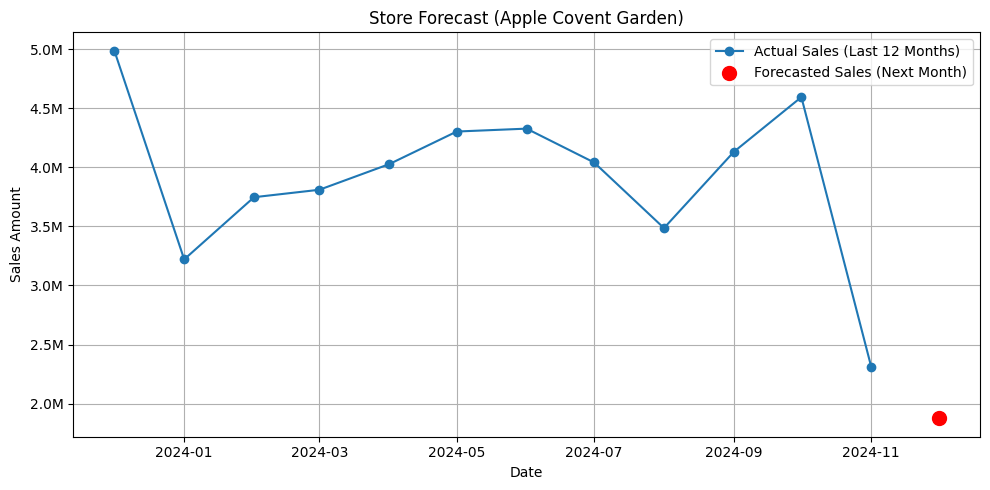

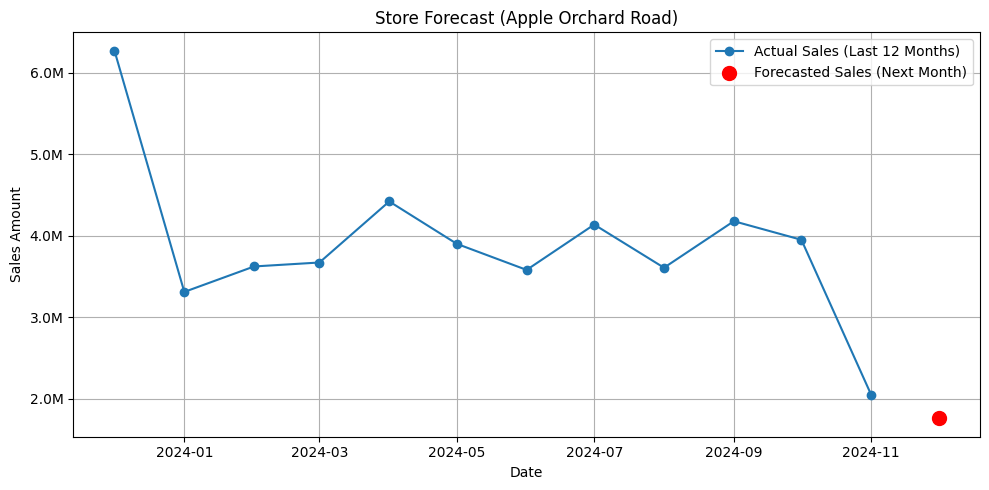

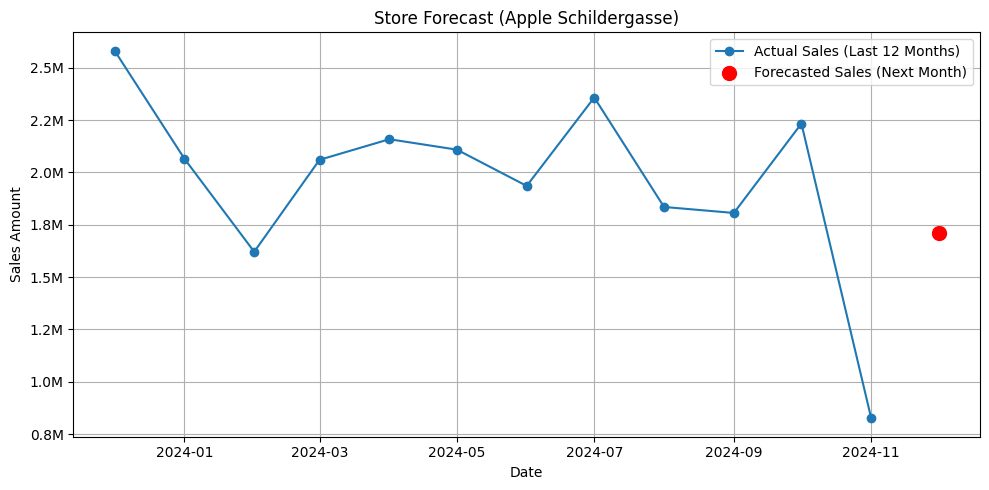

In [531]:
top_5_ids = (
    forecast_df
    .sort_values('forecasted_sales_next_month', ascending=False)
    .head(5)['store_id']
)

for store_id in top_5_ids:
    plot_store_forecast(store_id, monthly_df, forecast_df)

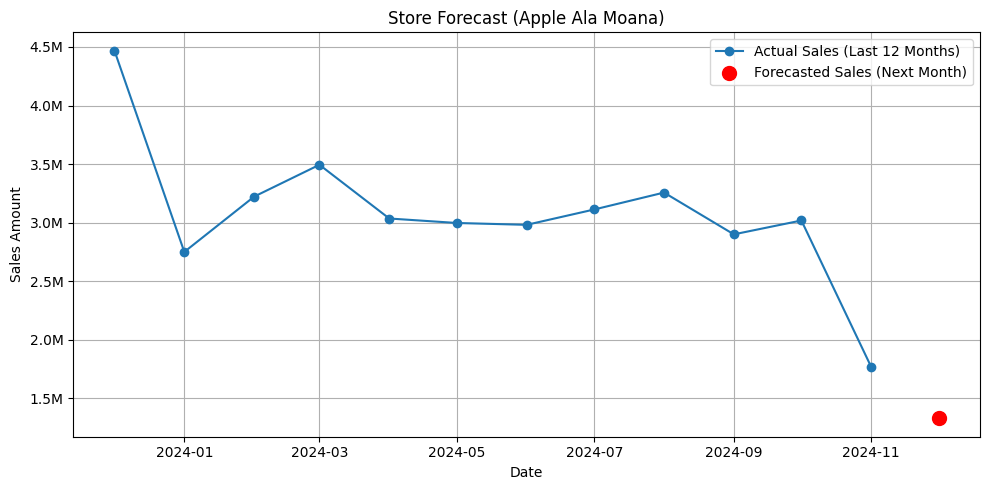

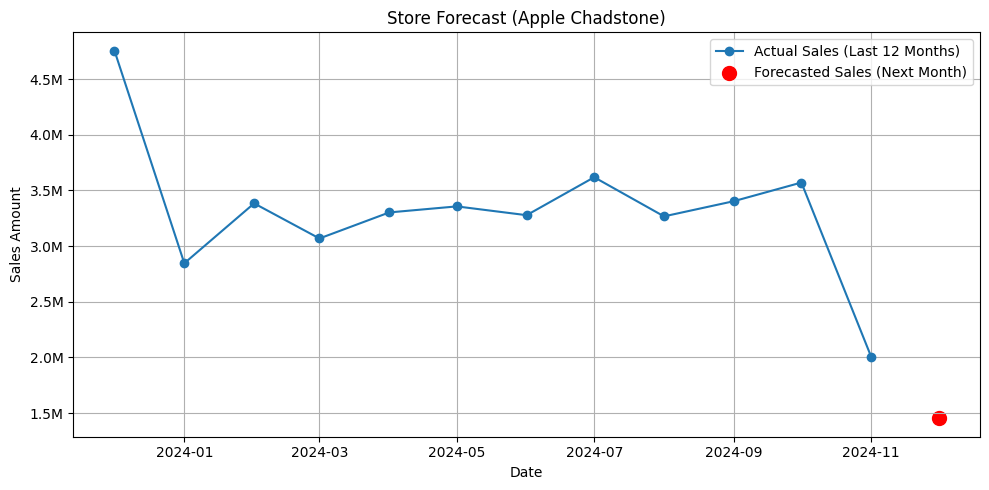

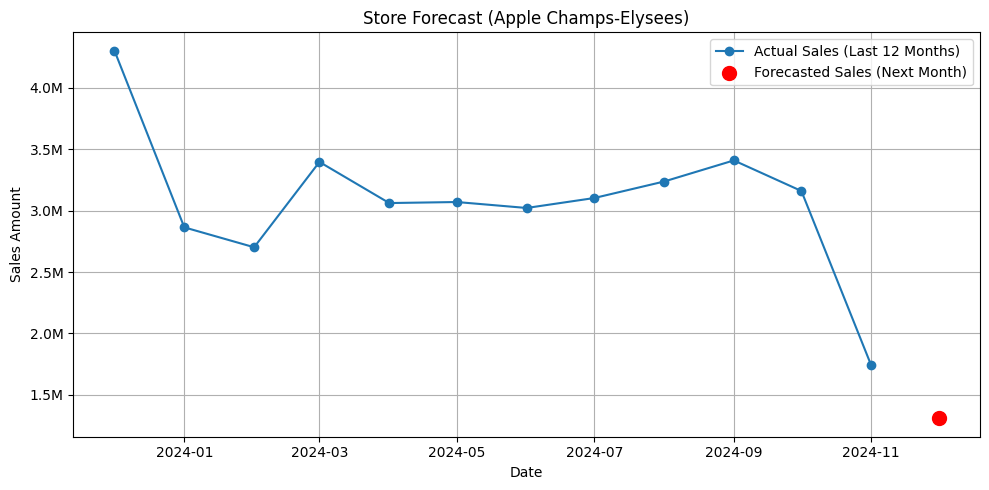

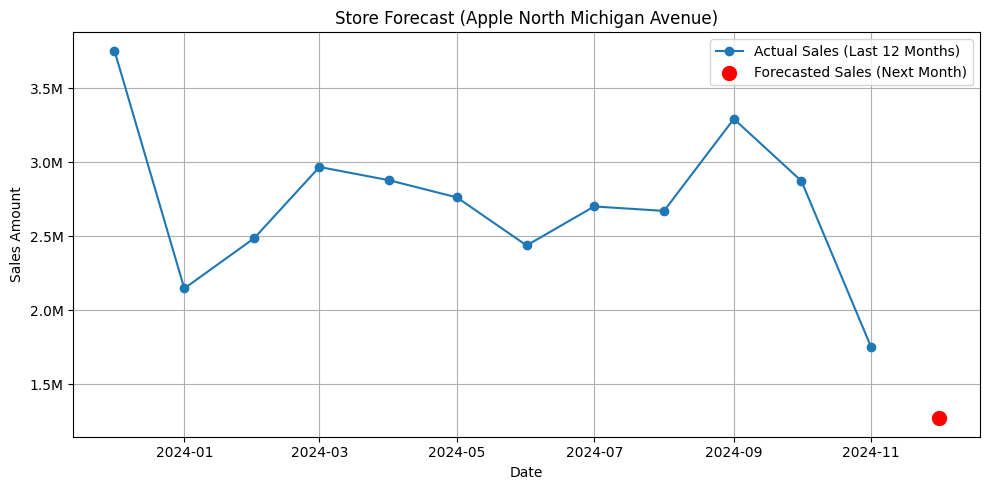

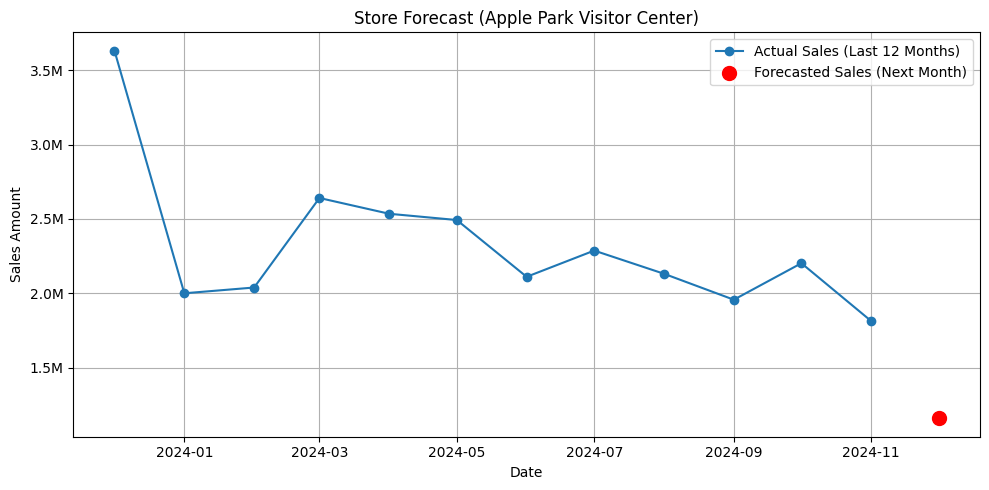

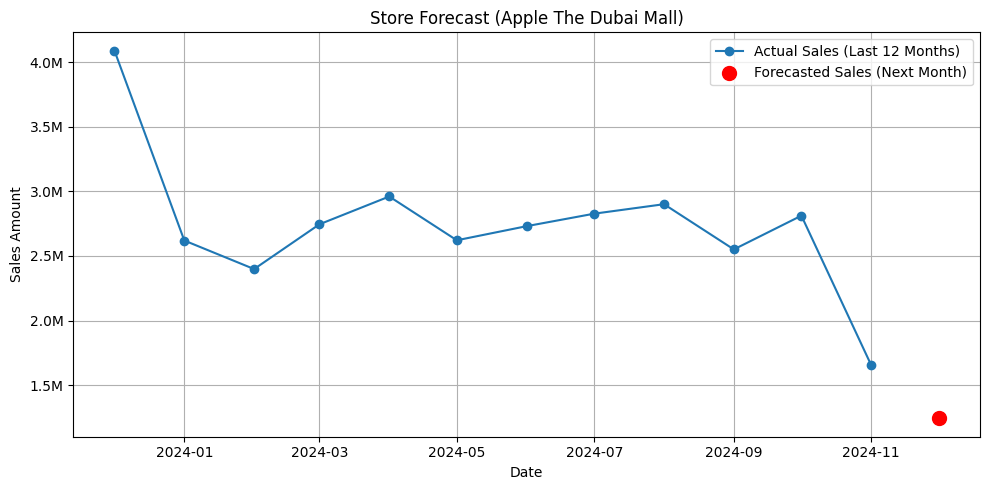

In [532]:
high_risk_ids = comparison_all_df[
    comparison_all_df['pct_change'] < -20
]['store_id']

for store_id in high_risk_ids:
    plot_store_forecast(store_id, monthly_df, forecast_df)

In [533]:
def plot_baseline_vs_lstm(store_id, comparison_df):
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker

    store_row = comparison_df[comparison_df['store_id'] == store_id].iloc[0]

    store_name = store_row['store_name']
    naive_val  = store_row['naive_forecast']
    lstm_val   = store_row['forecasted_sales_next_month']

    plt.figure(figsize=(5,4))

    plt.bar(
        ['Naive Baseline', 'LSTM Forecast'],
        [naive_val, lstm_val],
        color=['gray', 'steelblue']
    )

    plt.title(f"Baseline vs LSTM\n{store_name}")
    plt.ylabel("Sales Amount")

    # تنسيق بالمليون
    plt.gca().yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
    )

    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

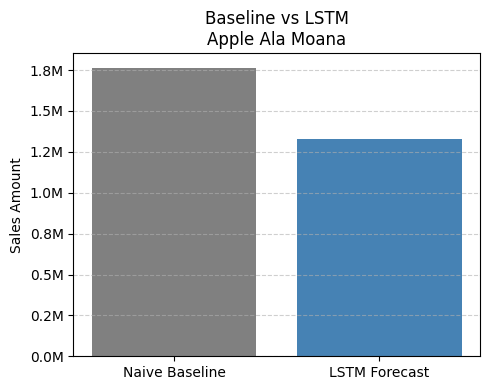

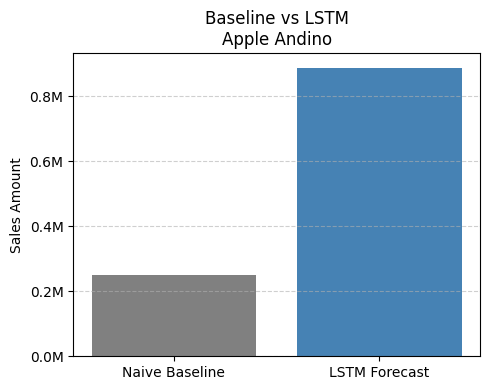

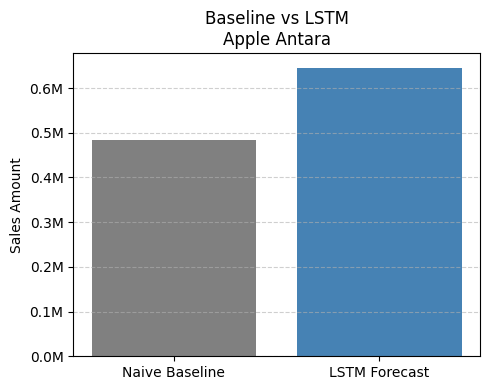

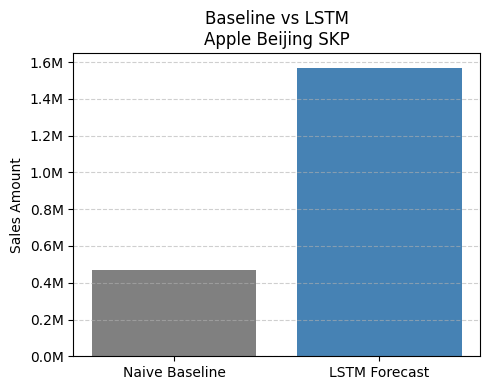

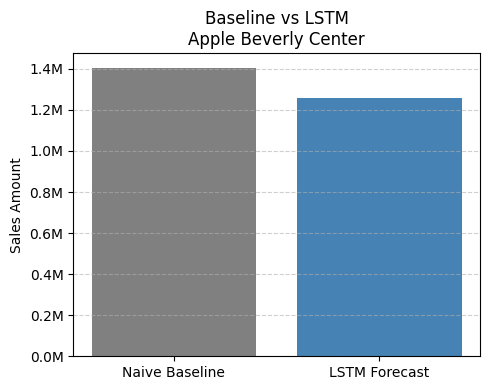

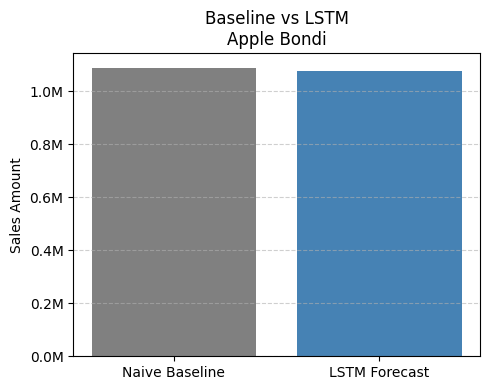

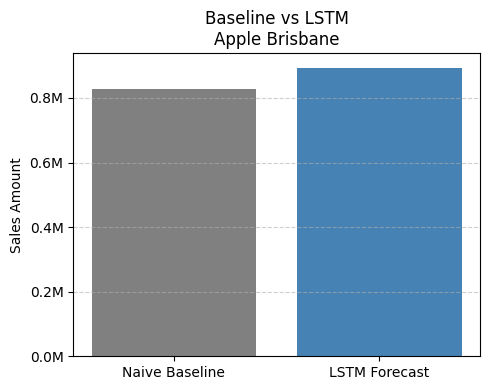

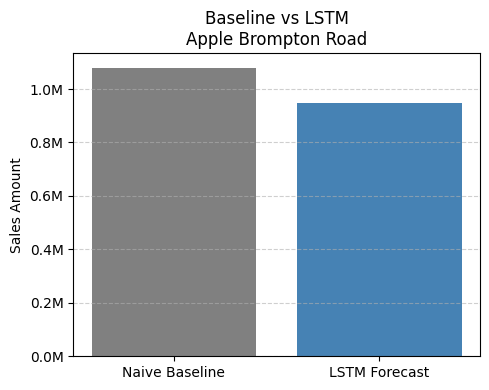

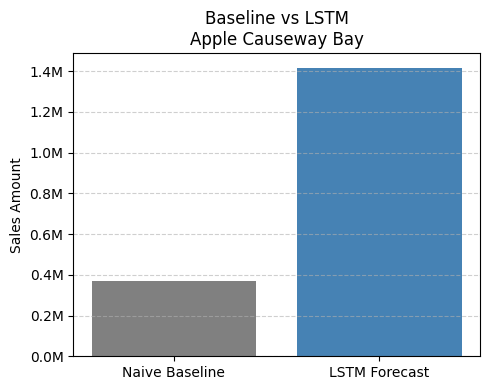

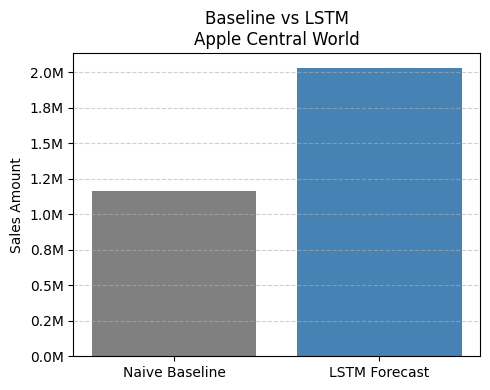

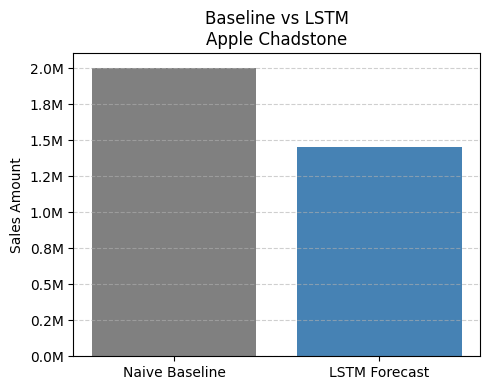

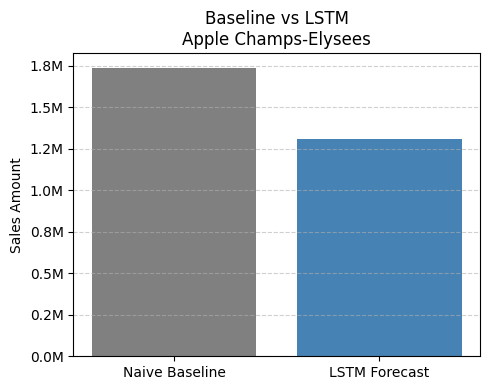

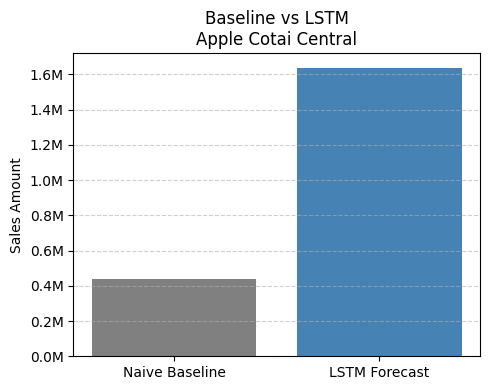

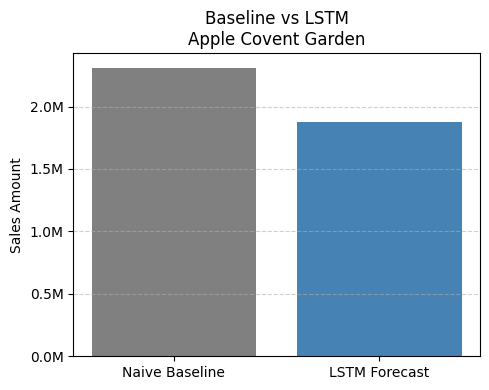

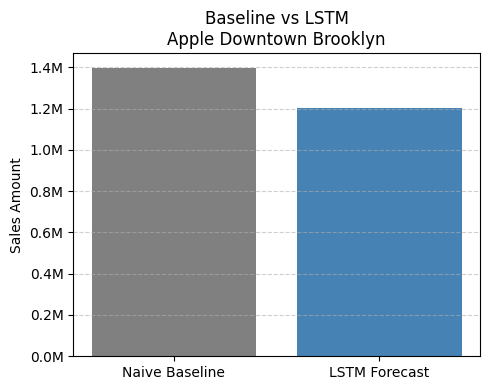

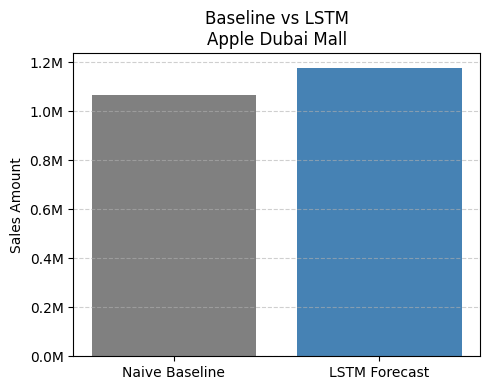

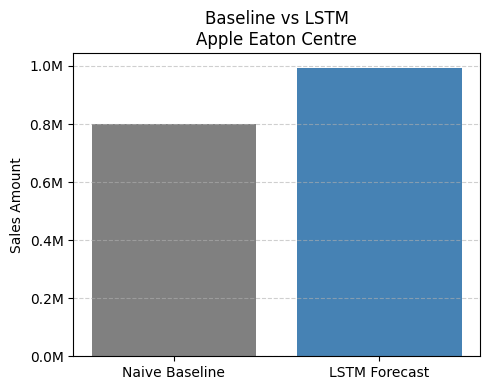

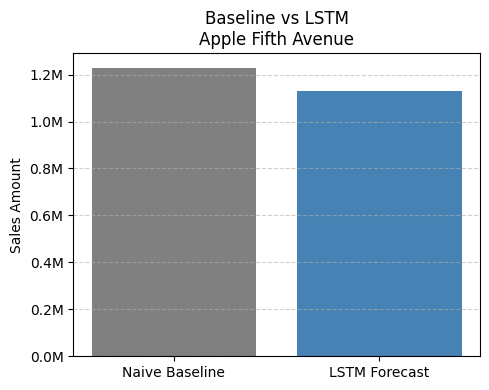

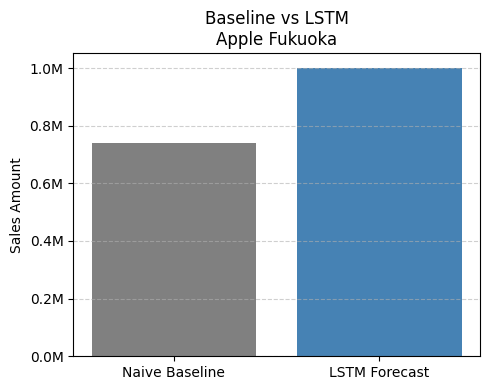

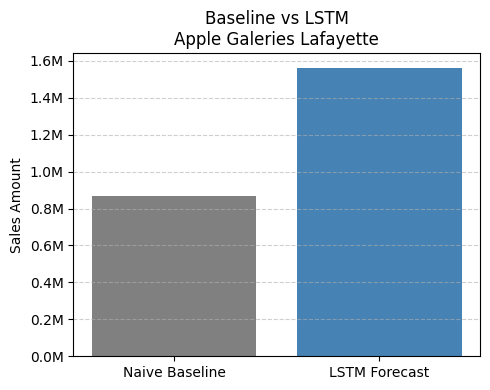

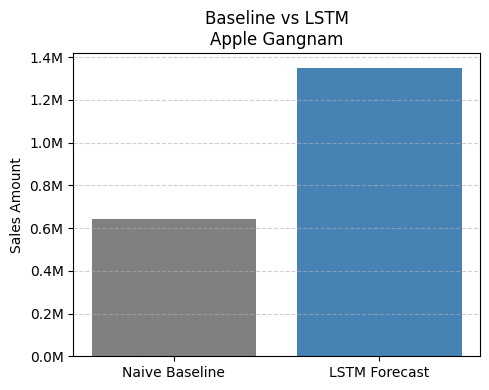

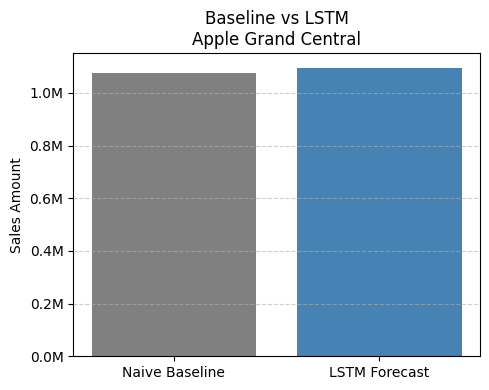

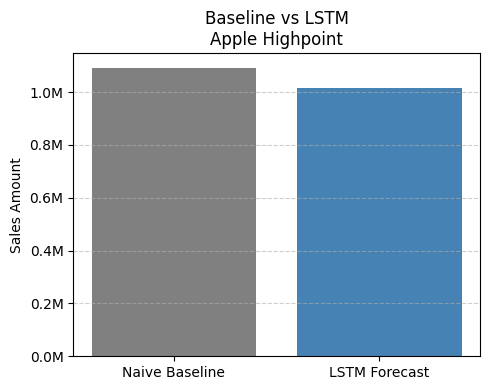

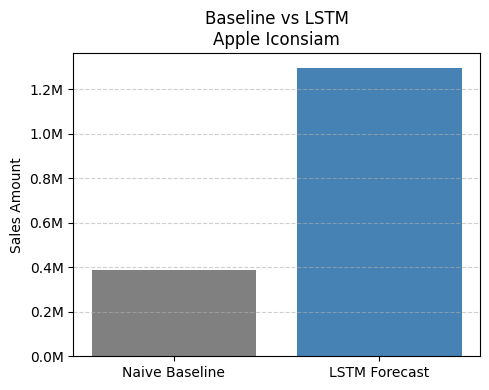

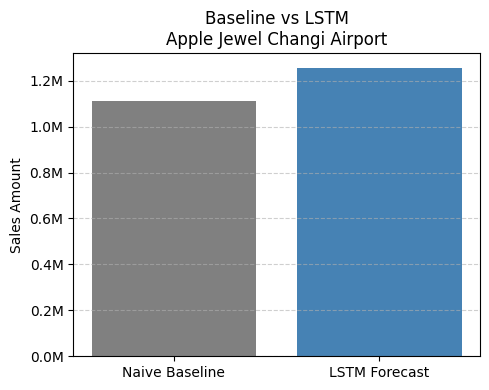

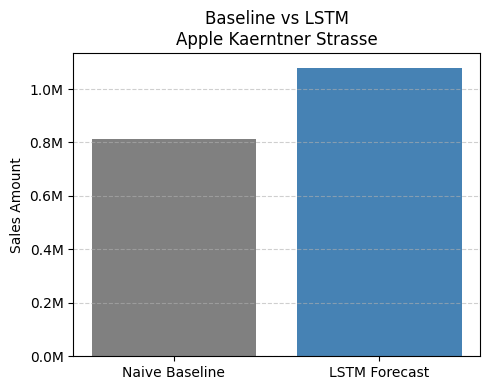

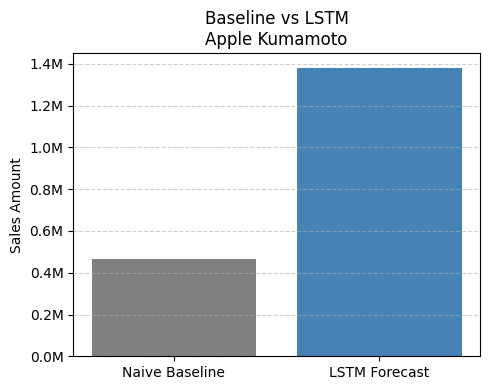

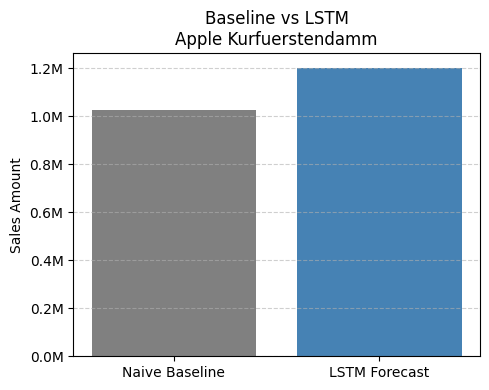

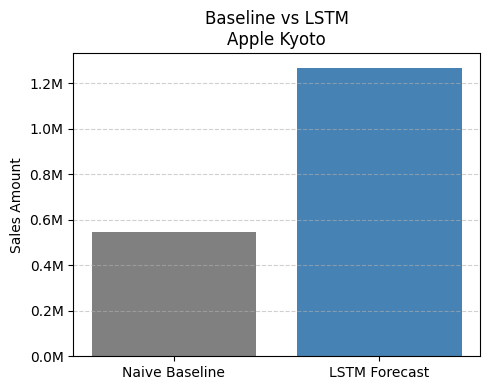

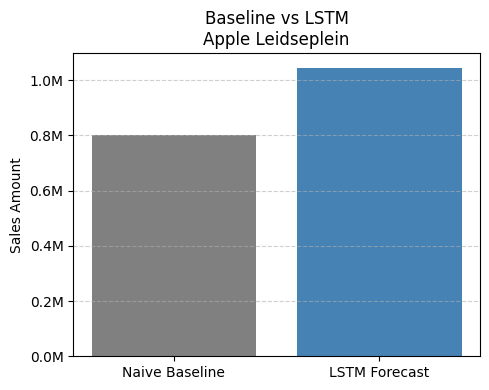

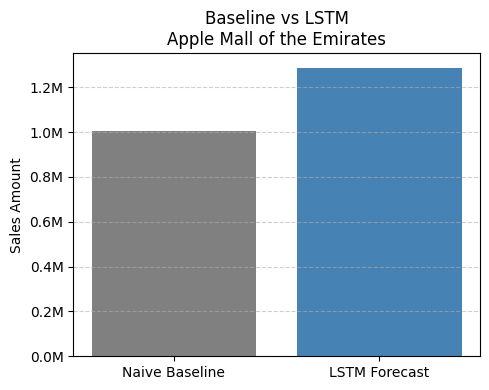

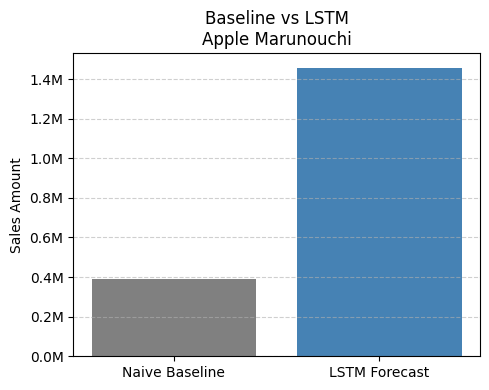

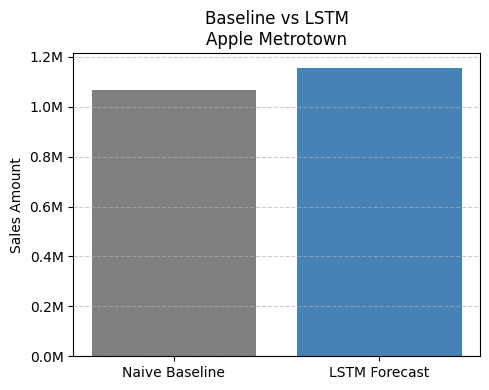

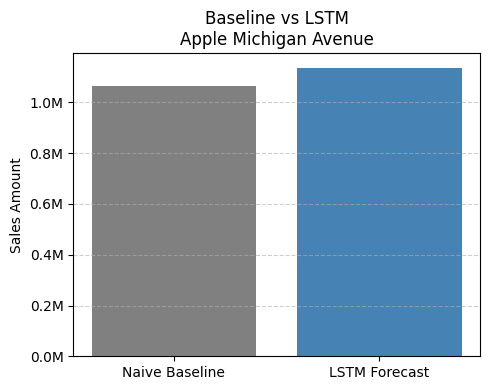

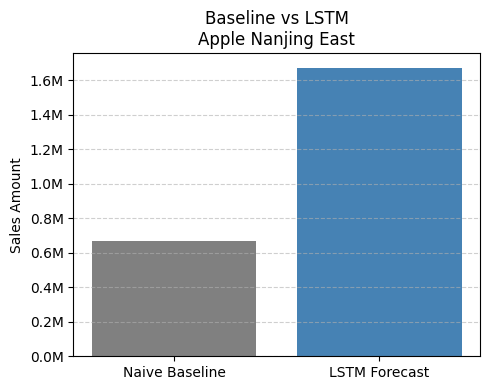

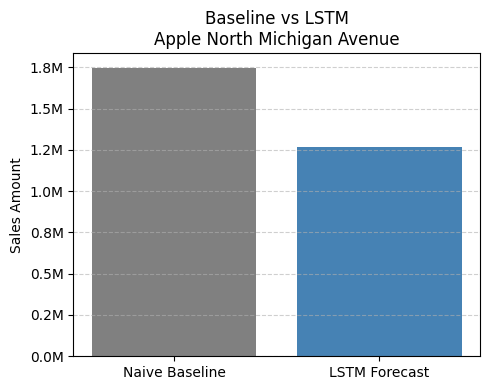

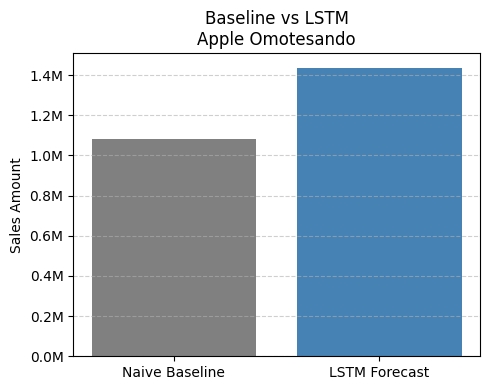

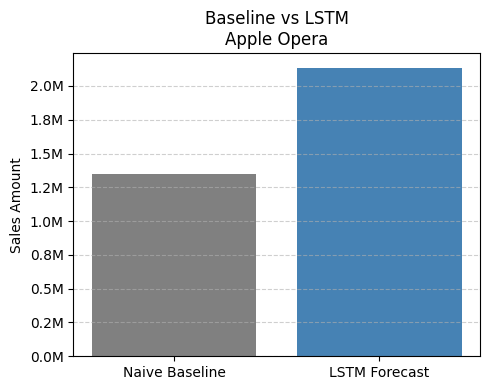

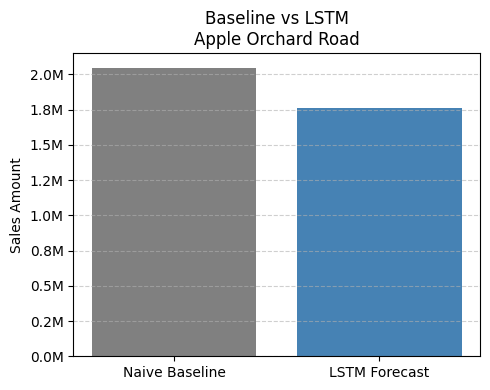

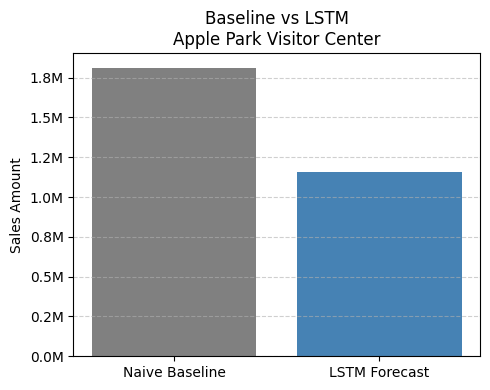

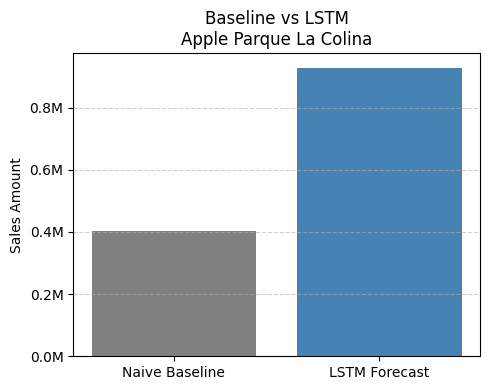

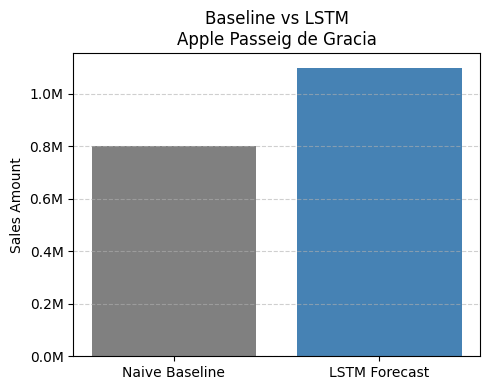

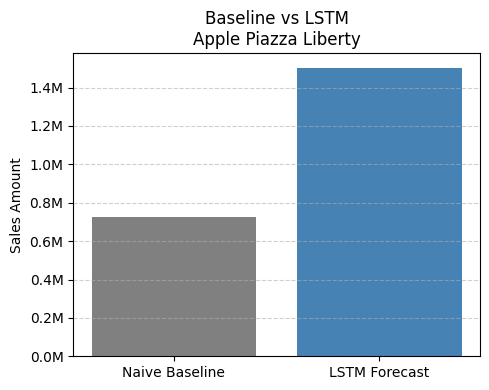

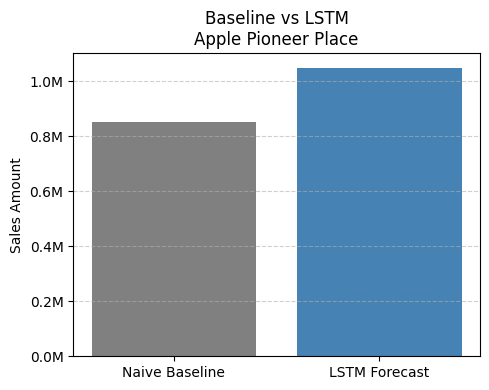

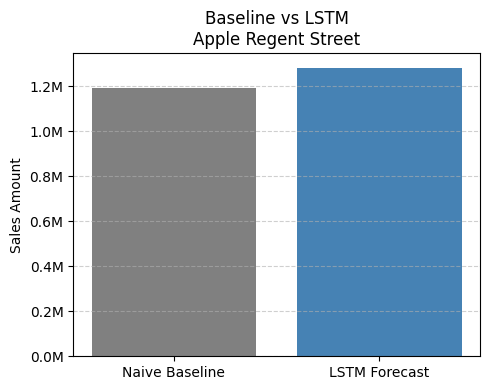

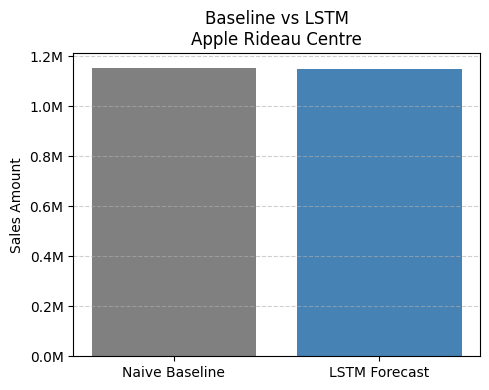

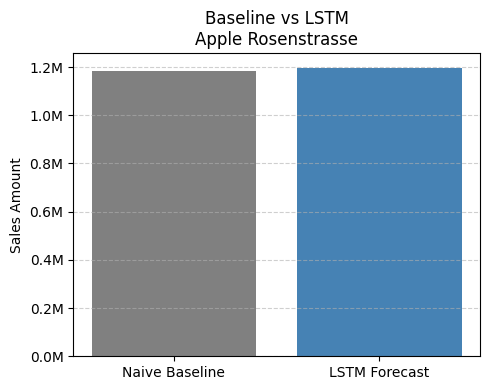

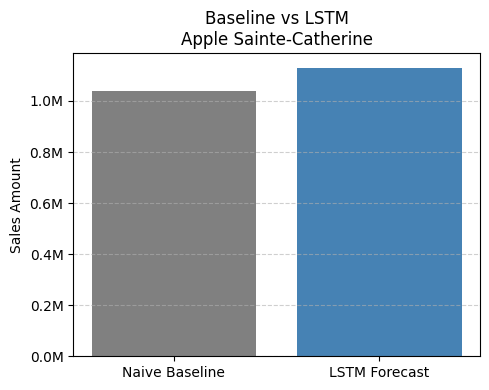

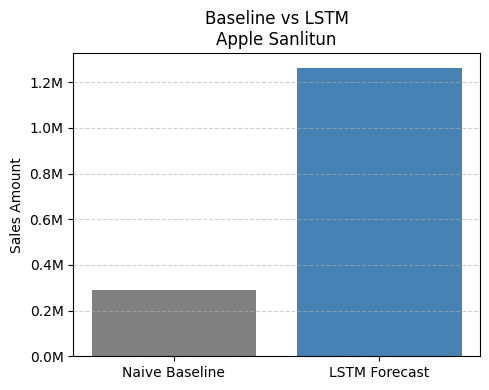

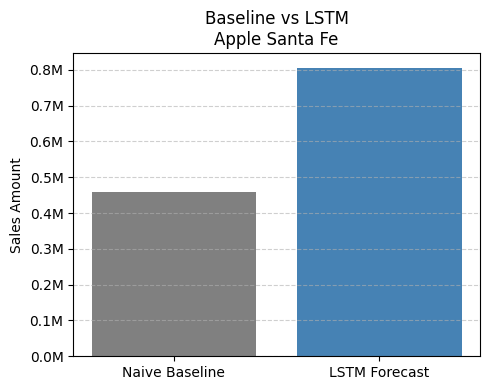

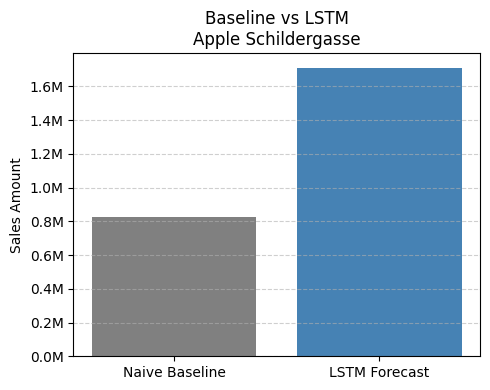

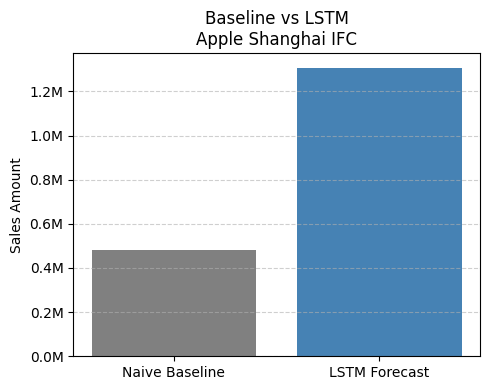

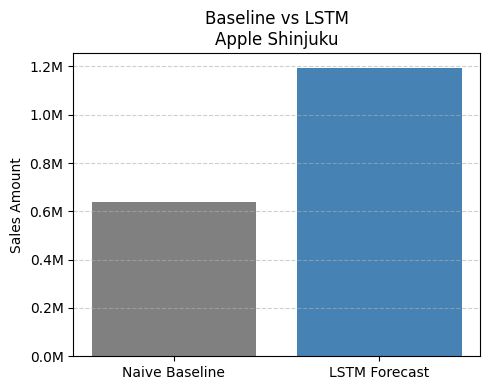

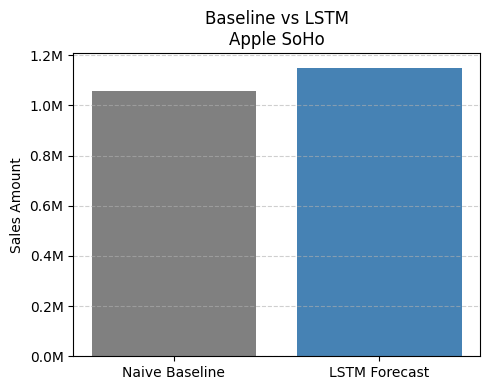

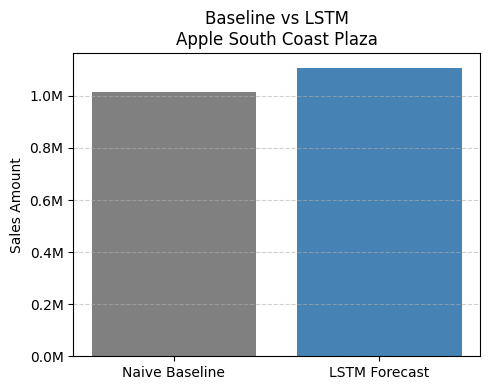

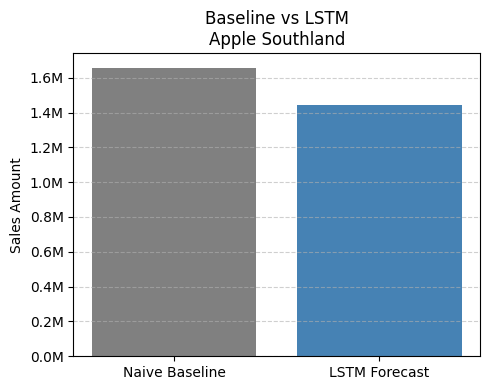

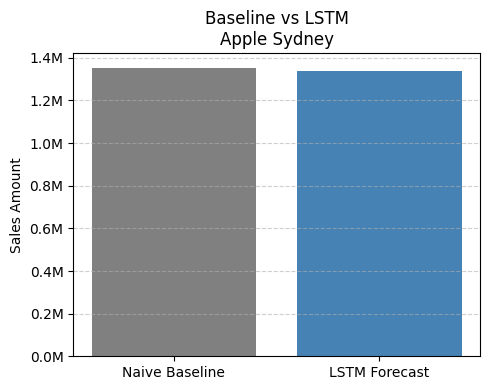

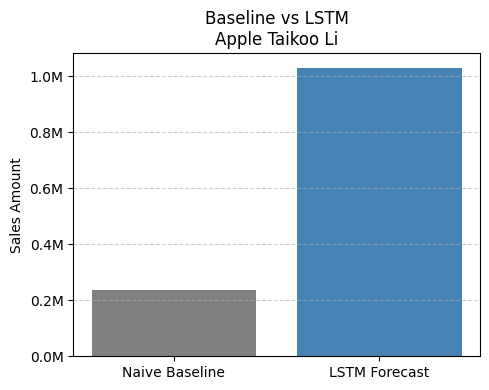

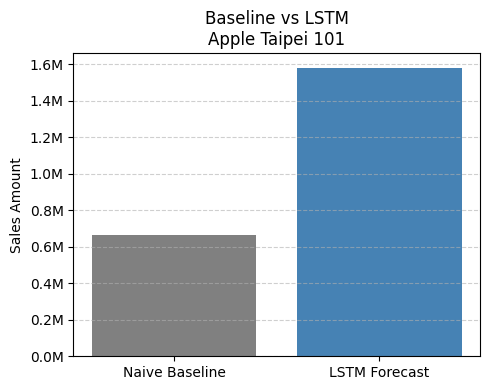

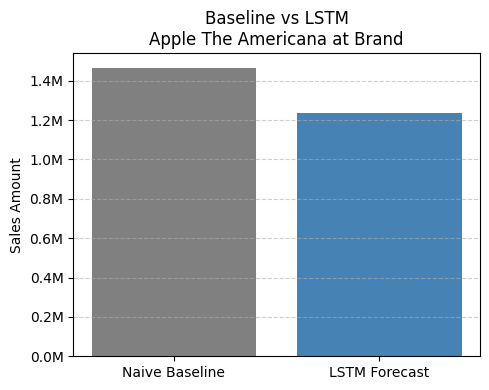

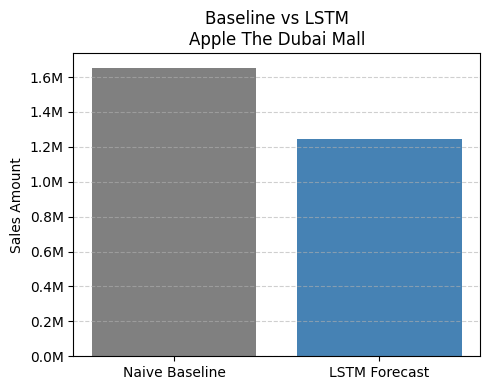

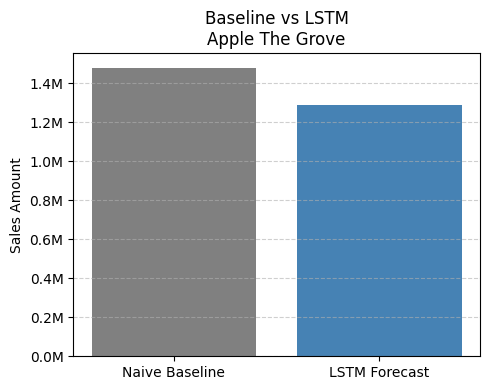

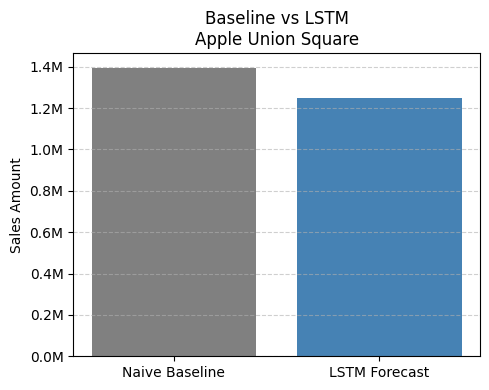

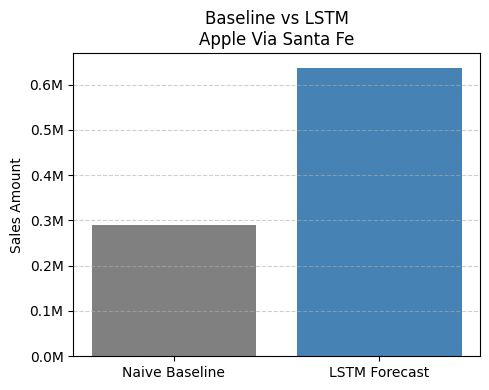

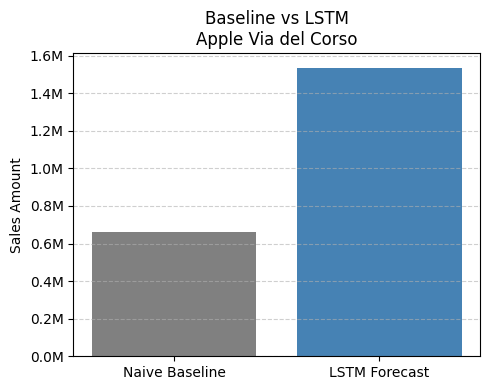

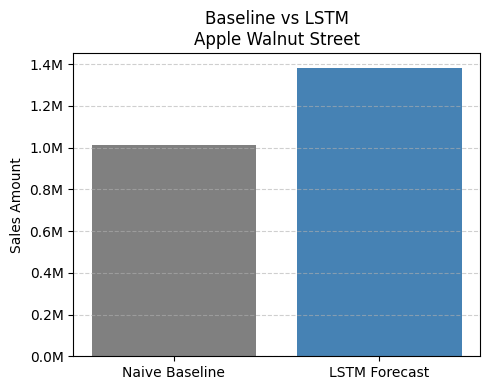

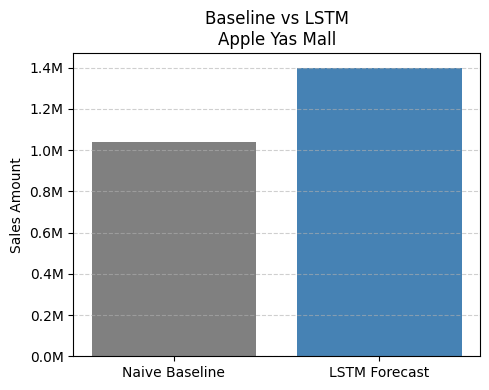

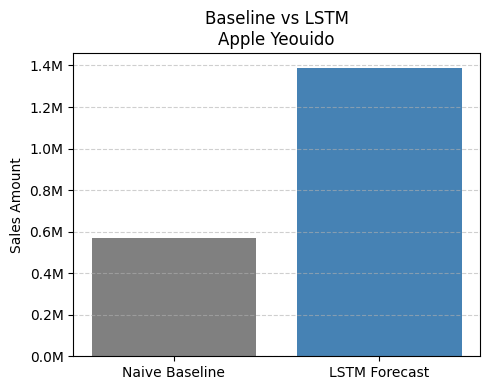

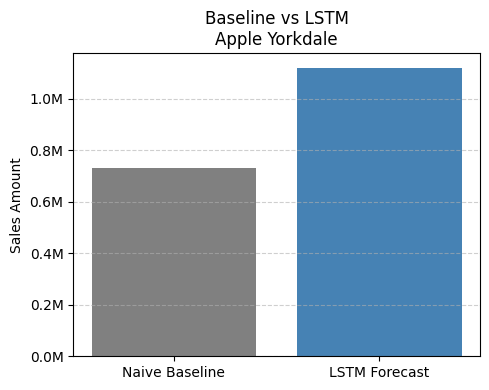

In [534]:
for store_id in comparison_all_df['store_id']:
    plot_baseline_vs_lstm(store_id, comparison_all_df)

🎯 الهدف

لكل Store نعرض:

Naive Baseline (آخر شهر فعلي)

LSTM Forecast (الشهر القادم)

في Graph واحد واضح.

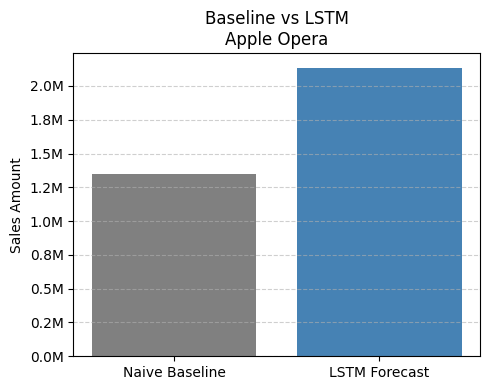

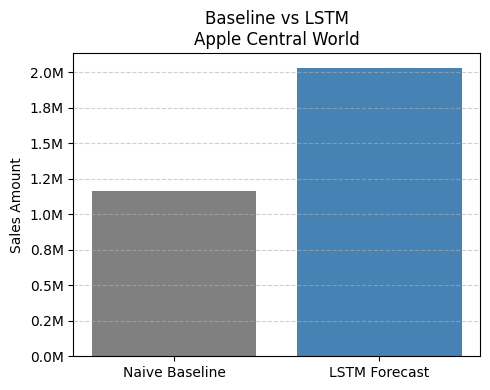

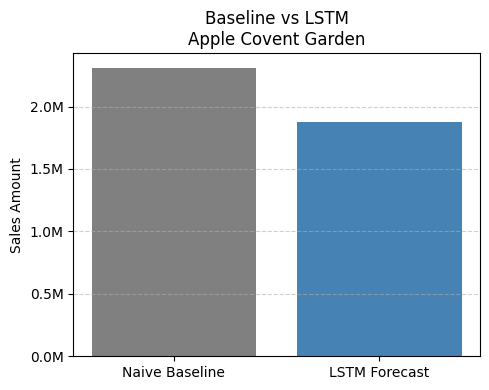

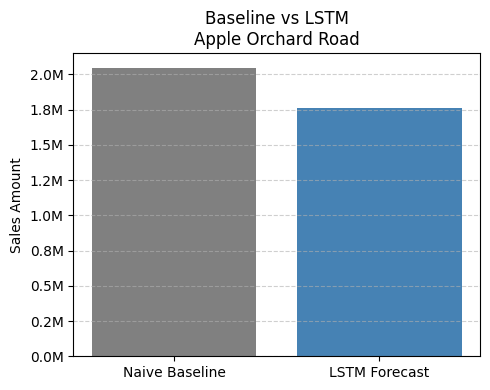

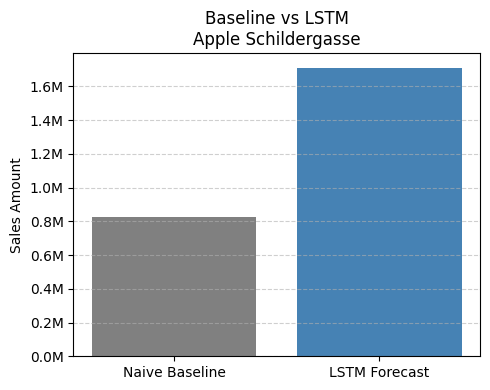

In [535]:
top_5_ids = (
    comparison_all_df
    .sort_values('forecasted_sales_next_month', ascending=False)
    .head(5)['store_id']
)

for store_id in top_5_ids:
    plot_baseline_vs_lstm(store_id, comparison_all_df)

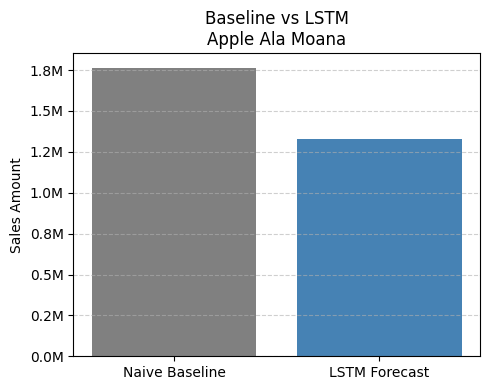

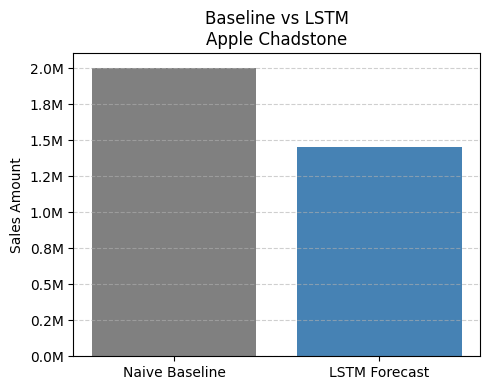

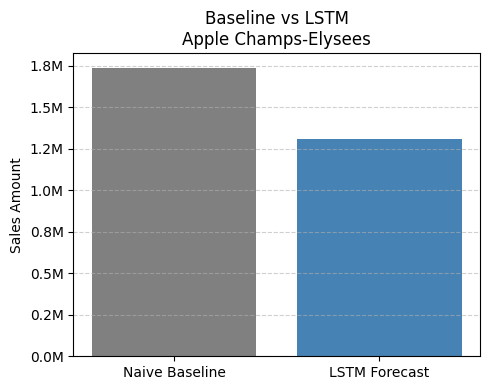

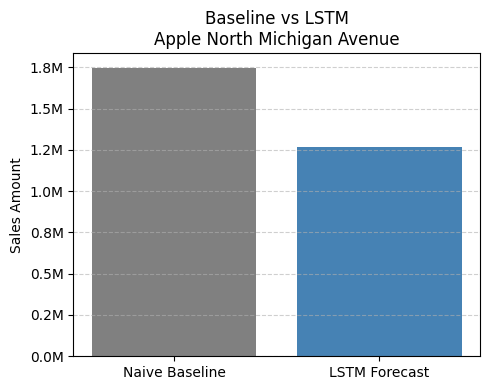

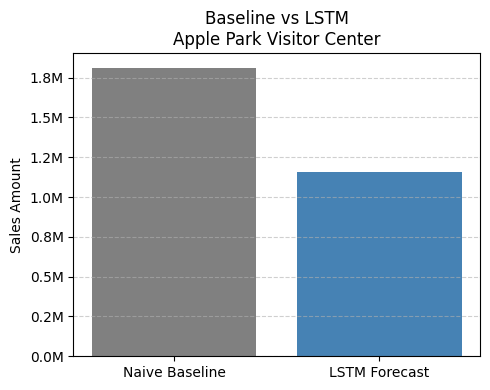

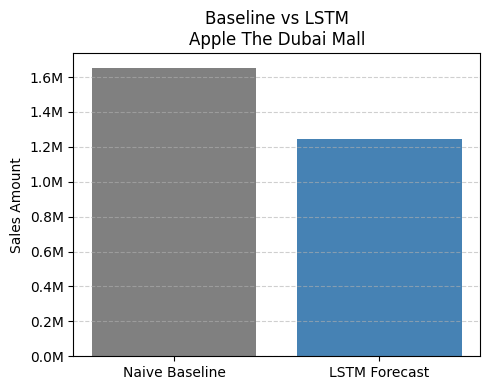

In [536]:
high_risk_ids = comparison_all_df[
    comparison_all_df['pct_change'] < -20
]['store_id']

for store_id in high_risk_ids:
    plot_baseline_vs_lstm(store_id, comparison_all_df)

🧠 إزاي تفسّر Graph واحد؟

لو LSTM < Naive:

الموديل شايف هبوط

لو LSTM ≈ Naive:

استقرار

لو LSTM > Naive:

نمو متوقّع
“Baseline and LSTM forecasts were compared at the store level to assess whether predictions relied solely on recent observations or incorporated broader temporal patterns.”

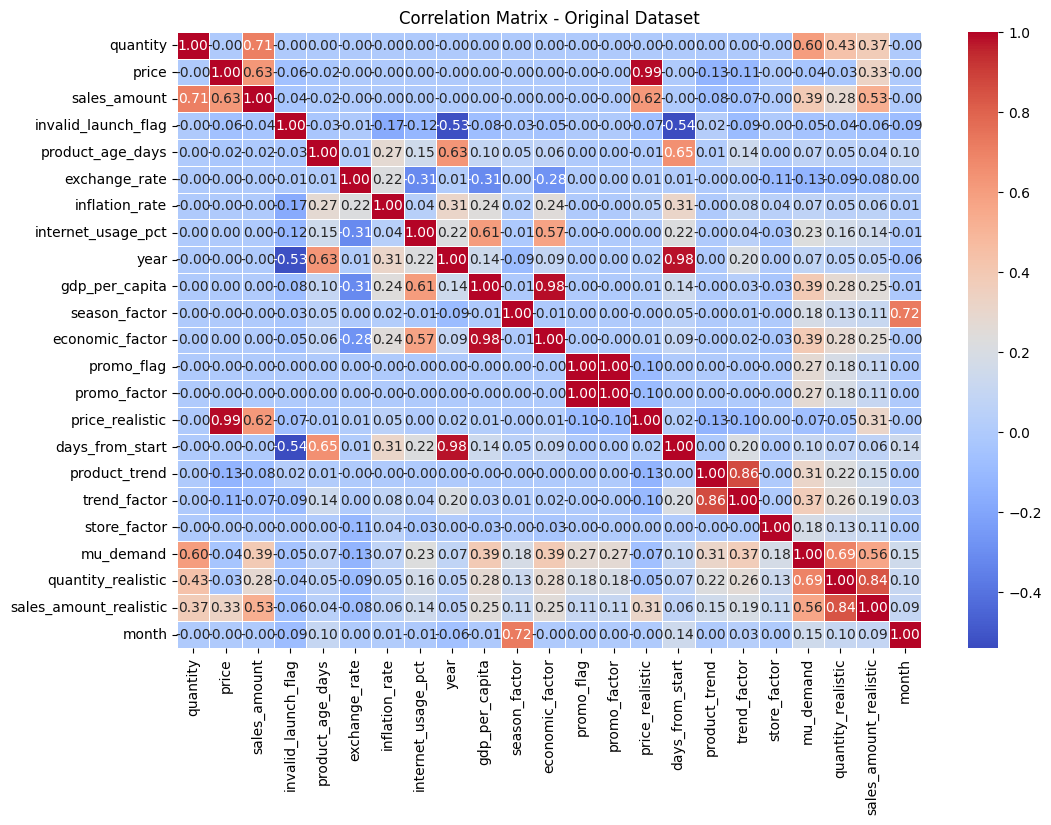

In [537]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix - Original Dataset")
plt.show()

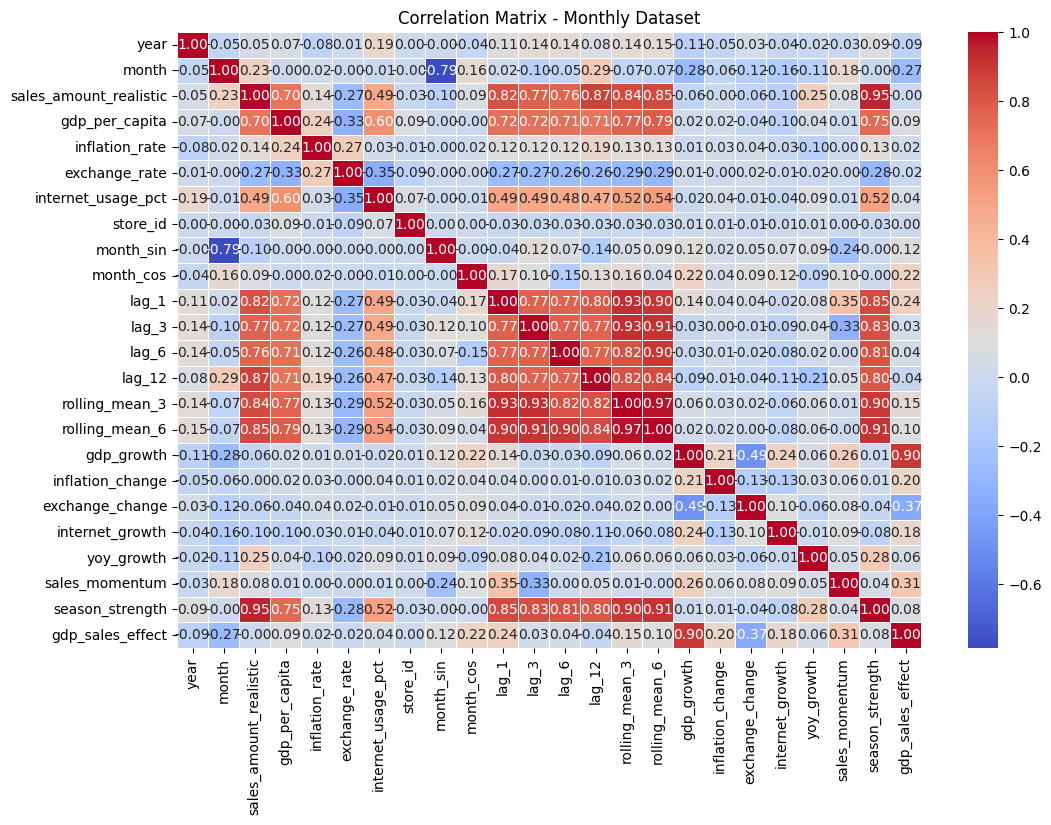

In [538]:
plt.figure(figsize=(12,8))

corr_monthly = monthly_df.corr(numeric_only=True)

sns.heatmap(
    corr_monthly,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix - Monthly Dataset")
plt.show()

In [539]:
corr_target = monthly_df.corr(numeric_only=True)["sales_amount_realistic"].sort_values(ascending=False)

print(corr_target)

sales_amount_realistic    1.00
season_strength           0.95
lag_12                    0.87
rolling_mean_6            0.85
rolling_mean_3            0.84
lag_1                     0.82
lag_3                     0.77
lag_6                     0.76
gdp_per_capita            0.70
internet_usage_pct        0.49
yoy_growth                0.25
month                     0.23
inflation_rate            0.14
month_cos                 0.09
sales_momentum            0.08
year                      0.05
inflation_change         -0.00
gdp_sales_effect         -0.00
store_id                 -0.03
exchange_change          -0.06
gdp_growth               -0.06
internet_growth          -0.10
month_sin                -0.10
exchange_rate            -0.27
Name: sales_amount_realistic, dtype: float64


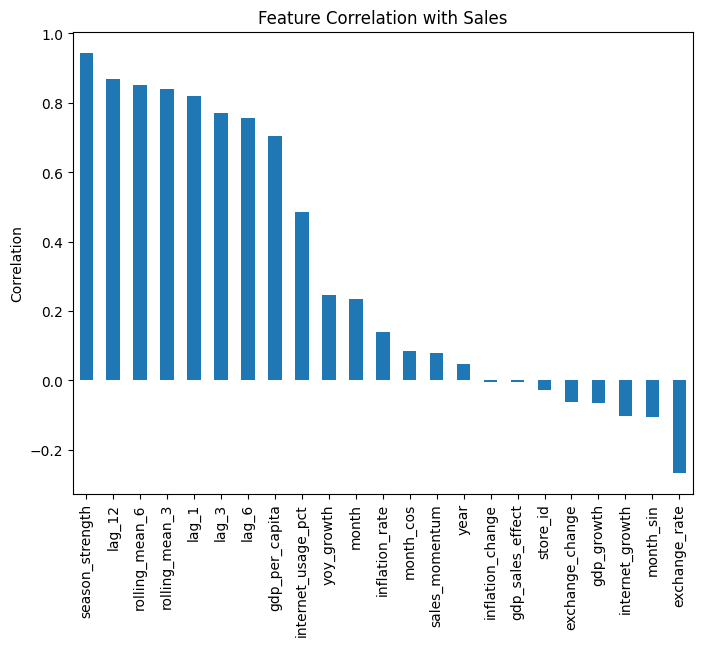

In [540]:
plt.figure(figsize=(8,6))

corr_target.drop("sales_amount_realistic").plot(kind="bar")

plt.title("Feature Correlation with Sales")
plt.ylabel("Correlation")
plt.show()

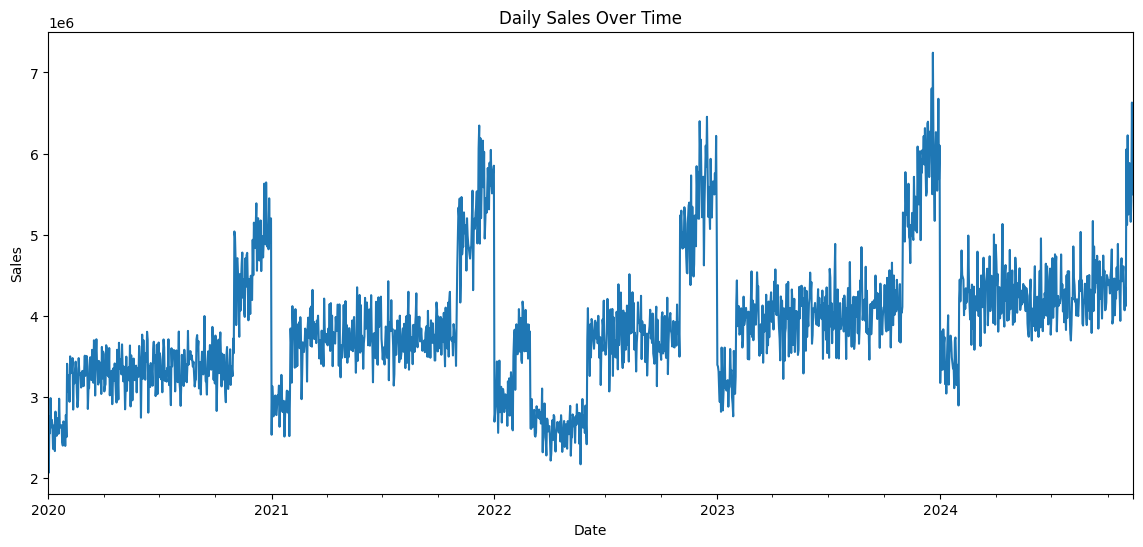

In [541]:
plt.figure(figsize=(14,6))

df.groupby("sale_date")["sales_amount_realistic"].sum().plot()

plt.title("Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

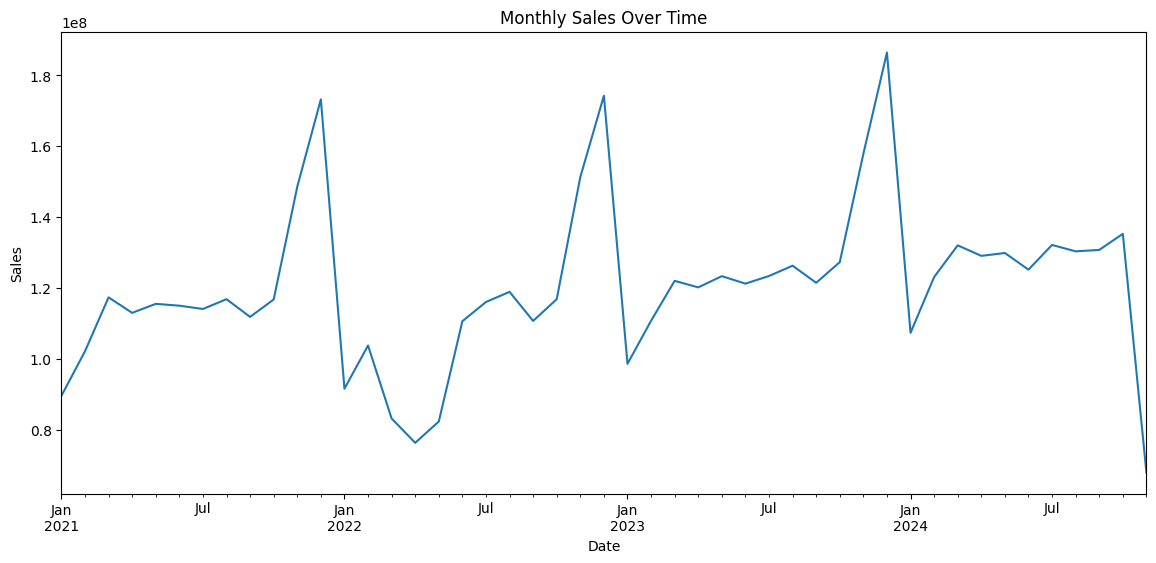

In [542]:
plt.figure(figsize=(14,6))

monthly_df.groupby("date")["sales_amount_realistic"].sum().plot()

plt.title("Monthly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

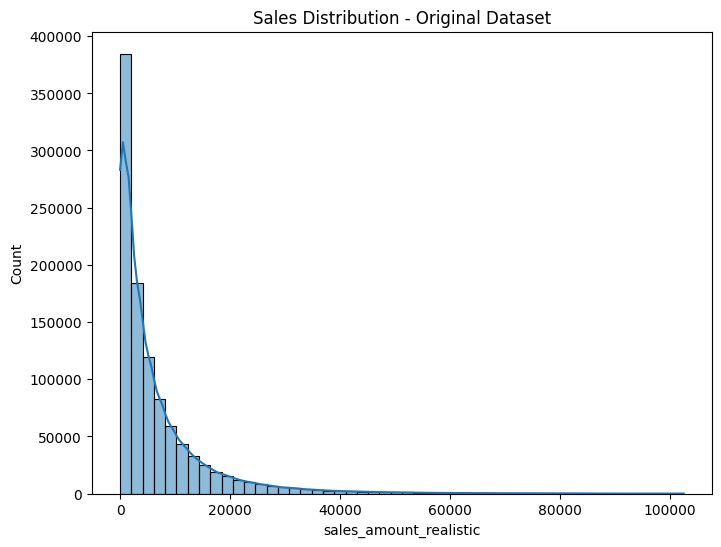

In [543]:
plt.figure(figsize=(8,6))

sns.histplot(df["sales_amount_realistic"], bins=50, kde=True)

plt.title("Sales Distribution - Original Dataset")
plt.show()

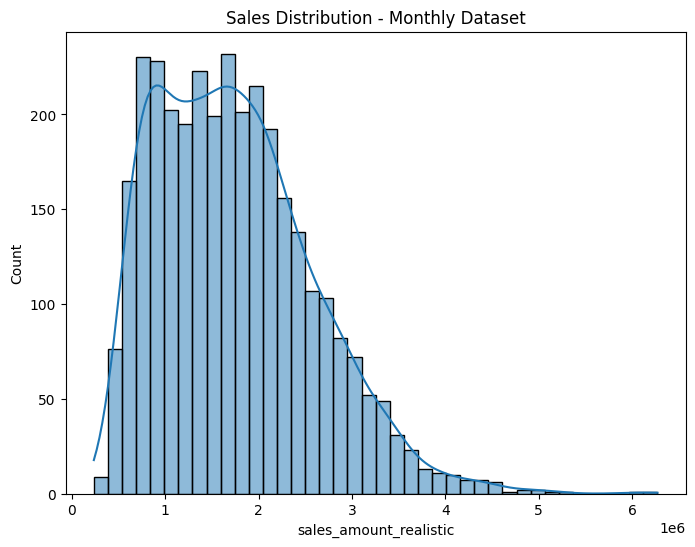

In [544]:
plt.figure(figsize=(8,6))

sns.histplot(monthly_df["sales_amount_realistic"], bins=40, kde=True)

plt.title("Sales Distribution - Monthly Dataset")
plt.show()

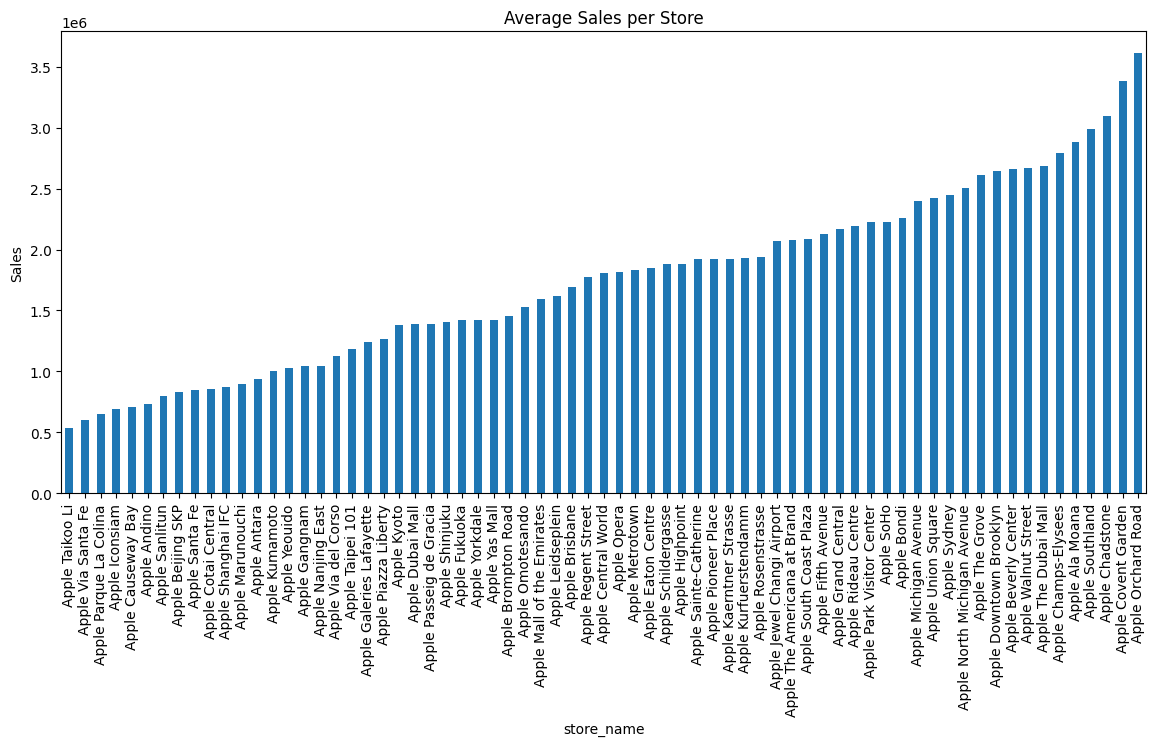

In [545]:
plt.figure(figsize=(14,6))

monthly_df.groupby("store_name")["sales_amount_realistic"].mean().sort_values().plot(kind="bar")

plt.title("Average Sales per Store")
plt.ylabel("Sales")
plt.show()

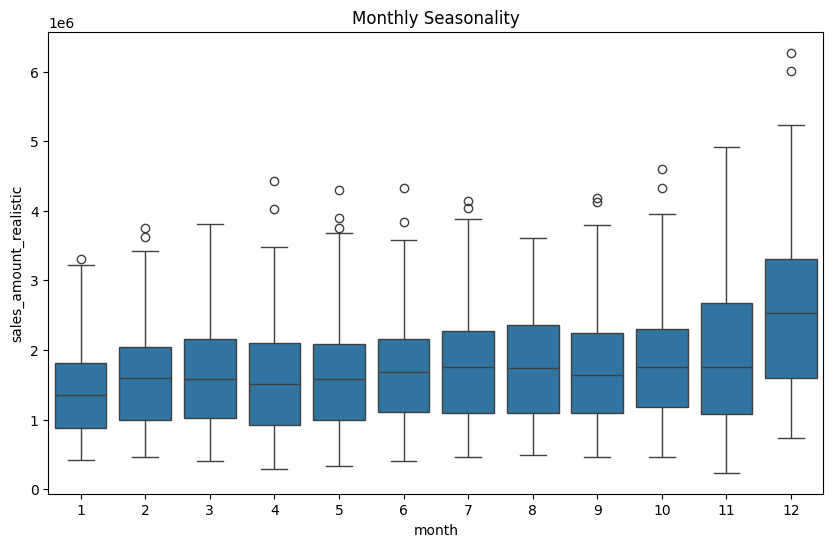

In [546]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="month",
    y="sales_amount_realistic",
    data=monthly_df
)

plt.title("Monthly Seasonality")
plt.show()

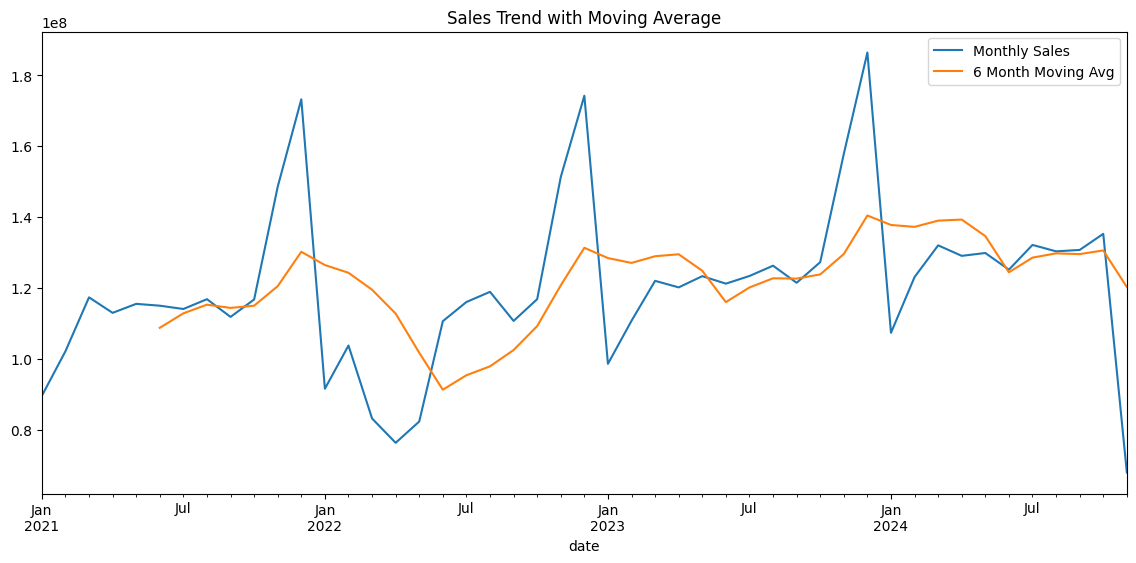

In [547]:
monthly_sales = monthly_df.groupby("date")["sales_amount_realistic"].sum()

plt.figure(figsize=(14,6))

monthly_sales.plot(label="Monthly Sales")

monthly_sales.rolling(6).mean().plot(label="6 Month Moving Avg")

plt.legend()

plt.title("Sales Trend with Moving Average")

plt.show()

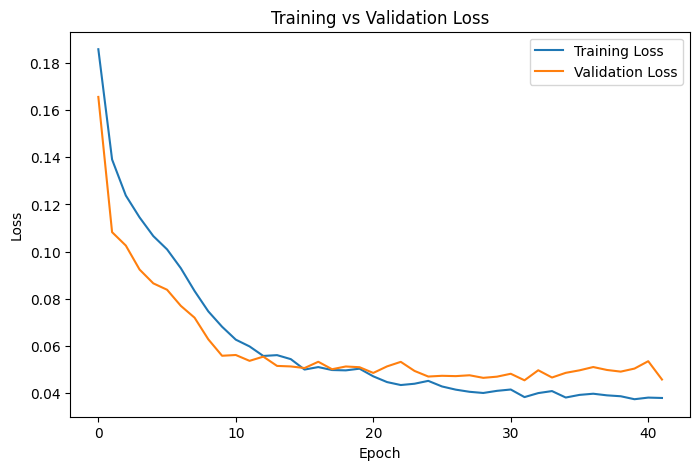

In [548]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

### TFT


In [575]:
monthly_df["time_idx"] = (
    monthly_df["year"] * 12 + monthly_df["month"]
)

In [576]:
monthly_df = monthly_df.sort_values(["store_id","date"])
monthly_df["time_idx"] = monthly_df.groupby("store_id").cumcount()

In [577]:
target = "sales_amount_realistic"

group_ids = ["store_id"]

time_varying_known = [
    "month_sin",
    "month_cos",
    "gdp_growth",
    "inflation_change",
    "exchange_change",
    "internet_growth"
]

time_varying_unknown = [
    "lag_1",
    "lag_3",
    "lag_6",
    "lag_12",
    "rolling_mean_3",
    "rolling_mean_6"
]

In [578]:
from pytorch_forecasting import TimeSeriesDataSet
from tqdm.autonotebook import tqdm
max_encoder_length = 12
max_prediction_length = 12

training = TimeSeriesDataSet(
    monthly_df,
    time_idx="time_idx",
    target="sales_amount_realistic",
    group_ids=["store_id"],

    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,

    time_varying_known_reals=time_varying_known,
    time_varying_unknown_reals=time_varying_unknown,

)

In [579]:
from pytorch_forecasting import TimeSeriesDataSet

validation = TimeSeriesDataSet.from_dataset(
    training,
    monthly_df,
    predict=True,
    stop_randomization=True
)

In [584]:
val_dataloader = validation.to_dataloader(
    train=False,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

In [585]:
from lightning.pytorch import Trainer

trainer = Trainer(
    max_epochs=30,
    accelerator="cpu"
)

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    192 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │      0 │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  8.2 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  3.7 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    676 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 25.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 25.7 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 411                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\Ali Sherif\Apple-Retail-Sales-Forcasting\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\Ali 
Sherif\Apple-Retail-Sales-Forcasting\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py
:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of 
the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

c:\Users\Ali 
Sherif\Apple-Retail-Sales-Forcasting\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py
:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of
the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

c:\Users\Ali Sherif\Apple-Retail-Sales-Forcasting\.venv\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:317: 
The number of training batches (25) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

`Trainer.fit` stopped: `max_epochs=30` reached.


In [589]:
from pytorch_forecasting.models import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.03,
    hidden_size=16,
    attention_head_size=4,
    dropout=0.1,
    loss=QuantileLoss(),
)

In [590]:
actuals = torch.cat([y[0] for x, y in iter(val_dataloader)])

In [591]:
predictions = tft.predict(train_dataloader)

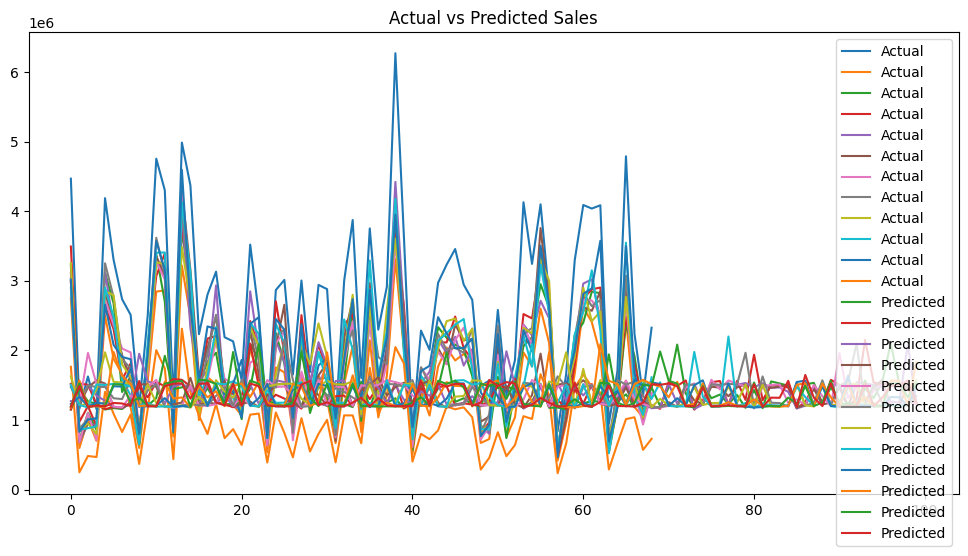

In [592]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(actuals[:100], label="Actual")
plt.plot(predictions[:100], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Sales")

plt.show()

In [594]:
predictions = tft.predict(val_dataloader)

actuals = torch.cat([y[0] for x, y in iter(val_dataloader)])

pred = predictions.numpy().flatten()
actual = actuals.numpy().flatten()

In [595]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))
mape = np.mean(np.abs((actual - pred) / actual)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 825791.375
RMSE: 1066084.1451517793
MAPE: 48.778133


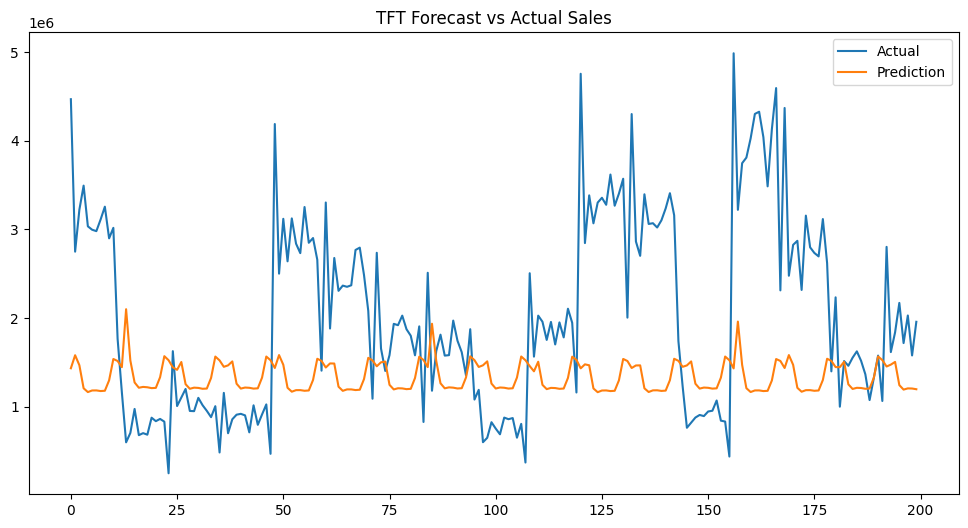

In [596]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(actual[:200], label="Actual")
plt.plot(pred[:200], label="Prediction")

plt.legend()
plt.title("TFT Forecast vs Actual Sales")

plt.show()

In [597]:
raw_predictions, x = tft.predict(val_dataloader, mode="raw", return_x=True)

tft.plot_prediction(x, raw_predictions, idx=0)

c:\Users\Ali Sherif\Apple-Retail-Sales-Forcasting\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Ali Sherif\Apple-Retail-Sales-Forcasting\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


ValueError: too many values to unpack (expected 2)